<div style="background: linear-gradient(135deg, #1e40af 0%, #3b82f6 50%, #06b6d4 100%); padding: 32px 24px; border-radius: 16px; color: white; text-align: center; margin-bottom: 20px;">
  <div style="font-size: 40px; margin-bottom: 8px;">🏥</div>
  <h1 style="color: white; margin: 0 0 8px 0; font-size: 28px;">MedSentinel AI</h1>
  <center><b><font size="4">Multimodal Missed-Diagnosis Prevention for Emergency Departments</font></b></center>
  <div style="display: inline-flex; gap: 12px; flex-wrap: wrap; justify-content: center;">
    <span style="background: rgba(255,255,255,0.2); padding: 4px 12px; border-radius: 20px; font-size: 13px;">🧠 MedGemma 1.5 4B</span>
    <span style="background: rgba(255,255,255,0.2); padding: 4px 12px; border-radius: 20px; font-size: 13px;">🔗 LangGraph Multi-Agent</span>
  </div>
</div>

### ⚡ TL;DR

**MedSentinel AI** is a multi-agent diagnostic safety system that catches missed diagnoses in emergency departments by synthesizing medical imaging, lab results, and clinical history — something **no existing clinical decision support system does**.

**The Problem:** 12 million diagnostic errors/year in the US. Current ED alert systems operate in silos — lab alerts only see labs, imaging AI only sees images. Nobody connects them.

**Our Solution:** 8 LangGraph agent nodes that replicate how a physician cross-checks data across modalities, using MedGemma 1.5 4B for unified medical reasoning.

**5 LangGraph Patterns Demonstrated:** Conditional routing · Parallel fan-out · Fan-in aggregation · Evaluator-optimizer loop · Human-in-the-loop ready

</div>

### 📑 Table of Contents

| Phase | Title | What It Does |
|-------|-------|-------------|
| **Phase 1** | Foundation & Model Loading | Load MedGemma 1.5 4B, verify multimodal capabilities |
| **Phase 2** | LangGraph Architecture | Define state schema, graph topology, 8 agent nodes |
| **Phase 3** | Agent Implementation | Build all agents + evaluator-optimizer loop |
| **Phase 4** | Interactive Dashboard | Gradio UI with pipeline flow visualization |
| **Phase 5** | Evaluation & Metrics | 10 scenarios, precision/recall/F1, error analysis |

---

### 🔴 The Problem: Cross-Modal Blind Spot in Emergency Medicine

<div style="display: grid; grid-template-columns: 1fr 1fr; gap: 16px; margin: 16px 0;">

<div style="background: #fef2f2; border: 1px solid #fecaca; border-radius: 10px; padding: 16px;">
  <h4 style="color: #dc2626; margin-top: 0;">❌ Current State (Siloed Alerts)</h4>
  <p style="font-size: 14px;">
    <b>Lab system:</b> "WBC 15.2 — HIGH" → Generic alert<br/>
    <b>Imaging AI:</b> "CXR — No acute findings" → Normal<br/>
    <b>EHR:</b> "Temp 38.7°C" → Vital sign flag<br/><br/>
    <em>Three separate alerts. Nobody connects them.<br/>
    Doctor is seeing 3 patients and gets 47 alerts/hour.</em>
  </p>
</div>

<div style="background: #f0fdf4; border: 1px solid #bbf7d0; border-radius: 10px; padding: 16px;">
  <h4 style="color: #16a34a; margin-top: 0;">✅ MedSentinel AI (Cross-Modal)</h4>
  <p style="font-size: 14px;">
    <b>One alert:</b> "⚠️ CRITICAL — Possible Occult Pneumonia"<br/><br/>
    <em>Reasoning: Elevated WBC + fever + tachycardia<br/>
    CONTRADICTS normal CXR in immunocompromised<br/>
    patient. Early/atypical pneumonia may not be<br/>
    visible on plain film. Recommend CT chest.</em>
  </p>
</div>

</div>

> **Key Insight:** The cross-modal synthesis that connects these findings currently exists **only in physicians' cognitive processes** — and it fails during cognitive overload, shift changes, and high-volume periods. MedSentinel AI automates this reasoning.

In [1]:
# ============================================================
# MedSentinel AI — Environment & Notebook Info
# ============================================================
print("=" * 65)
print("🏥 MedSentinel AI")
print("   Multimodal Missed-Diagnosis Prevention for Emergency Departments")
print("=" * 65)
print()
print("📋 Competition: MedGemma Impact Challenge")
print("🧠 Model:       MedGemma 1.5 4B (4-bit quantized)")
print("🔗 Framework:   LangGraph StateGraph (8 nodes)")
print("🖥️ Compute:     Kaggle T4 x2 GPU")
print()
print("📑 Notebook Structure:")
print("   Phase 1 — Foundation & Model Loading")
print("   Phase 2 — LangGraph Architecture")
print("   Phase 3 — Agent Implementation + Evaluator-Optimizer")
print("   Phase 4 — Interactive Gradio Dashboard")
print("   Phase 5 — Evaluation & Metrics (10 scenarios)")
print()
print("🔑 Key Innovation:")
print("   Cross-modal contradiction detection — synthesizes imaging,")
print("   labs, and clinical history to catch missed diagnoses that")
print("   single-modality alert systems cannot detect.")
print()
print("=" * 65)

🏥 MedSentinel AI
   Multimodal Missed-Diagnosis Prevention for Emergency Departments

📋 Competition: MedGemma Impact Challenge
🧠 Model:       MedGemma 1.5 4B (4-bit quantized)
🔗 Framework:   LangGraph StateGraph (8 nodes)
🖥️ Compute:     Kaggle T4 x2 GPU

📑 Notebook Structure:
   Phase 1 — Foundation & Model Loading
   Phase 2 — LangGraph Architecture
   Phase 3 — Agent Implementation + Evaluator-Optimizer
   Phase 4 — Interactive Gradio Dashboard
   Phase 5 — Evaluation & Metrics (10 scenarios)

🔑 Key Innovation:
   Cross-modal contradiction detection — synthesizes imaging,
   labs, and clinical history to catch missed diagnoses that
   single-modality alert systems cannot detect.



> ⚠️ **Note on Performance & Speed**
>
> This notebook runs on **Kaggle T4 x2 GPU** with **MedGemma 1.5 4B** using
> **4-bit quantization** to fit within hardware constraints. As a result,
> inference is slow (~15–20s per agent call) and reasoning quality is limited
> by the smaller model size and reduced precision.
>
> **In a production deployment**, MedSentinel AI would run on:
> - **Larger model** — MedGemma 27B or a fine-tuned clinical variant for
>   significantly stronger cross-modal reasoning
> - **Better hardware** — A100/H100 GPUs with full FP16/BF16 precision,
>   eliminating the quality loss from 4-bit quantization
> - **Faster inference** — vLLM or TensorRT-LLM for 5–10x throughput,
>   bringing end-to-end pipeline latency under 10 seconds
>
> The current setup demonstrates the **architecture, workflow patterns, and
> clinical methodology** — the core innovation is in the multi-agent design,
> not the hardware configuration.

# 🏥 MedSentinel AI — Phase 1: Environment Setup & Model Loading

> **Competition:** MedGemma Impact Challenge 
> **GPU:** Kaggle T4 x2 | **Model:** MedGemma 1.5 4B (instruction-tuned, full precision)

---

In this Phase 1 notebook, we will:

1. **Set up the environment** — install dependencies and authenticate with Hugging Face
2. **Load MedGemma 1.5 4B** — with 4-bit quantization to fit on Kaggle's T4 GPU
3. **Build a reusable inference helper** — a single function to query MedGemma across modalities
4. **Verify all 4 modalities** that MedSentinel AI will use:
   - 🩻 **CXR Image Interpretation** — analyze a chest X-ray
   - 🧪 **Lab Report Extraction** — extract structured values from lab text
   - 📋 **FHIR/EHR Understanding** — summarize a patient's clinical history
   - 🧠 **Medical Text Reasoning** — answer clinical reasoning questions
5. **Prepare sample data** — synthetic FHIR records, sample CXR, sample lab report

By the end, you'll have a fully loaded model with confirmed multi-modal capabilities,
ready for Phase 2 (building the individual agent modules).

In [2]:
# ============================================================
# Cell 1: Install Dependencies
# ============================================================
# MedGemma 1.5 requires transformers >= 4.50.0 (Gemma 3 support)
# bitsandbytes enables 4-bit quantization for T4 GPU compatibility
# accelerate handles multi-GPU device mapping

import PIL
import logging
import warnings
current_pillow = PIL.__version__
print(f"Current Pillow version: {current_pillow}")

# Mute standard python warnings
warnings.filterwarnings("ignore")

# Mute Hugging Face specific logging
from transformers import logging as hf_logging
hf_logging.set_verbosity_error()

!pip install --quiet --upgrade \
    transformers>=4.50.0 \
    accelerate \
    bitsandbytes \
    "pillow=={current_pillow}" \
    huggingface_hub

print("✅ Dependencies installed successfully")

Current Pillow version: 11.3.0
✅ Dependencies installed successfully


In [3]:
# ============================================================
# Cell 2: Authenticate with Hugging Face
# ============================================================
# Pull HF_TOKEN from Kaggle Secrets (never hardcode tokens!)

from kaggle_secrets import UserSecretsClient
from huggingface_hub import login

user_secrets = UserSecretsClient()
HF_TOKEN = user_secrets.get_secret("HF_TOKEN")

login(token=HF_TOKEN)
print("✅ Authenticated with Hugging Face")

✅ Authenticated with Hugging Face


In [4]:
# ============================================================
# Cell 3: Load MedGemma 1.5 4B — Full Precision Pipeline
# ============================================================
import torch
from transformers import pipeline

MODEL_ID = "google/medgemma-1.5-4b-it"

# Load as image-text-to-text pipeline at full precision
# device_map="auto" distributes layers across both T4 GPUs
pipe = pipeline(
    "image-text-to-text",
    model=MODEL_ID,
    dtype=torch.bfloat16,
    device="cuda",
)

print(f"✅ MedGemma 1.5 4B loaded at full precision (bfloat16)")
print(f"   Model: {MODEL_ID}")
print(f"   Precision: bfloat16 (no quantization)")
print(f"   Pipeline type: image-text-to-text")

Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]

✅ MedGemma 1.5 4B loaded at full precision (bfloat16)
   Model: google/medgemma-1.5-4b-it
   Precision: bfloat16 (no quantization)
   Pipeline type: image-text-to-text


In [ ]:
# ============================================================
# Cell 3b: (OPTIONAL) Load MedGemma 27B — 4-bit Quantization
# ============================================================
# Uncomment the code below to load MedGemma 27B alongside the 4B model.
# This uses 4-bit quantization to fit within T4 x2 GPU memory.

# import torch
# from transformers import (
#     AutoTokenizer,
#     AutoModelForCausalLM,
#     BitsAndBytesConfig,
# )
#
# MODEL_27B_ID = "google/medgemma-27b-it"
#
# quantization_config_27b = BitsAndBytesConfig(
#     load_in_4bit=True,
#     bnb_4bit_compute_dtype=torch.bfloat16,
#     bnb_4bit_quant_type="nf4",
# )
#
# tokenizer_27b = AutoTokenizer.from_pretrained(MODEL_27B_ID)
#
# model_27b = AutoModelForCausalLM.from_pretrained(
#     MODEL_27B_ID,
#     quantization_config=quantization_config_27b,
#     device_map="auto",
# )
#
#
# def query_medgemma_27b(
#     user_prompt: str,
#     system_prompt: str = "You are an expert medical AI assistant.",
#     max_new_tokens: int = 2000,
# ) -> str:
#     """
#     Query MedGemma 27B for text-only medical reasoning.
#     Use this for evaluator/optimizer or complex reasoning tasks.
#     """
#     messages = [
#         {"role": "system", "content": system_prompt},
#         {"role": "user", "content": user_prompt},
#     ]
#     input_ids = tokenizer_27b.apply_chat_template(
#         messages, return_tensors="pt", add_generation_prompt=True,
#     ).to(model_27b.device)
#
#     with torch.no_grad():
#         outputs = model_27b.generate(
#             input_ids,
#             max_new_tokens=max_new_tokens,
#             do_sample=True,
#             temperature=0.2,
#             top_p=0.9,
#         )
#
#     generated = outputs[0][input_ids.shape[1]:]
#     return tokenizer_27b.decode(generated, skip_special_tokens=True)
#
#
# print(f"✅ MedGemma 27B loaded with 4-bit quantization")
# print(f"   Model: {MODEL_27B_ID}")
# print(f"   Precision: 4-bit NF4")

print("⏭️ Cell 3b skipped — using MedGemma 1.5 4B pipeline only")
print("   Uncomment to enable MedGemma 27B reasoning tasks")

In [5]:
# ============================================================
# Cell 4: Reusable Inference Helper
# ============================================================
from PIL import Image
from IPython.display import display, Markdown


def query_medgemma(
    user_prompt: str,
    image: Image.Image = None,
    system_prompt: str = "You are an expert medical AI assistant.",
    max_new_tokens: int = 2000,
) -> str:
    """
    Send a query to MedGemma 1.5 4B and return the generated text.
    
    This is the core inference function for MedSentinel AI.
    All agent modules (Phase 2) and the Supervisor (Phase 3)
    call this function — differentiated only by prompts.
    
    Args:
        user_prompt: The question or instruction for MedGemma.
        image: Optional PIL Image for multimodal queries (CXR, derm, etc).
        system_prompt: Sets MedGemma's persona and behavior.
        max_new_tokens: Maximum length of generated response.
    
    Returns:
        Generated text response from MedGemma 1.5 4B.
    """
    # Build the message structure
    messages = [
        {
            "role": "system",
            "content": [{"type": "text", "text": system_prompt}],
        },
    ]
    
    # Build user message content (text only, or image + text)
    user_content = []
    if image is not None:
        user_content.append({"type": "image", "image": image})
    user_content.append({"type": "text", "text": user_prompt})
    
    messages.append({"role": "user", "content": user_content})
    
    # Use the pipeline for inference
    output = pipe(
        messages,
        max_new_tokens=max_new_tokens,
        do_sample=True,
        temperature=0.2,
        top_p=0.9,
    )
    
    # Extract the generated text from pipeline output
    # Pipeline returns a list of dicts with 'generated_text' key
    generated = output[0]["generated_text"]
    
    # The pipeline returns the full conversation including input messages.
    # We need to extract only the assistant's response (last message).
    if isinstance(generated, list):
        # Chat pipeline returns list of message dicts
        for msg in reversed(generated):
            if msg.get("role") == "assistant":
                content = msg.get("content", "")
                if isinstance(content, str):
                    return content
                elif isinstance(content, list):
                    # Content may be a list of dicts with "text" keys
                    return " ".join(
                        c.get("text", str(c)) for c in content
                        if isinstance(c, dict)
                    )
        # Fallback: return last message content as string
        return str(generated[-1])
    elif isinstance(generated, str):
        return generated
    else:
        return str(generated)


def show_response(response: str):
    """Display MedGemma's response as formatted Markdown."""
    display(Markdown(response))


print("✅ Inference helper ready: query_medgemma()")
print("   Model: MedGemma 1.5 4B (full precision pipeline)")
print("   Supports: text-only AND image+text queries")
print("   Used by: All agents + Supervisor + Evaluator")

✅ Inference helper ready: query_medgemma()
   Model: MedGemma 1.5 4B (full precision pipeline)
   Supports: text-only AND image+text queries
   Used by: All agents + Supervisor + Evaluator


📷 Sample Chest X-Ray (PA view):


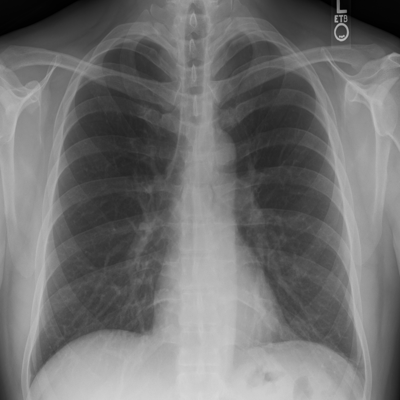


🩻 MedGemma CXR Analysis:


FINDINGS:

*   **Lungs:** The lungs are clear bilaterally with no focal consolidation, pleural effusion, or pneumothorax. The heart size is normal. The mediastinal contours are unremarkable. The visualized osseous structures are intact. The soft tissues are unremarkable.

IMPRESSION:

*   Normal chest X-ray.

In [6]:
# ============================================================
# Cell 5: Test Modality 1 — CXR Image Interpretation
# ============================================================
import requests
from PIL import Image

# Load a public-domain chest X-ray
# Source: Wikimedia Commons, CC0 license
# This is the same CXR used in Google's official MedGemma examples
CXR_URL = "https://upload.wikimedia.org/wikipedia/commons/c/c8/Chest_Xray_PA_3-8-2010.png"

medical_image = Image.open(
    requests.get(CXR_URL, headers={"User-Agent": "MedSentinel-AI"}, stream=True).raw
)

# Display the image
print("📷 Sample Chest X-Ray (PA view):")
display(medical_image.resize((400, 400)))

# Query MedGemma as a radiologist
response = query_medgemma(
    user_prompt=(
        "Analyze this chest X-ray image systematically. "
        "Describe your findings for: lungs, heart, mediastinum, "
        "bones, and soft tissues. "
        "Note any abnormalities and their clinical significance."
    ),
    image=medical_image,
    system_prompt="You are an expert radiologist reviewing a chest X-ray.",
)

print("\n🩻 MedGemma CXR Analysis:")
show_response(response)

In [7]:
# ============================================================
# Cell 6: Test Modality 2 — Lab Report Extraction
# ============================================================

# Simulate a realistic ED lab report as text
# In production, this could also be a scanned lab report image
SAMPLE_LAB_REPORT = """
LABORATORY REPORT
Patient: John Doe | DOB: 1957-03-15 | MRN: 12345678
Collection Date: 2026-02-15 08:30 | Reported: 2026-02-15 10:15

COMPLETE BLOOD COUNT (CBC):
  WBC:          15.2    K/uL    (Ref: 4.5 - 11.0)    [HIGH]
  RBC:          4.1     M/uL    (Ref: 4.5 - 5.5)     [LOW]
  Hemoglobin:   11.8    g/dL    (Ref: 13.5 - 17.5)   [LOW]
  Hematocrit:   35.2    %       (Ref: 38.0 - 50.0)   [LOW]
  Platelets:    245     K/uL    (Ref: 150 - 400)      [NORMAL]

BASIC METABOLIC PANEL (BMP):
  Glucose:      142     mg/dL   (Ref: 70 - 100)       [HIGH]
  BUN:          28      mg/dL   (Ref: 7 - 20)         [HIGH]
  Creatinine:   1.8     mg/dL   (Ref: 0.7 - 1.3)     [HIGH]
  Sodium:       138     mEq/L   (Ref: 136 - 145)      [NORMAL]
  Potassium:    4.2     mEq/L   (Ref: 3.5 - 5.0)     [NORMAL]

INFLAMMATORY MARKERS:
  CRP:          45.0    mg/L    (Ref: 0.0 - 5.0)      [HIGH]
  ESR:          52      mm/hr   (Ref: 0 - 20)         [HIGH]
  Procalcitonin: 2.1    ng/mL   (Ref: 0.0 - 0.1)     [HIGH]
"""

response = query_medgemma(
    user_prompt=(
        "Extract all lab values from this report. For each value, provide:\n"
        "1. Test name\n"
        "2. Value with units\n"
        "3. Reference range\n"
        "4. Status: NORMAL, HIGH, or LOW\n"
        "5. Clinical significance\n\n"
        "Then provide an overall clinical interpretation of what these "
        "results suggest when considered together.\n\n"
        f"LAB REPORT:\n{SAMPLE_LAB_REPORT}"
    ),
    system_prompt=(
        "You are an expert clinical pathologist. "
        "Extract structured lab data and provide clinical interpretation. "
        "Be precise with values and flag any critical abnormalities."
    ),
)

print("🧪 MedGemma Lab Report Extraction:")
show_response(response)

🧪 MedGemma Lab Report Extraction:


Okay, here is the structured lab data and clinical interpretation based on the provided report.

**Structured Lab Data:**

| Test Name             | Value | Units | Reference Range | Status | Clinical Significance                                                                 |
| :-------------------- | :--- | :--- | :------------- | :---- | :---------------------------------------------------------------------------------- |
| **COMPLETE BLOOD COUNT (CBC)** |                       |             |             |                                                                                     |
| WBC                   | 15.2 | K/uL | 4.5 - 11.0      | HIGH   | Elevated white blood cell count, suggesting inflammation, infection, or stress.       |
| RBC                   | 4.1 | M/uL | 4.5 - 5.5       | LOW    | Low red blood cell count, potentially indicating anemia.                             |
| Hemoglobin            | 11.8 | g/dL | 13.5 - 17.5     | LOW    | Low hemoglobin, consistent with anemia.                                             |
| Hematocrit            | 35.2 | %    | 38.0 - 50.0     | LOW    | Low hematocrit, consistent with anemia.                                             |
| Platelets             | 245 | K/uL | 150 - 400        | NORMAL | Normal platelet count.                                                               |
| **BASIC METABOLIC PANEL (BMP)** |                       |             |             |                                                                                     |
| Glucose               | 142 | mg/dL | 70 - 100        | HIGH   | Elevated blood glucose, suggesting hyperglycemia.                                    |
| BUN                   | 28 | mg/dL | 7 - 20          | HIGH   | Elevated blood urea nitrogen, suggesting dehydration or kidney dysfunction.       |
| Creatinine            | 1.8 | mg/dL | 0.7 - 1.3       | HIGH   | Elevated creatinine, suggesting kidney dysfunction.                                |
| Sodium                | 138 | mEq/L | 136 - 145       | NORMAL | Normal sodium level.                                                                |
| Potassium             | 4.2 | mEq/L | 3.5 - 5.0       | NORMAL | Normal potassium level.                                                              |
| **INFLAMMATORY MARKERS** |                       |             |             |                                                                                     |
| CRP                   | 45.0 | mg/L | 0.0 - 5.0       | HIGH   | Elevated C-reactive protein, indicating inflammation.                               |
| ESR                   | 52 | mm/hr | 0 - 20          | HIGH   | Elevated erythrocyte sedimentation rate, indicating inflammation.                 |
| Procalcitonin         | 2.1 | ng/mL | 0.0 - 0.1      | HIGH   | Elevated procalcitonin, often associated with bacterial infection or severe inflammation. |

**Overall Clinical Interpretation:**

The patient presents with a constellation of abnormal laboratory results, primarily indicating significant systemic inflammation and potential organ dysfunction.

*   **Hematologic Abnormalities:** The CBC shows elevated WBC, low RBC, low Hemoglobin, and low Hematocrit, consistent with anemia. This could be due to various causes, including chronic inflammation, nutritional deficiencies, or underlying chronic disease.
*   **Metabolic Abnormalities:** The BMP reveals elevated Glucose, BUN, and Creatinine. The elevated glucose suggests hyperglycemia, potentially related to diabetes or stress response. The elevated BUN and Creatinine are concerning for impaired kidney function, possibly related to dehydration, pre-renal azotemia, or underlying chronic kidney disease.
*   **Inflammatory Markers:** The elevated CRP, ESR, and Procalcitonin strongly suggest a significant ongoing inflammatory process.

**In summary, the results point towards a systemic inflammatory condition, possibly infectious or related to an underlying chronic disease. The anemia and signs of kidney dysfunction are also notable findings that require further investigation to determine the underlying cause.**

In [8]:
# ============================================================
# Cell 7: Test Modality 3 — FHIR/EHR Understanding
# ============================================================
import json

# Simplified FHIR Bundle representing an ED patient
# In production, this would come from Synthea-generated data
# Structure follows FHIR R4 standard
SAMPLE_FHIR_BUNDLE = {
    "resourceType": "Bundle",
    "type": "transaction",
    "entry": [
        {
            "resource": {
                "resourceType": "Patient",
                "name": [{"given": ["John"], "family": "Doe"}],
                "gender": "male",
                "birthDate": "1957-03-15",
            }
        },
        {
            "resource": {
                "resourceType": "Condition",
                "code": {
                    "coding": [
                        {
                            "system": "http://snomed.info/sct",
                            "code": "38341003",
                            "display": "Hypertension",
                        }
                    ]
                },
                "clinicalStatus": {
                    "coding": [{"code": "active"}]
                },
                "onsetDateTime": "2015-06-01",
            }
        },
        {
            "resource": {
                "resourceType": "Condition",
                "code": {
                    "coding": [
                        {
                            "system": "http://snomed.info/sct",
                            "code": "44054006",
                            "display": "Type 2 Diabetes Mellitus",
                        }
                    ]
                },
                "clinicalStatus": {
                    "coding": [{"code": "active"}]
                },
                "onsetDateTime": "2018-09-20",
            }
        },
        {
            "resource": {
                "resourceType": "MedicationRequest",
                "medicationCodeableConcept": {
                    "coding": [
                        {"display": "Metformin 500mg twice daily"}
                    ]
                },
                "status": "active",
            }
        },
        {
            "resource": {
                "resourceType": "MedicationRequest",
                "medicationCodeableConcept": {
                    "coding": [
                        {"display": "Lisinopril 10mg daily"}
                    ]
                },
                "status": "active",
            }
        },
        {
            "resource": {
                "resourceType": "Observation",
                "code": {
                    "coding": [{"display": "Body Temperature"}]
                },
                "valueQuantity": {"value": 38.7, "unit": "°C"},
                "effectiveDateTime": "2026-02-15T08:00:00Z",
            }
        },
        {
            "resource": {
                "resourceType": "Observation",
                "code": {
                    "coding": [{"display": "Heart Rate"}]
                },
                "valueQuantity": {"value": 102, "unit": "bpm"},
                "effectiveDateTime": "2026-02-15T08:00:00Z",
            }
        },
        {
            "resource": {
                "resourceType": "Observation",
                "code": {
                    "coding": [{"display": "Blood Pressure"}]
                },
                "valueQuantity": {"value": 145, "unit": "mmHg"},
                "component": [
                    {
                        "code": {"coding": [{"display": "Systolic"}]},
                        "valueQuantity": {"value": 145, "unit": "mmHg"},
                    },
                    {
                        "code": {"coding": [{"display": "Diastolic"}]},
                        "valueQuantity": {"value": 92, "unit": "mmHg"},
                    },
                ],
                "effectiveDateTime": "2026-02-15T08:00:00Z",
            }
        },
        {
            "resource": {
                "resourceType": "Observation",
                "code": {
                    "coding": [{"display": "Oxygen Saturation"}]
                },
                "valueQuantity": {"value": 94, "unit": "%"},
                "effectiveDateTime": "2026-02-15T08:00:00Z",
            }
        },
        {
            "resource": {
                "resourceType": "AllergyIntolerance",
                "code": {
                    "coding": [{"display": "Penicillin"}]
                },
                "clinicalStatus": {
                    "coding": [{"code": "active"}]
                },
            }
        },
    ],
}

fhir_json_str = json.dumps(SAMPLE_FHIR_BUNDLE, indent=2)

response = query_medgemma(
    user_prompt=(
        "Analyze this patient's FHIR health record. Provide a concise "
        "clinical summary including:\n"
        "1. Demographics (age, sex)\n"
        "2. Active conditions\n"
        "3. Current medications\n"
        "4. Allergies\n"
        "5. Latest vital signs with any abnormalities noted\n"
        "6. Risk factors relevant to an emergency department visit\n"
        "7. Any medication-condition interactions to be aware of\n\n"
        f"FHIR BUNDLE:\n{fhir_json_str}"
    ),
    system_prompt=(
        "You are an experienced emergency medicine physician reviewing "
        "a patient's electronic health record in FHIR format. "
        "Extract clinically relevant information and highlight any "
        "concerns for the current visit."
    ),
)

print("📋 MedGemma FHIR/EHR Analysis:")
show_response(response)

📋 MedGemma FHIR/EHR Analysis:


Okay, here is a clinical summary based on the provided FHIR data, highlighting potential concerns for the current visit:

**Clinical Summary**

**Patient Demographics:**
*   **Age:** 63 years old
*   **Sex:** Male

**Active Conditions:**
*   Hypertension (diagnosed 2015)
*   Type 2 Diabetes Mellitus (diagnosed 2018)

**Current Medications:**
*   Metformin 500mg twice daily
*   Lisinopril 10mg daily

**Allergies:**
*   Penicillin (active)

**Latest Vital Signs (2026-02-15):**
*   **Body Temperature:** 38.7°C (Abnormal - Fever)
*   **Heart Rate:** 102 bpm (Abnormal - Tachycardia)
*   **Blood Pressure:** 145/92 mmHg (Abnormal - Elevated, particularly systolic)
*   **Oxygen Saturation:** 94% (Borderline low, especially in the context of fever and tachycardia)

**Risk Factors for Emergency Department Visit:**
*   **Fever:** Suggests an infectious process.
*   **Tachycardia:** Can be associated with fever, dehydration, infection, or underlying cardiac issues.
*   **Elevated Blood Pressure:** May be related to stress, infection, or underlying hypertension.
*   **Borderline Low Oxygen Saturation:** May indicate respiratory compromise or poor perfusion.
*   **Active Allergy:** Penicillin allergy is a significant concern if an infection requiring antibiotics is suspected.

**Medication-Condition Interactions to Consider:**
*   **Lisinopril (ACE inhibitor) and Diabetes:** ACE inhibitors can potentially worsen hyperkalemia, especially if the patient is dehydrated or has kidney issues. Monitor potassium levels.
*   **Metformin and potential infection/dehydration:** Metformin can increase the risk of lactic acidosis, particularly in the setting of dehydration, renal impairment, or severe infection. Monitor renal function and consider holding metformin if the patient is significantly ill or dehydrated.
*   **Lisinopril and Penicillin Allergy:** While not a direct interaction, the presence of a penicillin allergy warrants caution if an antibiotic is needed.

**Concerns for Current Visit:**
The patient presents with fever, tachycardia, elevated blood pressure, and borderline low oxygen saturation. These findings, along with the active penicillin allergy, raise concern for a potential infection (e.g., pneumonia, UTI, sepsis) or other acute illness requiring urgent evaluation and management. The potential for medication-related adverse effects (e.g., lactic acidosis with metformin, hyperkalemia with lisinopril) should also be considered, especially if the patient is significantly ill or dehydrated.

In [9]:
# ============================================================
# Cell 8: Test Modality 4 — Medical Text Reasoning
# ============================================================

response = query_medgemma(
    user_prompt=(
        "A 68-year-old male presents to the ED with cough and fever "
        "for 3 days. His vital signs show: Temp 38.7°C, HR 102, BP "
        "145/92, SpO2 94% on room air.\n\n"
        "Lab results show: WBC 15.2 (HIGH), CRP 45 (HIGH), "
        "Procalcitonin 2.1 (HIGH), Creatinine 1.8 (HIGH).\n\n"
        "However, the chest X-ray was reported as 'No acute "
        "cardiopulmonary abnormality.'\n\n"
        "As a senior attending physician, identify any inconsistencies "
        "between the clinical presentation, lab results, and imaging. "
        "What might be missed? What would you recommend?"
    ),
    system_prompt=(
        "You are a senior emergency medicine attending physician "
        "performing a safety review. Your job is to catch potential "
        "missed diagnoses by identifying inconsistencies across "
        "different sources of clinical information."
    ),
)

print("🧠 MedGemma Clinical Reasoning:")
show_response(response)

🧠 MedGemma Clinical Reasoning:


Here's a breakdown of the inconsistencies and potential missed diagnoses, along with recommendations:

**Inconsistencies Identified:**

1.  **Clinical Presentation vs. Imaging:**
    *   **Clinical:** The patient presents with cough and fever (classic symptoms of lower respiratory tract infection, particularly pneumonia).
    *   **Imaging:** The chest X-ray is reported as 'No acute cardiopulmonary abnormality.' This directly contradicts the clinical presentation suggesting a respiratory infection.

2.  **Clinical Presentation vs. Lab Results:**
    *   **Clinical:** Cough and fever suggest an infectious process.
    *   **Labs:** Elevated WBC, CRP, and Procalcitonin strongly support an infectious/inflammatory process, likely bacterial given the high procalcitonin.
    *   **Creatinine:** Elevated creatinine (1.8) suggests potential kidney injury, which can be associated with severe systemic infections (sepsis) or dehydration.

3.  **Lab Results vs. Imaging:**
    *   **Labs:** High inflammatory markers (WBC, CRP, Procalcitonin) point towards a significant inflammatory or infectious process.
    *   **Imaging:** The 'normal' chest X-ray is inconsistent with the degree of inflammation indicated by the lab results.

**Potential Missed Diagnoses:**

1.  **Pneumonia (despite normal CXR):** This is the most likely missed diagnosis.
    *   **Why it's missed:** Chest X-rays can be normal in early or atypical pneumonia, especially in certain populations (e.g., elderly, immunocompromised, those with underlying lung disease). The inflammation might be localized or subtle.
    *   **Considerations:**
        *   **Atypical Pneumonia:** *Mycoplasma pneumoniae*, *Chlamydophila pneumoniae*, *Legionella pneumophila* can present with non-specific symptoms and sometimes normal or subtle CXR findings initially.
        *   **Viral Pneumonia:** While often associated with more diffuse findings, some viral pneumonias (e.g., influenza, COVID-19) can have subtle or even normal initial CXR.
        *   **Early Bacterial Pneumonia:** The infection might be too recent to show clear consolidation on X-ray.
        *   **Interstitial Lung Disease (ILD) or other chronic lung conditions:** The patient might have underlying lung disease that makes interpretation of CXR difficult, or the current process might be superimposed on chronic changes.
        *   **Non-infectious causes:** Although less likely given the high inflammatory markers, consider other causes of inflammation/infection that might not show on CXR (e.g., pulmonary embolism, vasculitis, certain malignancies).

2.  **Sepsis:** The high inflammatory markers (WBC, CRP, Procalcitonin) and elevated creatinine raise concern for sepsis, even without clear radiographic evidence of pneumonia.
    *   **Why it's missed:** Sepsis can originate from various sources, including pneumonia, urinary tract infections, skin infections, etc. The source might not be evident on initial CXR. The patient might be developing sepsis secondary to an undiagnosed pneumonia.

3.  **Other Infections:** While pneumonia is most likely, consider other sources of infection that could explain the symptoms and lab findings:
    *   **Urinary Tract Infection (UTI):** Especially in the elderly, UTIs can present atypically with fever, cough, and elevated inflammatory markers.
    *   **Skin/Soft Tissue Infection:** A severe infection elsewhere could lead to systemic inflammation.
    *   **Other sources:** Endocarditis, intra-abdominal infection, etc.

**Recommendations:**

1.  **Re-evaluate the Chest X-ray:**
    *   **Request a lateral decubitus chest X-ray:** This can sometimes reveal small effusions or infiltrates missed on a standard PA/lateral view.
    *   **Request a CT Chest:** Given the high inflammatory markers and discrepancy with CXR, a CT scan is warranted to look for subtle infiltrates, consolidation, ground-glass opacities, or other abnormalities that might not be visible on X-ray. This is particularly important if considering atypical or viral causes.

2.  **Further Diagnostic Workup:**
    *   **Sputum Culture and Gram Stain:** Even if the patient isn't producing sputum, consider obtaining a sample if possible.
    *   **Blood Cultures:** Essential in any patient with suspected sepsis or severe infection.
    *   **Consider specific tests based on clinical suspicion:**
        *   *Legionella* urinary antigen test.
        *   *Mycoplasma* PCR or serology (less useful acutely).
        *   *Chlamydophila* PCR or serology.
        *   Consider testing for COVID-19 if appropriate based on local epidemiology and clinical suspicion.
        *   Consider urinalysis and urine culture if UTI is suspected.

3.  **Clinical Assessment:**
    *   **Assess for Sepsis:** Use SIRS criteria or qSOFA/SOFA scores. Monitor vital signs closely. Consider lactate levels.
    *   **Assess for Severity:** Determine if the patient meets criteria for ICU admission based on severity of illness (e.g., CURB-65 score, PSI score).

4.  **Treatment:**
    *   **Initiate empiric antibiotics:** Given the high inflammatory markers and clinical presentation, start broad-spectrum antibiotics covering likely community-acquired pneumonia pathogens (e.g., ceftriaxone + azithromycin or a respiratory fluoroquinolone). Adjust based on culture results and clinical response.
    *   **Consider supportive care:** Ensure adequate hydration, oxygenation, and monitoring.

**Conclusion:**

The discrepancy between the patient's symptoms (cough, fever), high inflammatory markers (WBC, CRP, Procalcitonin), and a normal chest X-ray is a significant red flag. The most likely missed diagnosis is pneumonia, potentially an atypical or early bacterial form, or even a viral etiology. Sepsis is also a concern given the lab findings. Further imaging (lateral decubitus or CT) and diagnostic testing are crucial to confirm or exclude pneumonia and identify the source of infection. Empiric antibiotics should be started promptly while further investigations are pursued.

In [10]:
# ============================================================
# Cell 9: Check GPU Memory Usage
# ============================================================
import subprocess

def show_gpu_memory():
    """Display current GPU memory usage."""
    result = subprocess.run(
        ["nvidia-smi", "--query-gpu=name,memory.used,memory.total,memory.free",
         "--format=csv,noheader,nounits"],
        capture_output=True, text=True
    )
    print("🖥️ GPU Memory Status:")
    print("-" * 60)
    for i, line in enumerate(result.stdout.strip().split("\n")):
        name, used, total, free = [x.strip() for x in line.split(",")]
        usage_pct = float(used) / float(total) * 100
        print(f"  GPU {i}: {name}")
        print(f"    Used: {used} MB / {total} MB ({usage_pct:.1f}%)")
        print(f"    Free: {free} MB")
    print("-" * 60)

show_gpu_memory()

🖥️ GPU Memory Status:
------------------------------------------------------------
  GPU 0: Tesla T4
    Used: 10919 MB / 15360 MB (71.1%)
    Free: 3994 MB
  GPU 1: Tesla T4
    Used: 3 MB / 15360 MB (0.0%)
    Free: 14910 MB
------------------------------------------------------------


In [11]:
# ============================================================
# Cell 10: Save Configuration
# ============================================================

# MedSentinel AI Configuration
MEDSENTINEL_CONFIG = {
    "project_name": "MedSentinel AI",
    "model_id": MODEL_ID,
    "competition": "MedGemma Impact Challenge",
    "deadline": "2026-02-24",
    
    # Agent system prompts (will be refined in Phase 2)
    "imaging_agent_prompt": (
        "You are an expert radiologist. Analyze medical images "
        "systematically and report findings in structured format."
    ),
    "lab_agent_prompt": (
        "You are an expert clinical pathologist. Extract structured "
        "lab data and provide clinical interpretation."
    ),
    "history_agent_prompt": (
        "You are an experienced emergency medicine physician. "
        "Extract clinically relevant information from patient records."
    ),
    "orchestrator_prompt": (
        "You are a senior emergency medicine attending performing "
        "a safety review. Identify inconsistencies across imaging, "
        "labs, and clinical history that could indicate missed diagnoses."
    ),
}

# Print summary
print("=" * 60)
print("🏥 MedSentinel AI — Phase 1 Complete!")
print("=" * 60)
print()
print("✅ Model loaded: MedGemma 1.5 4B (full precision pipeline)")
print("✅ Modality 1: CXR Image Interpretation — VERIFIED")
print("✅ Modality 2: Lab Report Extraction — VERIFIED")
print("✅ Modality 3: FHIR/EHR Understanding — VERIFIED")
print("✅ Modality 4: Medical Text Reasoning — VERIFIED")
print()
print("📌 Next: Phase 2 — Build Individual Agent Modules")
print("   - ImagingAgent (Imaging analysis)")
print("   - LabReportAgent (structured value extraction)")
print("   - ClinicalHistoryAgent (FHIR record navigation)")
print("=" * 60)

🏥 MedSentinel AI — Phase 1 Complete!

✅ Model loaded: MedGemma 1.5 4B (full precision pipeline)
✅ Modality 1: CXR Image Interpretation — VERIFIED
✅ Modality 2: Lab Report Extraction — VERIFIED
✅ Modality 3: FHIR/EHR Understanding — VERIFIED
✅ Modality 4: Medical Text Reasoning — VERIFIED

📌 Next: Phase 2 — Build Individual Agent Modules
   - ImagingAgent (Imaging analysis)
   - LabReportAgent (structured value extraction)
   - ClinicalHistoryAgent (FHIR record navigation)


# 🏥 MedSentinel AI — Phase 2: LangGraph Agent Nodes

> **Competition:** MedGemma Impact Challenge
> **Framework:** LangGraph (graph-based multi-agent orchestration)  
> **GPU:** Kaggle T4 x2 | **Model:** MedGemma 1.5 4B (loaded in Phase 1)

---

In this Phase 2 notebook, we will:

1. **Install LangGraph** — add the orchestration framework alongside our existing stack
2. **Define the shared agent state** — `MedSentinelState`, the central nervous system of the workflow
3. **Build a JSON parser utility** — robust extraction of structured data from MedGemma's outputs
4. **Implement 4 agent nodes**, each deploying MedGemma as a specialized callable tool:
   - 🚦 **Triage Router** — dynamically decides which agents to activate
   - 🩻 **Imaging Agent** — imaging interpretation
   - 🧪 **Lab Report Agent** — structured lab value extraction
   - 📋 **Clinical History Agent** — FHIR/EHR navigation and summarization
5. **Test each agent node independently** — validate structured JSON outputs

By the end, we'll have 4 production-quality LangGraph node functions, each independently
tested and ready to be wired into the full StateGraph in Phase 3.

In [12]:
# ============================================================
# Cell 11: Install LangGraph & LangChain Core
# ============================================================
# LangGraph: graph-based multi-agent orchestration framework
# langchain-core: base types and utilities used by LangGraph
#
# We do NOT need langchain-huggingface or langchain-openai.
# MedGemma is a local HuggingFace pipeline, not a chat API.
# LangGraph handles orchestration; MedGemma handles intelligence.

!pip install --quiet langgraph langchain-core

# Verify installation
import langgraph
print(f"✅ LangGraph installed")
print("   LangGraph handles: state management, node routing, execution tracing")
print("   MedGemma handles: medical reasoning, image analysis, document extraction")

✅ LangGraph installed
   LangGraph handles: state management, node routing, execution tracing
   MedGemma handles: medical reasoning, image analysis, document extraction


In [13]:
# ============================================================
# Cell 12: Define MedSentinelState
# ============================================================
from typing import TypedDict, Optional, Annotated
from PIL import Image
import operator

class MedSentinelState(TypedDict):
    """
    Shared state for the MedSentinel AI agentic workflow.
    
    This TypedDict flows through every node in the LangGraph.
    Each node reads the fields it needs and returns updates
    to the fields it's responsible for.
    
    Think of this as the patient's chart — each specialist
    reads from it and writes back their findings.
    """
    
    # ─── Inputs (provided at invocation) ────────────────────
    medical_image: Optional[Image.Image]  # Medical Imaging
    lab_report_text: str                  # Lab report as text
    fhir_bundle: dict                     # Patient FHIR record
    
    # ─── Triage Router Decision ─────────────────────────────
    active_agents: list                # Which agents to invoke
    
    # ─── Agent Outputs (one per agent) ──────────────────────
    imaging_findings: dict             # From Imaging Agent
    lab_findings: dict                 # From Lab Report Agent
    clinical_history: dict             # From Clinical History Agent
    
    # ─── Supervisor Outputs (Phase 3) ───────────────────────
    contradictions: list               # Cross-modal issues
    safety_alerts: list                # Final alerts with evidence
    alert_count: int                   # Number of alerts
    formatted_summary: str              # Human-readable summary from alert formatter
    
    # ─── Evaluator-Optimizer State (Phase 3) ───────────────
    evaluation_result: dict            # Evaluator output (accepted, feedback, score, missed_patterns)
    eval_count: int                    # Current evaluation iteration
    
    # ─── Execution Trace (append-only log) ──────────────────
    # operator.add means each node APPENDS to this list
    # rather than replacing it — giving us a full audit trail
    agent_trace: Annotated[list, operator.add]


print("✅ MedSentinelState defined")
print("   Fields: medical_image, lab_report_text, fhir_bundle,")
print("           active_agents, imaging_findings, lab_findings,")
print("           clinical_history, contradictions, safety_alerts,")
print("           alert_count, formatted_summary, evaluation_result,")
print("           eval_count, agent_trace")

✅ MedSentinelState defined
   Fields: medical_image, lab_report_text, fhir_bundle,
           active_agents, imaging_findings, lab_findings,
           clinical_history, contradictions, safety_alerts,
           alert_count, formatted_summary, evaluation_result,
           eval_count, agent_trace


In [14]:
# ============================================================
# Cell 13: JSON Response Parser
# ============================================================
import json
import re

def parse_json_response(response: str) -> dict | list:
    """
    Extract structured JSON from MedGemma's text response.
    
    Tries multiple strategies in order:
    1. Direct JSON parse (response is pure JSON)
    2. Extract from markdown code blocks (```json ... ```)
    3. Find JSON object {...} in mixed text
    4. Find JSON array [...] in mixed text
    5. Repair common JSON issues (unescaped newlines, trailing commas)
    6. Fallback: wrap raw text in a dict with parse_error flag
    
    Args:
        response: Raw text response from MedGemma.
    
    Returns:
        Parsed dict or list, or a fallback dict with the raw text.
    """
    if not response or not response.strip():
        return {"raw_response": "", "parse_error": True}
    
    # Strategy 1: Direct parse
    try:
        return json.loads(response.strip())
    except json.JSONDecodeError:
        pass
    
    # Strategy 2: Extract from markdown code blocks
    json_match = re.search(r'```(?:json)?\s*([\s\S]*?)\s*```', response)
    if json_match:
        try:
            return json.loads(json_match.group(1))
        except json.JSONDecodeError:
            # Try repair on code block content
            repaired = _repair_json(json_match.group(1))
            if repaired is not None:
                return repaired
    
    # Strategy 3 & 4: Find JSON object or array in text
    for pattern in [r'(\{[\s\S]*\})', r'(\[[\s\S]*\])']:
        match = re.search(pattern, response)
        if match:
            try:
                return json.loads(match.group(1))
            except json.JSONDecodeError:
                repaired = _repair_json(match.group(1))
                if repaired is not None:
                    return repaired
    
    # Fallback: return raw text wrapped in a dict
    return {"raw_response": response, "parse_error": True}


def _repair_json(text: str):
    """
    Attempt to repair common JSON issues from LLM output.
    
    Common problems MedGemma produces:
    - Unescaped newlines inside string values (breaks JSON)
    - Trailing commas before } or ]
    - Truncated JSON (missing closing brackets)
    - Control characters in string values
    """
    if not text or not text.strip():
        return None
    
    s = text.strip()
    
    # Fix 1: Remove trailing commas before } or ]
    s = re.sub(r',\s*([}\]])', r'\1', s)
    
    # Fix 2: Try parse after trailing comma fix
    try:
        return json.loads(s)
    except json.JSONDecodeError:
        pass
    
    # Fix 3: Replace unescaped newlines inside string values
    # This is the most common issue — MedGemma writes multi-line
    # text inside JSON string fields without escaping \n
    s_fixed = re.sub(r'(?<=": ")(.*?)(?="[,\s*}])', 
                     lambda m: m.group(0).replace('\n', '\\n').replace('\r', ''),
                     s, flags=re.DOTALL)
    try:
        return json.loads(s_fixed)
    except json.JSONDecodeError:
        pass
    
    # Fix 4: More aggressive — replace ALL literal newlines in string values
    # Walk through and escape newlines between quotes
    try:
        in_string = False
        escaped = []
        i = 0
        while i < len(s):
            ch = s[i]
            if ch == '"' and (i == 0 or s[i-1] != '\\'):
                in_string = not in_string
                escaped.append(ch)
            elif ch == '\n' and in_string:
                escaped.append('\\n')
            elif ch == '\r' and in_string:
                pass  # skip carriage returns
            elif ch == '\t' and in_string:
                escaped.append('\\t')
            else:
                escaped.append(ch)
            i += 1
        result_str = ''.join(escaped)
        # Remove trailing commas again after escaping
        result_str = re.sub(r',\s*([}\]])', r'\1', result_str)
        return json.loads(result_str)
    except (json.JSONDecodeError, IndexError):
        pass
    
    # Fix 5: Truncated JSON — try adding missing closing brackets
    open_braces = s.count('{') - s.count('}')
    open_brackets = s.count('[') - s.count(']')
    if open_braces > 0 or open_brackets > 0:
        s_closed = s + ']' * open_brackets + '}' * open_braces
        s_closed = re.sub(r',\s*([}\]])', r'\1', s_closed)
        try:
            return json.loads(s_closed)
        except json.JSONDecodeError:
            pass
    
    return None


# --- Quick test ---
test_cases = [
    ('Pure JSON', '{"test": "WBC", "value": 15.2}'),
    ('Code block', 'Here are the results:\n```json\n{"test": "WBC"}\n```'),
    ('Mixed text', 'The findings are: {"test": "WBC", "value": 15.2} as shown.'),
    ('Trailing comma', '{"test": "WBC", "value": 15.2,}'),
    ('Newline in string', '{"thinking": "Step 1: check labs\nStep 2: check imaging", "alerts": []}'),
    ('Truncated', '{"thinking": "analysis", "alerts": [{"severity": "HIGH"'),
    ('Unparseable', 'No JSON here, just text.'),
]

print("✅ parse_json_response() ready — test results:")
for name, test in test_cases:
    result = parse_json_response(test)
    status = "⚠️ fallback" if isinstance(result, dict) and result.get("parse_error") else "✅ parsed"
    print(f"   {status} | {name}: {str(result)[:60]}")

✅ parse_json_response() ready — test results:
   ✅ parsed | Pure JSON: {'test': 'WBC', 'value': 15.2}
   ✅ parsed | Code block: {'test': 'WBC'}
   ✅ parsed | Mixed text: {'test': 'WBC', 'value': 15.2}
   ✅ parsed | Trailing comma: {'test': 'WBC', 'value': 15.2}
   ✅ parsed | Newline in string: {'thinking': 'Step 1: check labs\nStep 2: check imaging', 'a
   ⚠️ fallback | Truncated: {'raw_response': '{"thinking": "analysis", "alerts": [{"seve
   ⚠️ fallback | Unparseable: {'raw_response': 'No JSON here, just text.', 'parse_error': 


In [15]:
# ============================================================
# Cell 14: Triage Router Node
# ============================================================

def triage_router_node(state: MedSentinelState) -> dict:
    """
    Triage Router: Inspects available inputs and dynamically
    decides which specialist agents to activate.
    
    This mirrors real ED workflow where the triage nurse
    determines which specialists are needed based on the
    patient's presenting data.
    
    Agentic behavior:
    - Not a static pipeline — adapts to what data is provided
    - Skips agents when their input modality is missing
    - Logs its routing decision to agent_trace for explainability
    
    Args:
        state: Current MedSentinelState with input fields
    
    Returns:
        Dict with active_agents list and trace entry
    """
    active = []
    routing_reasons = []
    
    # Check each modality
    if state.get("medical_image") is not None:
        active.append("imaging_agent")
        routing_reasons.append("CXR image detected → Imaging Agent activated")
    else:
        routing_reasons.append("No CXR image → Imaging Agent skipped")
    
    if state.get("lab_report_text", "").strip():
        active.append("lab_agent")
        routing_reasons.append("Lab report text detected → Lab Agent activated")
    else:
        routing_reasons.append("No lab report → Lab Agent skipped")
    
    if state.get("fhir_bundle"):
        active.append("history_agent")
        routing_reasons.append("FHIR bundle detected → History Agent activated")
    else:
        routing_reasons.append("No FHIR data → History Agent skipped")
    
    # Build detailed trace entry
    trace_entry = (
        f"🚦 Triage Router: {len(active)}/3 agents activated\n"
        + "\n".join(f"   {r}" for r in routing_reasons)
    )
    
    return {
        "active_agents": active,
        "agent_trace": [trace_entry],
    }


print("✅ triage_router_node() defined")

✅ triage_router_node() defined


In [16]:
# ============================================================
# Cell 15: Test Triage Router — All 3 Data Sources Available
# ============================================================
print("=" * 60)
print("Test 1: All 3 data sources available")
print("=" * 60)

test_state_full = {
    "medical_image": medical_image,           # From Phase 1
    "lab_report_text": SAMPLE_LAB_REPORT,     # From Phase 1
    "fhir_bundle": SAMPLE_FHIR_BUNDLE,        # From Phase 1
    "active_agents": [],
    "imaging_findings": {},
    "lab_findings": {},
    "clinical_history": {},
    "contradictions": [],
    "safety_alerts": [],
    "alert_count": 0,
    "agent_trace": [],
}

result = triage_router_node(test_state_full)
print(f"Active agents: {result['active_agents']}")
print(result["agent_trace"][0])

print()
print("=" * 60)
print("Test 2: Only lab report available (no CXR, no FHIR)")
print("=" * 60)

test_state_partial = {
    "medical_image": None,
    "lab_report_text": SAMPLE_LAB_REPORT,
    "fhir_bundle": {},
    "active_agents": [],
    "imaging_findings": {},
    "lab_findings": {},
    "clinical_history": {},
    "contradictions": [],
    "safety_alerts": [],
    "alert_count": 0,
    "agent_trace": [],
}

result = triage_router_node(test_state_partial)
print(f"Active agents: {result['active_agents']}")
print(result["agent_trace"][0])

print()
print("=" * 60)
print("Test 3: No data available")
print("=" * 60)

test_state_empty = {
    "medical_image": None,
    "lab_report_text": "",
    "fhir_bundle": {},
    "active_agents": [],
    "imaging_findings": {},
    "lab_findings": {},
    "clinical_history": {},
    "contradictions": [],
    "safety_alerts": [],
    "alert_count": 0,
    "agent_trace": [],
}

result = triage_router_node(test_state_empty)
print(f"Active agents: {result['active_agents']}")
print(result["agent_trace"][0])

Test 1: All 3 data sources available
Active agents: ['imaging_agent', 'lab_agent', 'history_agent']
🚦 Triage Router: 3/3 agents activated
   CXR image detected → Imaging Agent activated
   Lab report text detected → Lab Agent activated
   FHIR bundle detected → History Agent activated

Test 2: Only lab report available (no CXR, no FHIR)
Active agents: ['lab_agent']
🚦 Triage Router: 1/3 agents activated
   No CXR image → Imaging Agent skipped
   Lab report text detected → Lab Agent activated
   No FHIR data → History Agent skipped

Test 3: No data available
Active agents: []
🚦 Triage Router: 0/3 agents activated
   No CXR image → Imaging Agent skipped
   No lab report → Lab Agent skipped
   No FHIR data → History Agent skipped


In [17]:
# ============================================================
# Cell 16: Imaging Agent Node
# ============================================================

def imaging_agent_node(state: MedSentinelState) -> dict:
    """
    Imaging Agent: Deploys MedGemma 1.5 as a medical image analysis tool.
    
    Supports all image modalities MedGemma was trained on:
    - Chest X-rays (CXR)
    - Dermatology images (clinical & dermatoscopic)
    - Ophthalmology images (fundus / retinal)
    - Histopathology slides (H&E stained)
    
    Reads:  state["medical_image"] — PIL Image (any supported medical image)
    Writes: state["imaging_findings"] — structured findings dict
    
    Output schema:
    {
        "image_type": "chest_xray|dermatology|ophthalmology|histopathology|unknown",
        "findings": [
            {"region": "<anatomical region or area>", "finding": "<description>",
             "severity": "normal|mild|moderate|severe", "confidence": 0.85}
        ],
        "impression": "Findings consistent with...",
        "abnormalities_detected": true/false
    }
    """
    image = state.get("medical_image")
    
    # Guard: skip if no image provided
    if image is None:
        return {
            "imaging_findings": {
                "image_type": "none",
                "findings": [],
                "impression": "No image provided",
                "abnormalities_detected": False
            },
            "agent_trace": ["🩻 Imaging Agent: SKIPPED (no image in state)"],
        }
    
    # Deploy MedGemma as medical image analysis tool
    response = query_medgemma(
        user_prompt=(
            "Analyze this medical image systematically.\n\n"
            "First, identify what type of medical image this is "
            "(chest X-ray, dermatology photo, fundus/retinal image, "
            "histopathology slide, or other).\n\n"
            "Then analyze it thoroughly based on the image type.\n\n"
            "Return your findings as a JSON object with this EXACT structure:\n"
            "{\n"
            '  "image_type": "<chest_xray|dermatology|ophthalmology|histopathology|unknown>",\n'
            '  "findings": [\n'
            '    {"region": "<anatomical region or area>", "finding": "<description>", '
            '"severity": "normal|mild|moderate|severe", "confidence": <0.0-1.0>}\n'
            "  ],\n"
            '  "impression": "<overall clinical impression>",\n'
            '  "abnormalities_detected": <true/false>\n'
            "}\n\n"
            "Analysis guidance by image type:\n"
            "- Chest X-ray: examine lungs (each lobe), heart silhouette, "
            "mediastinum, costophrenic angles, bones, soft tissues.\n"
            "- Dermatology: describe lesion morphology, color, border, "
            "distribution, size, and suggest differential diagnoses.\n"
            "- Fundus/Retinal: examine optic disc, macula, vessels, "
            "retinal background for hemorrhages, exudates, or neovascularization.\n"
            "- Histopathology: describe tissue architecture, cell morphology, "
            "staining patterns, and any signs of dysplasia or malignancy.\n\n"
            "Return ONLY the JSON object, no additional text."
        ),
        image=image,
        system_prompt=(
            "You are an expert medical imaging specialist with expertise across "
            "radiology, dermatology, ophthalmology, and pathology. "
            "Analyze the provided medical image and report findings in structured "
            "JSON format. First identify the image modality, then systematically "
            "examine each relevant region or feature. Report both normal and "
            "abnormal findings with confidence scores for each."
        ),
    )
    
    # Parse MedGemma's response into structured data
    findings = parse_json_response(response)
    
    # Build trace entry with summary
    num_findings = len(findings.get("findings", []))
    has_abnormal = findings.get("abnormalities_detected", False)
    img_type = findings.get("image_type", "unknown")
    trace_entry = (
        f"🩻 Imaging Agent: {img_type} | {num_findings} findings | "
        f"Abnormalities: {'YES' if has_abnormal else 'NO'}\n"
        f"   Impression: {findings.get('impression', 'N/A')[:100]}"
    )
    
    return {
        "imaging_findings": findings,
        "agent_trace": [trace_entry],
    }


print("✅ imaging_agent_node() defined")
print("   Input:  state['medical_image'] (PIL Image — any medical image)")
print("   Output: state['imaging_findings'] (structured JSON)")
print("   Supports: CXR, dermatology, fundus, histopathology")

✅ imaging_agent_node() defined
   Input:  state['medical_image'] (PIL Image — any medical image)
   Output: state['imaging_findings'] (structured JSON)
   Supports: CXR, dermatology, fundus, histopathology


In [18]:
# ============================================================
# Cell 17: Test Imaging Agent on Sample CXR
# ============================================================
print("🩻 Testing Imaging Agent on sample CXR...")
print("=" * 60)

# Create a test state with the CXR from Phase 1
test_state = {
    "medical_image": medical_image,       # The Wikimedia CXR from Phase 1
    "lab_report_text": "",
    "fhir_bundle": {},
    "active_agents": [],
    "imaging_findings": {},
    "lab_findings": {},
    "clinical_history": {},
    "contradictions": [],
    "safety_alerts": [],
    "alert_count": 0,
    "agent_trace": [],
}

# Run the agent
imaging_result = imaging_agent_node(test_state)

# Display trace
print("\n📋 Agent Trace:")
print(imaging_result["agent_trace"][0])

# Display structured findings
print("\n📊 Structured Findings:")
findings = imaging_result["imaging_findings"]

if findings.get("parse_error"):
    print("⚠️ JSON parsing fell back to raw text:")
    print(findings.get("raw_response", "")[:500])
else:
    print(json.dumps(findings, indent=2))

print("\n✅ Imaging Agent test complete")

🩻 Testing Imaging Agent on sample CXR...

📋 Agent Trace:
🩻 Imaging Agent: chest_xray | 6 findings | Abnormalities: NO
   Impression: Normal chest X-ray.

📊 Structured Findings:
{
  "image_type": "chest_xray",
  "findings": [
    {
      "region": "Lungs",
      "finding": "Clear bilaterally, well-expanded",
      "severity": "normal",
      "confidence": 0.95
    },
    {
      "region": "Heart",
      "finding": "Normal size and contour",
      "severity": "normal",
      "confidence": 0.9
    },
    {
      "region": "Mediastinum",
      "finding": "Unremarkable",
      "severity": "normal",
      "confidence": 0.9
    },
    {
      "region": "Bones",
      "finding": "Ribs and clavicles appear intact",
      "severity": "normal",
      "confidence": 0.95
    },
    {
      "region": "Soft Tissues",
      "finding": "Normal",
      "severity": "normal",
      "confidence": 0.9
    },
    {
      "region": "Costophrenic Angles",
      "finding": "Sharp",
      "severity": "normal",
 

In [19]:
# ============================================================
# Cell 18: Lab Report Agent Node
# ============================================================

def lab_report_agent_node(state: MedSentinelState) -> dict:
    """
    Lab Report Agent: Deploys MedGemma 1.5 as a document extraction tool.
    
    Reads:  state["lab_report_text"] — lab report as text string
    Writes: state["lab_findings"] — structured lab values dict
    
    Output schema:
    {
        "labs": [
            {"test": "WBC", "value": 15.2, "unit": "K/uL",
             "reference_range": "4.5-11.0", "flag": "HIGH"}
        ],
        "critical_values": [{"test": "...", "value": ..., "reason": "..."}],
        "interpretation": "Overall clinical interpretation..."
    }
    """
    lab_text = state.get("lab_report_text", "")
    
    # Guard: skip if no lab report provided
    if not lab_text.strip():
        return {
            "lab_findings": {"labs": [], "critical_values": [], "interpretation": "No lab report provided"},
            "agent_trace": ["🧪 Lab Report Agent: SKIPPED (no lab report text in state)"],
        }
    
    # Deploy MedGemma as lab report extraction tool
    response = query_medgemma(
        user_prompt=(
            "Extract ALL lab values from this report as a JSON object "
            "with this EXACT structure:\n"
            "{\n"
            '  "labs": [\n'
            '    {"test": "<test name>", "value": <number>, "unit": "<unit>", '
            '"reference_range": "<low>-<high>", "flag": "NORMAL|HIGH|LOW"}\n'
            "  ],\n"
            '  "critical_values": [\n'
            '    {"test": "<test name>", "value": <number>, "reason": "<why critical>"}\n'
            "  ],\n"
            '  "interpretation": "<overall clinical interpretation of all results>"\n'
            "}\n\n"
            "Rules:\n"
            "- Include EVERY test in the report\n"
            "- Use numeric values (not strings) for the value field\n"
            "- Mark critical values that need immediate attention\n"
            "- The interpretation should consider all values together\n"
            "- Return ONLY the JSON object, no additional text\n\n"
            f"LAB REPORT:\n{lab_text}"
        ),
        system_prompt=(
            "You are an expert clinical pathologist. Extract structured "
            "lab data with perfect precision. Flag any critical values "
            "that require immediate clinical attention. Provide a clinical "
            "interpretation that considers the combination of all results."
        ),
    )
    
    findings = parse_json_response(response)
    
    # Build trace entry
    num_labs = len(findings.get("labs", []))
    num_critical = len(findings.get("critical_values", []))
    trace_entry = (
        f"🧪 Lab Report Agent: {num_labs} values extracted | "
        f"Critical: {num_critical}\n"
        f"   Interpretation: {findings.get('interpretation', 'N/A')[:100]}"
    )
    
    return {
        "lab_findings": findings,
        "agent_trace": [trace_entry],
    }


print("✅ lab_report_agent_node() defined")
print("   Input:  state['lab_report_text'] (string)")
print("   Output: state['lab_findings'] (structured JSON)")
print("   Tool:   MedGemma 1.5 document extraction")

✅ lab_report_agent_node() defined
   Input:  state['lab_report_text'] (string)
   Output: state['lab_findings'] (structured JSON)
   Tool:   MedGemma 1.5 document extraction


In [20]:
# ============================================================
# Cell 19: Test Lab Report Agent on Sample Data
# ============================================================
print("🧪 Testing Lab Report Agent on sample lab report...")
print("=" * 60)

test_state = {
    "medical_image": None,
    "lab_report_text": SAMPLE_LAB_REPORT,    # From Phase 1
    "fhir_bundle": {},
    "active_agents": [],
    "imaging_findings": {},
    "lab_findings": {},
    "clinical_history": {},
    "contradictions": [],
    "safety_alerts": [],
    "alert_count": 0,
    "agent_trace": [],
}

# Run the agent
lab_result = lab_report_agent_node(test_state)

# Display trace
print("\n📋 Agent Trace:")
print(lab_result["agent_trace"][0])

# Display structured findings
print("\n📊 Structured Lab Values:")
findings = lab_result["lab_findings"]

if findings.get("parse_error"):
    print("⚠️ JSON parsing fell back to raw text:")
    print(findings.get("raw_response", "")[:500])
else:
    # Print lab table
    labs = findings.get("labs", [])
    if labs:
        print(f"\n{'Test':<18} {'Value':>8} {'Unit':<10} {'Ref Range':<15} {'Flag':<8}")
        print("-" * 65)
        for lab in labs:
            flag = lab.get('flag', 'N/A')
            flag_icon = "🔴" if flag == "HIGH" else "🔵" if flag == "LOW" else "🟢"
            print(f"{lab.get('test', 'N/A'):<18} {str(lab.get('value', 'N/A')):>8} "
                  f"{lab.get('unit', 'N/A'):<10} {lab.get('reference_range', 'N/A'):<15} "
                  f"{flag_icon} {flag:<8}")
    
    # Print critical values
    critical = findings.get("critical_values", [])
    if critical:
        print(f"\n🚨 Critical Values ({len(critical)}):")
        for cv in critical:
            print(f"   ⚠️ {cv.get('test', 'N/A')}: {cv.get('value', 'N/A')} — {cv.get('reason', 'N/A')}")
    
    # Print interpretation
    print(f"\n💡 Interpretation:\n   {findings.get('interpretation', 'N/A')}")

print("\n✅ Lab Report Agent test complete")

🧪 Testing Lab Report Agent on sample lab report...

📋 Agent Trace:
🧪 Lab Report Agent: 13 values extracted | Critical: 10
   Interpretation: The patient presents with significant abnormalities across multiple laboratory tests. The CBC shows 

📊 Structured Lab Values:

Test                  Value Unit       Ref Range       Flag    
-----------------------------------------------------------------
WBC                    15.2 K/uL       4.5 - 11.0      🔴 HIGH    
RBC                     4.1 M/uL       4.5 - 5.5       🔵 LOW     
Hemoglobin             11.8 g/dL       13.5 - 17.5     🔵 LOW     
Hematocrit             35.2 %          38.0 - 50.0     🔵 LOW     
Platelets               245 K/uL       150 - 400       🟢 NORMAL  
Glucose                 142 mg/dL      70 - 100        🔴 HIGH    
BUN                      28 mg/dL      7 - 20          🔴 HIGH    
Creatinine              1.8 mg/dL      0.7 - 1.3       🔴 HIGH    
Sodium                  138 mEq/L      136 - 145       🟢 NORMAL  
Potassi

In [21]:
# ============================================================
# Cell 20: Clinical History Agent Node
# ============================================================

def clinical_history_agent_node(state: MedSentinelState) -> dict:
    """
    Clinical History Agent: Deploys MedGemma 1.5 as a FHIR navigator tool.
    
    Reads:  state["fhir_bundle"] — FHIR Bundle dict
    Writes: state["clinical_history"] — structured patient summary dict
    
    Output schema:
    {
        "demographics": {"age": 68, "sex": "Male"},
        "active_conditions": ["Hypertension", "Type 2 DM"],
        "medications": ["Metformin 500mg", "Lisinopril 10mg"],
        "allergies": ["Penicillin"],
        "vitals": {"temp": 38.7, "hr": 102, "bp": "145/92", "spo2": 94},
        "risk_factors": ["smoking", "diabetes"],
        "relevant_history": "Summary of clinically relevant history..."
    }
    """
    fhir = state.get("fhir_bundle", {})
    
    # Guard: skip if no FHIR data
    if not fhir or not fhir.get("entry"):
        return {
            "clinical_history": {
                "demographics": {}, "active_conditions": [], "medications": [],
                "allergies": [], "vitals": {}, "risk_factors": [],
                "relevant_history": "No FHIR record provided"
            },
            "agent_trace": ["📋 Clinical History Agent: SKIPPED (no FHIR data in state)"],
        }
    
    fhir_str = json.dumps(fhir, indent=2)
    
    # Deploy MedGemma as FHIR navigator tool
    response = query_medgemma(
        user_prompt=(
            "Analyze this patient's FHIR health record.\n\n"
            "Return a JSON object with this EXACT structure:\n"
            "{\n"
            '  "demographics": {"age": <number>, "sex": "<Male/Female>"},\n'
            '  "active_conditions": ["<condition 1>", "<condition 2>"],\n'
            '  "medications": ["<med 1 with dose>", "<med 2 with dose>"],\n'
            '  "allergies": ["<allergy 1>"],\n'
            '  "vitals": {"temp_c": <number>, "hr_bpm": <number>, '
            '"bp_systolic": <number>, "bp_diastolic": <number>, "spo2_pct": <number>},\n'
            '  "risk_factors": ["<risk 1>", "<risk 2>"],\n'
            '  "relevant_history": "<one paragraph summary of clinically relevant history>"\n'
            "}\n\n"
            "Rules:\n"
            "- Calculate age from birthDate to today (Feb 15, 2026)\n"
            "- Include only ACTIVE conditions and medications\n"
            "- Note any vitals outside normal range\n"
            "- Risk factors should consider age, conditions, and current presentation\n"
            "- Return ONLY the JSON object, no additional text\n\n"
            f"FHIR BUNDLE:\n{fhir_str}"
        ),
        system_prompt=(
            "You are an experienced emergency medicine physician reviewing "
            "a patient's electronic health record in FHIR format. Extract "
            "all clinically relevant information and identify risk factors "
            "for the current emergency department visit."
        ),
    )
    
    history = parse_json_response(response)
    
    # Build trace entry
    num_conditions = len(history.get("active_conditions", []))
    num_meds = len(history.get("medications", []))
    num_allergies = len(history.get("allergies", []))
    demographics = history.get("demographics", {})
    trace_entry = (
        f"📋 Clinical History Agent: "
        f"{demographics.get('age', '?')}yo {demographics.get('sex', '?')} | "
        f"{num_conditions} conditions | {num_meds} medications | "
        f"{num_allergies} allergies\n"
        f"   Conditions: {', '.join(history.get('active_conditions', ['N/A']))}"
    )
    
    return {
        "clinical_history": history,
        "agent_trace": [trace_entry],
    }


print("✅ clinical_history_agent_node() defined")
print("   Input:  state['fhir_bundle'] (FHIR Bundle dict)")
print("   Output: state['clinical_history'] (structured JSON)")
print("   Tool:   MedGemma 1.5 FHIR navigation")

✅ clinical_history_agent_node() defined
   Input:  state['fhir_bundle'] (FHIR Bundle dict)
   Output: state['clinical_history'] (structured JSON)
   Tool:   MedGemma 1.5 FHIR navigation


In [22]:
# ============================================================
# Cell 21: Test Clinical History Agent on Sample FHIR Data
# ============================================================
print("📋 Testing Clinical History Agent on sample FHIR bundle...")
print("=" * 60)

test_state = {
    "medical_image": None,
    "lab_report_text": "",
    "fhir_bundle": SAMPLE_FHIR_BUNDLE,    # From Phase 1
    "active_agents": [],
    "imaging_findings": {},
    "lab_findings": {},
    "clinical_history": {},
    "contradictions": [],
    "safety_alerts": [],
    "alert_count": 0,
    "agent_trace": [],
}

# Run the agent
history_result = clinical_history_agent_node(test_state)

# Display trace
print("\n📋 Agent Trace:")
print(history_result["agent_trace"][0])

# Display structured history
print("\n📊 Structured Patient Summary:")
history = history_result["clinical_history"]

if history.get("parse_error"):
    print("⚠️ JSON parsing fell back to raw text:")
    print(history.get("raw_response", "")[:500])
else:
    demographics = history.get("demographics", {})
    print(f"\n👤 Demographics: {demographics.get('age', '?')} year old {demographics.get('sex', '?')}")
    
    print(f"\n🏥 Active Conditions:")
    for c in history.get("active_conditions", []):
        print(f"   • {c}")
    
    print(f"\n💊 Medications:")
    for m in history.get("medications", []):
        print(f"   • {m}")
    
    print(f"\n⚠️ Allergies:")
    for a in history.get("allergies", []):
        print(f"   • {a}")
    
    print(f"\n🌡️ Vitals:")
    vitals = history.get("vitals", {})
    for key, val in vitals.items():
        print(f"   • {key}: {val}")
    
    print(f"\n🔍 Risk Factors:")
    for r in history.get("risk_factors", []):
        print(f"   • {r}")
    
    print(f"\n📝 Relevant History:")
    print(f"   {history.get('relevant_history', 'N/A')}")

print("\n✅ Clinical History Agent test complete")

📋 Testing Clinical History Agent on sample FHIR bundle...

📋 Agent Trace:
📋 Clinical History Agent: 69yo Male | 2 conditions | 2 medications | 1 allergies
   Conditions: Hypertension, Type 2 Diabetes Mellitus

📊 Structured Patient Summary:

👤 Demographics: 69 year old Male

🏥 Active Conditions:
   • Hypertension
   • Type 2 Diabetes Mellitus

💊 Medications:
   • Metformin 500mg twice daily
   • Lisinopril 10mg daily

⚠️ Allergies:
   • Penicillin

🌡️ Vitals:
   • temp_c: 38.7
   • hr_bpm: 102
   • bp_systolic: 145
   • bp_diastolic: 92
   • spo2_pct: 94

🔍 Risk Factors:
   • Age > 65
   • Hypertension
   • Type 2 Diabetes Mellitus
   • Current elevated temperature
   • Current elevated heart rate
   • Current elevated blood pressure
   • Current low oxygen saturation

📝 Relevant History:
   69-year-old male with a history of hypertension and type 2 diabetes mellitus, currently presenting with elevated temperature, heart rate, blood pressure, and oxygen saturation.

✅ Clinical History A

In [23]:
# ============================================================
# Cell 22: Combined Agent Test — Full Patient Case
# ============================================================
print("🏥 MedSentinel AI — Combined Agent Test")
print("=" * 60)
print("Patient: 68yo male presenting with fever and cough")
print("Data available: CXR + Lab Report + FHIR Record")
print("=" * 60)

# Build the initial state with all data sources
initial_state = {
    "medical_image": medical_image,                  # From Phase 1
    "lab_report_text": SAMPLE_LAB_REPORT,     # From Phase 1
    "fhir_bundle": SAMPLE_FHIR_BUNDLE,        # From Phase 1
    "active_agents": [],
    "imaging_findings": {},
    "lab_findings": {},
    "clinical_history": {},
    "contradictions": [],
    "safety_alerts": [],
    "alert_count": 0,
    "agent_trace": [],
}

# Step 1: Triage Router
print("\n── Step 1: Triage Router ──")
triage_result = triage_router_node(initial_state)
initial_state.update(triage_result)
# Manually handle agent_trace append (LangGraph does this automatically via operator.add)
initial_state["agent_trace"] = triage_result["agent_trace"]
print(f"   Activated: {initial_state['active_agents']}")

# Step 2: Run each activated agent
print("\n── Step 2: Running Specialist Agents ──")

if "imaging_agent" in initial_state["active_agents"]:
    print("\n   Running Imaging Agent...")
    img_result = imaging_agent_node(initial_state)
    initial_state["imaging_findings"] = img_result["imaging_findings"]
    initial_state["agent_trace"] += img_result["agent_trace"]

if "lab_agent" in initial_state["active_agents"]:
    print("   Running Lab Report Agent...")
    lab_result = lab_report_agent_node(initial_state)
    initial_state["lab_findings"] = lab_result["lab_findings"]
    initial_state["agent_trace"] += lab_result["agent_trace"]

if "history_agent" in initial_state["active_agents"]:
    print("   Running Clinical History Agent...")
    hist_result = clinical_history_agent_node(initial_state)
    initial_state["clinical_history"] = hist_result["clinical_history"]
    initial_state["agent_trace"] += hist_result["agent_trace"]

# Display full execution trace
print("\n" + "=" * 60)
print("📋 FULL EXECUTION TRACE")
print("=" * 60)
for i, trace in enumerate(initial_state["agent_trace"]):
    print(f"\n[Step {i+1}]")
    print(trace)

# Summary
print("\n" + "=" * 60)
print("📊 AGENT OUTPUT SUMMARY")
print("=" * 60)

# Imaging summary
img_f = initial_state["imaging_findings"]
print(f"\n🩻 Imaging: {len(img_f.get('findings', []))} findings | "
      f"Abnormal: {img_f.get('abnormalities_detected', 'N/A')}")

# Lab summary
lab_f = initial_state["lab_findings"]
print(f"🧪 Labs: {len(lab_f.get('labs', []))} values extracted | "
      f"Critical: {len(lab_f.get('critical_values', []))}")

# History summary
hist = initial_state["clinical_history"]
demo = hist.get("demographics", {})
print(f"📋 History: {demo.get('age', '?')}yo {demo.get('sex', '?')} | "
      f"{len(hist.get('active_conditions', []))} conditions | "
      f"{len(hist.get('medications', []))} meds")

print("\n✅ All 3 agents completed successfully!")
print("📌 Ready for Phase 3: Wire into LangGraph StateGraph + Supervisor Agent")

🏥 MedSentinel AI — Combined Agent Test
Patient: 68yo male presenting with fever and cough
Data available: CXR + Lab Report + FHIR Record

── Step 1: Triage Router ──
   Activated: ['imaging_agent', 'lab_agent', 'history_agent']

── Step 2: Running Specialist Agents ──

   Running Imaging Agent...
   Running Lab Report Agent...
   Running Clinical History Agent...

📋 FULL EXECUTION TRACE

[Step 1]
🚦 Triage Router: 3/3 agents activated
   CXR image detected → Imaging Agent activated
   Lab report text detected → Lab Agent activated
   FHIR bundle detected → History Agent activated

[Step 2]
🩻 Imaging Agent: chest_xray | 6 findings | Abnormalities: NO
   Impression: Normal chest X-ray.

[Step 3]
🧪 Lab Report Agent: 13 values extracted | Critical: 10
   Interpretation: The patient presents with significant abnormalities across multiple laboratory tests. The CBC shows 

[Step 4]
📋 Clinical History Agent: 69yo Male | 2 conditions | 2 medications | 1 allergies
   Conditions: Hypertension, Typ

In [24]:
# ============================================================
# Cell 23: Phase 2 Summary
# ============================================================
print("=" * 60)
print("🏥 MedSentinel AI — Phase 2 Complete!")
print("=" * 60)
print()
print("✅ LangGraph installed and configured")
print("✅ MedSentinelState defined (shared agent state schema)")
print("✅ parse_json_response() utility ready")
print("✅ Triage Router node — dynamic conditional routing")
print("✅ Imaging Agent node — MedGemma as CXR tool")
print("✅ Lab Report Agent node — MedGemma as doc extraction tool")
print("✅ Clinical History Agent node — MedGemma as FHIR navigator tool")
print("✅ All agents tested independently AND together")
print()
print("🔗 LangGraph Agent Architecture:")
print("   Each agent is a LangGraph node function that:")
print("   1. Reads from the shared MedSentinelState")
print("   2. Calls query_medgemma() (MedGemma as a callable tool)")
print("   3. Parses the response into structured JSON")
print("   4. Writes findings + trace entry back to state")
print()
print("📌 Next: Phase 3 — Build the Full LangGraph StateGraph")
print("   - Wire all nodes with edges (conditional + parallel)")
print("   - Add Supervisor Agent (cross-modal reasoning)")
print("   - Add Alert Formatter node")
print("   - Compile graph + visualize with draw_mermaid_png()")
print("   - Run full pipeline on synthetic scenarios")
print("=" * 60)

🏥 MedSentinel AI — Phase 2 Complete!

✅ LangGraph installed and configured
✅ MedSentinelState defined (shared agent state schema)
✅ parse_json_response() utility ready
✅ Triage Router node — dynamic conditional routing
✅ Imaging Agent node — MedGemma as CXR tool
✅ Lab Report Agent node — MedGemma as doc extraction tool
✅ Clinical History Agent node — MedGemma as FHIR navigator tool
✅ All agents tested independently AND together

🔗 LangGraph Agent Architecture:
   Each agent is a LangGraph node function that:
   1. Reads from the shared MedSentinelState
   2. Calls query_medgemma() (MedGemma as a callable tool)
   3. Parses the response into structured JSON
   4. Writes findings + trace entry back to state

📌 Next: Phase 3 — Build the Full LangGraph StateGraph
   - Wire all nodes with edges (conditional + parallel)
   - Add Supervisor Agent (cross-modal reasoning)
   - Add Alert Formatter node
   - Compile graph + visualize with draw_mermaid_png()
   - Run full pipeline on synthetic sce

# 🏥 MedSentinel AI — Phase 3: LangGraph Agentic Workflow

> **Competition:** MedGemma Impact Challenge
> **Framework:** LangGraph StateGraph | **Nodes:** 6 | **Pattern:** Fan-out → Fan-in  
> **GPU:** Kaggle T4 x2 | **Model:** MedGemma 1.5 4B (loaded in Phase 1)

---

In this Phase 3 notebook, we will:

1. **Build the Supervisor Agent** — the cross-modal reasoning engine that catches missed diagnoses
2. **Build the Alert Formatter** — standardizes safety alerts with severity scoring
3. **Wire the full StateGraph** — 8 nodes, conditional routing, parallel fan-out, fan-in, evaluator-optimizer loop
4. **Compile and visualize** — generate the architecture diagram directly from code
5. **Design synthetic clinical scenarios** — 10 test cases covering true positives, true negatives, and edge cases
6. **Run the full agentic pipeline** — end-to-end on our sample patient case
7. **Run all synthetic scenarios** — validate the system across diverse clinical presentations
8. **Build a reusable invocation helper** — clean API for Phase 4 (Gradio dashboard)

By the end, we'll have a **production-quality multi-agent system** that:
- Dynamically routes based on available data
- Runs specialist agents in parallel
- Performs cross-modal contradiction detection
- Produces structured safety alerts with evidence chains
- Logs a complete execution trace for explainability

## Supervisor Agent Node (The Cross-Modal Reasoner)

### Why This Is the Core Intelligence

In a real hospital, each specialist sees only their own slice of data:
- The radiologist reads the CXR
- The pathologist reviews the labs
- The attending checks the history

**Nobody routinely cross-checks all three together.** This is where diagnostic errors
live — in the gaps between specialties. The Supervisor Agent fills this gap.

It receives the structured outputs from all 3 specialist agents and performs
**cross-modal reasoning**: identifying inconsistencies, contradictions, and
findings that only become significant when viewed together.

### Example: The Classic Missed Pneumonia

- **Imaging Agent says:** "CXR normal, no acute findings"
- **Lab Agent says:** "WBC 15.2 (HIGH), Procalcitonin 2.1 (HIGH)"
- **History Agent says:** "Fever 38.7°C, tachycardia, SpO2 94%"

Any single agent would miss this. But the Supervisor sees the **contradiction**:
infectious lab markers + concerning vitals + "normal" CXR = possible early/atypical
pneumonia that hasn't yet manifested radiographically.

### Prompt Engineering for Cross-Modal Reasoning

The Supervisor uses the same **MedGemma 4B multimodal** model as the specialist agents,
but with a completely different prompt persona and task framing. This is the power of
MedSentinel AI's architecture — **one model deployed as 4 specialized tools** through
prompt engineering alone:

| Agent Role | System Prompt Persona | Task Focus |
|-----------|----------------------|-----------|
| Imaging Agent | Medical imaging specialist | Structured image findings (CXR, derm, fundus, pathology) |
| Lab Report Agent | Clinical pathologist | Lab value extraction + flagging |
| Clinical History Agent | Attending physician | FHIR navigation + patient summary |
| **Supervisor Agent** | **Senior attending, safety review** | **Cross-modal reasoning + contradiction detection** |

To compensate for the 4B model's smaller reasoning capacity, the Supervisor uses a
**hybrid approach**: prompt-guided reasoning + rule-based post-processing validation.
This combination catches hallucinated alerts that the model alone would miss.

The Supervisor prompt is carefully designed to:
1. Frame MedGemma as a **senior attending physician** (activates its clinical reasoning)
2. Present all 3 agent outputs as structured JSON context
3. Ask specifically for **cross-modal inconsistencies** (not just a summary)
4. Define the exact output schema with severity levels, reasoning chains, and evidence
5. Request both the finding AND a recommended action

#### False-Positive Prevention (Critical for Clinical AI)

Alert fatigue is a leading cause of patient safety failures in hospitals. A system that
cries wolf constantly will be ignored. The Supervisor prompt includes explicit **"DO NOT
ALERT"** guidance:

- **Concordant normal findings** → return empty array `[]`
- **Expected abnormalities** → abnormal labs in a known cirrhosis patient are expected, not a missed diagnosis
- **Already-treated conditions** → if the medication list shows the condition is being managed, don't re-alert

This is the difference between a useful clinical tool and an annoying notification system.

#### Post-Processing: All-Normal Safety Check

MedGemma 1.5 4B is a relatively small model. Despite careful prompting, it sometimes
hallucinates contradictions that don't actually exist in the data — especially in cases
where all findings are normal. To handle this, we apply a lightweight **all-normal
safety check**: if all labs, imaging, and vitals are within normal ranges, there is
no real cross-modal contradiction to find, and any generated alerts are filtered.

MedGemma 27B will be use in production to generate better medical reasoning. 

In [25]:
# ============================================================
# Cell 24: Supervisor Agent Node
# ============================================================

def supervisor_agent_node(state: MedSentinelState) -> dict:
    """
    Supervisor Agent: The cross-modal reasoning engine.
    
    This is MedSentinel AI's core intelligence — it synthesizes
    outputs from all 3 specialist agents and identifies
    contradictions that no single agent can detect alone.
    
    Reads:  state["imaging_findings"], state["lab_findings"],
            state["clinical_history"]
    Writes: state["safety_alerts"], state["alert_count"]
    
    Output: JSON array of safety alerts (empty [] if no contradictions found).
    Each alert has: severity, title, summary, reasoning, evidence, recommendation
    The model reasons internally; only the structured alerts are persisted.
    """
    # Assemble all agent outputs into a single context
    imaging = state.get("imaging_findings", {})
    labs = state.get("lab_findings", {})
    history = state.get("clinical_history", {})

    # Detect image type from imaging agent output for context
    image_type = imaging.get("image_type", "medical image") if isinstance(imaging, dict) else "medical image"
    if image_type == "none":
        image_type = "no image provided"

    context = json.dumps({
        "imaging_findings": imaging,
        "lab_findings": labs,
        "clinical_history": history,
    }, indent=2, default=str)
    
    response = query_medgemma(
        user_prompt=(
            "You are reviewing a patient case with findings from three "
            "specialized AI agents:\n"
            f"1. IMAGING AGENT — analyzed the patient's {image_type}\n"
            "2. LAB REPORT AGENT — extracted structured lab values\n"
            "3. CLINICAL HISTORY AGENT — summarized the patient's FHIR record\n\n"
            "YOUR JOB: Identify CROSS-MODAL INCONSISTENCIES — findings "
            "that CONFLICT between modalities, or combinations that suggest "
            "a MISSED DIAGNOSIS.\n\n"
            "ALERT ONLY when:\n"
            "- Lab results genuinely CONTRADICT imaging (e.g., infection markers "
            "but 'normal' CXR)\n"
            "- Medications are actively HARMFUL given current lab values "
            "(e.g., nephrotoxic drug + acute kidney injury)\n"
            "- A dangerous condition is suggested by multi-modal evidence "
            "but NOT yet diagnosed or treated\n\n"
            "DO NOT ALERT when:\n"
            "- All findings are normal and concordant — return []\n"
            "- Abnormal findings are EXPECTED given known conditions "
            "(e.g., pleural effusion in a cirrhosis patient is expected, "
            "elevated BNP in known heart failure is expected)\n"
            "- Abnormal values are already EXPLAINED by the patient's "
            "documented history and current treatment plan\n"
            "- You would only be restating what is already known, not "
            "revealing a hidden inconsistency\n\n"
            f"ALL AGENT FINDINGS:\n{context}\n\n"
            "Return a JSON array of safety alerts (EMPTY array [] if no "
            "genuine cross-modal inconsistencies):\n"
            "[\n"
            "  {\n"
            '    "severity": "CRITICAL|HIGH|MEDIUM|LOW",\n'
            '    "title": "<short alert name>",\n'
            '    "summary": "<one sentence: what the inconsistency is>",\n'
            '    "reasoning": "<step-by-step clinical reasoning that led to this alert. '
            "Explain: (1) what each modality shows, (2) why these findings conflict, "
            "(3) what diagnosis might be missed, and (4) why this matters clinically. "
            'Write this so a physician can follow your logic and decide whether to act.>",\n'
            '    "evidence": [\n'
            '      {"source": "imaging|labs|history", "finding": "<specific finding>"}\n'
            "    ],\n"
            '    "recommendation": "<what should be done>"\n'
            "  }\n"
            "]\n\n"
            "Return ONLY the JSON array. Return [] if findings are concordant "
            "or abnormalities are expected given known history."
        ),
        system_prompt=(
            "You are a senior attending physician performing a patient safety "
            "review in the emergency department. You are looking for MISSED "
            "DIAGNOSES — dangerous inconsistencies that nobody has noticed yet. "
            "You are NOT looking for things already known and being treated. "
            "A finding that is expected given the patient's known conditions "
            "is NOT an inconsistency. Only alert when something is genuinely "
            "contradictory or unexplained across modalities. "
            "Avoid false alarms — alert fatigue kills. Each alert must reveal "
            "something that is NOT already accounted for by the patient's "
            "known history and current treatment."
        ),
    )
    
    # Parse the response — expecting a JSON array of alerts
    result = parse_json_response(response)
    
    # If parse failed, retry with a forceful JSON-only prompt
    if isinstance(result, dict) and result.get("parse_error"):
        print(f"   ⚠️ First parse failed — retrying with JSON-only prompt...")
        retry_response = query_medgemma(
            user_prompt=(
                "You previously analyzed a patient case and provided your reasoning. "
                "Now convert your analysis into ONLY a JSON array of alerts.\n\n"
                f"Your previous analysis:\n{response[:1500]}\n\n"
                f"Original patient data:\n{context[:1500]}\n\n"
                "Return ONLY a JSON array. Examples:\n"
                'If alerts found: [{"severity": "HIGH", "title": "...", '
                '"summary": "...", "reasoning": "...", '
                '"evidence": [{"source": "labs", "finding": "..."}], '
                '"recommendation": "..."}]\n'
                "If no issues: []\n\n"
                "Return ONLY the JSON array. No text before or after."
            ),
            system_prompt="You are a JSON formatter. Convert medical analysis into a structured JSON array. Return ONLY valid JSON.",
        )
        result = parse_json_response(retry_response)
    
    # Handle different response shapes
    alerts = []
    
    if isinstance(result, list):
        # Expected format: JSON array of alerts directly
        alerts = result
    elif isinstance(result, dict):
        if result.get("parse_error"):
            # Both attempts failed — log for debugging
            print(f"   ❌ JSON parse failed after retry. Raw response preview:")
            raw = result.get("raw_response", "")
            print(f"      {repr(raw[:300])}")
            alerts = []
        elif "alerts" in result:
            # Model wrapped in {"alerts": [...]} — handle gracefully
            alerts = result.get("alerts", [])
        elif "severity" in result:
            # Model returned a single flat alert object
            alerts = [result]
    
    if not isinstance(alerts, list):
        alerts = []
    
    # ─── Post-processing: Validate alerts against actual data ───
    # MedGemma 1.5 4B sometimes hallucinates contradictions that don't
    # exist in the data. This validation layer cross-checks each
    # alert's evidence against the actual agent findings.
    validated_alerts = []
    filtered_reasons = []
    
    # Defensive: ensure agent findings are dicts (model may return lists)
    _lab_findings = state.get("lab_findings", {})
    if isinstance(_lab_findings, list):
        _lab_findings = {"labs": _lab_findings}
    if not isinstance(_lab_findings, dict):
        _lab_findings = {}
    
    _imaging_findings = state.get("imaging_findings", {})
    if isinstance(_imaging_findings, list):
        _imaging_findings = {"findings": _imaging_findings}
    if not isinstance(_imaging_findings, dict):
        _imaging_findings = {}
    
    _clinical_history = state.get("clinical_history", {})
    if isinstance(_clinical_history, list):
        _clinical_history = {"conditions": _clinical_history}
    if not isinstance(_clinical_history, dict):
        _clinical_history = {}
    
    all_labs_normal = all(
        lab.get("flag") == "NORMAL"
        for lab in _lab_findings.get("labs", [])
    )
    no_imaging_abnormalities = not _imaging_findings.get("abnormalities_detected", False)
    vitals = _clinical_history.get("vitals", {})
    if not isinstance(vitals, dict):
        vitals = {}
    vitals_normal = (
        35.5 <= vitals.get("temp_c", 37.0) <= 37.5 and
        60 <= vitals.get("hr_bpm", 75) <= 100 and
        vitals.get("spo2_pct", 99) >= 95
    )
    
    for alert in alerts:
        # Filter 1: If ALL labs are normal AND imaging is normal AND
        # vitals are normal — there's no real contradiction to find
        if all_labs_normal and no_imaging_abnormalities and vitals_normal:
            filtered_reasons.append(
                f"Filtered '{alert.get('title', 'N/A')}': all labs/imaging/vitals normal"
            )
            continue
        
        validated_alerts.append(alert)
    
    alerts = validated_alerts
    
    # Build trace entry
    severity_counts = {}
    for alert in alerts:
        sev = alert.get("severity", "UNKNOWN")
        severity_counts[sev] = severity_counts.get(sev, 0) + 1
    
    severity_summary = ", ".join(f"{v} {k}" for k, v in severity_counts.items())
    trace_entry = (
        f"🧠 Supervisor Agent: {len(alerts)} safety alert(s) generated"
    )
    if filtered_reasons:
        trace_entry += f" ({len(filtered_reasons)} filtered as expected/normal)"
    trace_entry += f"\n   Severity breakdown: {severity_summary if severity_summary else 'None'}"
    if alerts:
        for i, alert in enumerate(alerts):
            trace_entry += f"\n   Alert {i+1}: [{alert.get('severity', '?')}] {alert.get('title', 'N/A')}"
    if filtered_reasons:
        trace_entry += "\n   Filtered alerts:"
        for reason in filtered_reasons:
            trace_entry += f"\n     ⊘ {reason}"
    
    return {
        "safety_alerts": alerts,
        "alert_count": len(alerts),
        "agent_trace": [trace_entry],
    }


print("✅ supervisor_agent_node() defined")
print("   Input:  All 3 agent findings from state")
print("   Output: state['safety_alerts'], state['alert_count']")
print("   Tool:   MedGemma 1.5 4B cross-modal reasoning + all-normal safety check")

✅ supervisor_agent_node() defined
   Input:  All 3 agent findings from state
   Output: state['safety_alerts'], state['alert_count']
   Tool:   MedGemma 1.5 4B cross-modal reasoning + all-normal safety check


## Evaluator-Optimizer Loop for Supervisor

### Why Evaluator-Optimizer?

The evaluator-optimizer pattern (from LangGraph's workflow patterns) adds a
**quality assurance loop** to the Supervisor Agent. In emergency medicine,
a missed diagnosis can be fatal — so we need a mechanism to evaluate the
Supervisor's safety alerts and iteratively refine them.

The pattern works like this:
1. **Supervisor** generates safety alerts (cross-modal reasoning)
2. **Evaluator** reviews those alerts for clinical correctness and accuracy
3. If the evaluator finds issues → feedback is sent back to the Supervisor
4. **Supervisor re-runs** with the evaluator's feedback to produce improved alerts
5. Loop continues until the evaluator approves OR max iterations reached

This mirrors real clinical practice: an attending physician (Supervisor) presents
findings, a senior consultant (Evaluator) reviews them, and the attending revises
if needed. It also demonstrates a key LangGraph agentic workflow pattern that
showcases sophisticated multi-agent design.

In [26]:
# ============================================================
# Cell 28b: Evaluator-Optimizer for Supervisor Safety Alerts
# ============================================================

MAX_EVAL_ITERATIONS = 2  # Max refine loops (avoid GPU timeout)

def evaluator_node(state: MedSentinelState) -> dict:
    """
    Evaluator: Independently verifies the Supervisor's safety alerts AND
    scans for missed cross-modal contradictions.

    This is the evaluator half of the LangGraph evaluator-optimizer pattern.
    Unlike a simple "rubber stamp" reviewer, this evaluator performs TWO tasks:

    TASK 1 — VERIFY existing alerts:
      - Hallucination check: cross-reference cited evidence against raw findings
      - Clinical validity: is the reasoning in each alert medically sound?
      - False positive check: already known/treated conditions?
      - Severity check: appropriate level?

    TASK 2 — SCAN for missed alerts:
      - Independently analyze raw agent findings for cross-modal contradictions
      - Compare its own findings against what the Supervisor produced
      - Flag any dangerous patterns the Supervisor failed to catch

    Reads:  state["safety_alerts"],
            state["imaging_findings"], state["lab_findings"],
            state["clinical_history"]
    Writes: state["evaluation_result"] — dict with:
            - accepted: bool
            - feedback: str (issues + missed patterns if rejected)
            - score: float (0.0-1.0)
            - missed_patterns: list
    """
    alerts = state.get("safety_alerts", [])
    eval_count = state.get("eval_count", 0) + 1

    # If we've hit max iterations, accept whatever we have
    if eval_count > MAX_EVAL_ITERATIONS:
        return {
            "evaluation_result": {
                "accepted": True,
                "feedback": "Max iterations reached — accepting current alerts.",
                "score": 0.7,
                "missed_patterns": [],
            },
            "eval_count": eval_count,
            "agent_trace": [
                f"⚠️ Evaluator (iter {eval_count}): Max iterations reached — ACCEPTED (forced)"
            ],
        }

    # Assemble ALL raw agent data for independent review
    imaging = state.get("imaging_findings", {})
    labs = state.get("lab_findings", {})
    history = state.get("clinical_history", {})

    # Detect image type for context
    image_type = imaging.get("image_type", "medical image") if isinstance(imaging, dict) else "medical image"

    context = json.dumps({
        "imaging_findings": imaging,
        "lab_findings": labs,
        "clinical_history": history,
        "supervisor_alerts": alerts,
    }, indent=2, default=str)

    response = query_medgemma(
        user_prompt=(
            "You are an independent senior medical reviewer performing a "
            "quality review of an AI safety alert system for a patient in "
            "the emergency department.\n\n"
            f"The imaging agent analyzed a {image_type} for this patient.\n\n"
            f"PATIENT DATA AND SUPERVISOR ALERTS:\n{context}\n\n"
            "Perform a TWO-PART review:\n\n"
            "=== PART 1: VERIFY EXISTING ALERTS ===\n"
            "For each alert the Supervisor generated, check:\n"
            "1. EVIDENCE ACCURACY — Does the alert cite findings that actually "
            "exist in the raw data? If an alert says 'elevated WBC' but "
            "the lab data shows normal WBC, that is hallucinated evidence.\n"
            "2. CLINICAL VALIDITY — Is the cross-modal reasoning medically sound?\n"
            "3. FALSE POSITIVE — Is this about a condition already known and "
            "being actively treated?\n"
            "4. SEVERITY — Is the level appropriate?\n\n"
            "=== PART 2: INDEPENDENT SCAN FOR MISSED PATTERNS ===\n"
            "Now do your OWN cross-modal analysis of the raw agent findings. "
            "Look for dangerous patterns the Supervisor may have MISSED:\n"
            "- Lab values contradicting imaging findings\n"
            "- Medications conflicting with lab values\n"
            "- Vital signs contradicting the clinical picture\n"
            "- Imaging findings gaining significance with lab context\n"
            "- Any life-threatening pattern not already covered\n\n"
            "Return a JSON object:\n"
            "{\n"
            '  "accepted": true/false,\n'
            '  "score": <0.0-1.0>,\n'
            '  "issues_with_existing": "<problems found in current alerts, '
            'or empty string if all valid>",\n'
            '  "missed_patterns": [\n'
            '    {"pattern": "<description>", "severity": "CRITICAL/HIGH/MEDIUM/LOW", '
            '"evidence": "<what data supports this>", "recommendation": "<action>"}\n'
            "  ],\n"
            '  "feedback": "<combined: issues to fix + missed patterns to add. '
            "This is what the optimizer will use to improve the output.>\"\n"
            "}\n\n"
            "RULES:\n"
            "- Think through both parts carefully before generating the JSON\n"
            "- Set accepted=false if ANY alert has hallucinated evidence\n"
            "- Set accepted=false if you find ANY missed dangerous pattern\n"
            "- Set accepted=true ONLY if all alerts are valid "
            "AND you found no additional missed contradictions\n"
            "- missed_patterns should be [] if the Supervisor caught everything\n"
            "Return ONLY the JSON object."
        ),
        system_prompt=(
            "You are a chief medical officer independently reviewing AI-generated "
            "safety alerts. You have two responsibilities: (1) verify the quality "
            "of each alert by cross-referencing cited evidence against raw data, "
            "and (2) perform your OWN independent scan of the raw findings to "
            "catch any dangerous patterns the AI may have missed.\n\n"
            "You are safety-conscious — a missed critical finding is worse than "
            "a false alarm."
        ),
    )

    result = parse_json_response(response)

    # Ensure valid structure
    if isinstance(result, list):
        result = result[0] if result else {}
    if not isinstance(result, dict) or "accepted" not in result:
        result = {
            "accepted": True,
            "feedback": "",
            "score": 0.5,
            "missed_patterns": [],
        }

    accepted = result.get("accepted", True)
    feedback = result.get("feedback", "")
    score = result.get("score", 0.5)
    missed = result.get("missed_patterns", [])

    status = "ACCEPTED" if accepted else "REJECTED"
    trace = (
        f"{'✅' if accepted else '🔄'} Evaluator (iter {eval_count}): "
        f"{status} — score {score:.1f}"
    )
    if missed:
        trace += f"\n   ⚠️ Found {len(missed)} missed pattern(s) for optimizer to add"
    if feedback:
        trace += f"\n   Feedback: {feedback[:200]}"

    return {
        "evaluation_result": result,
        "eval_count": eval_count,
        "agent_trace": [trace],
    }


def optimizer_node(state: MedSentinelState) -> dict:
    """
    Optimizer: Corrects existing alerts AND generates new alerts for
    missed patterns identified by the Evaluator.

    This is the optimizer half of the evaluator-optimizer pattern.
    It receives the evaluator's feedback and produces an improved
    set of alerts.

    It handles TWO types of corrections:
    1. FIX existing alerts — remove hallucinated evidence, correct
       reasoning, adjust severity, remove false positives
    2. ADD new alerts — for cross-modal contradictions the Supervisor
       missed but the Evaluator independently detected

    Reads:  state["evaluation_result"] (feedback + missed_patterns),
            state["safety_alerts"], plus all agent findings
    Writes: state["safety_alerts"], state["alert_count"]
    """
    eval_result = state.get("evaluation_result", {})
    feedback = eval_result.get("feedback", "")
    missed_patterns = eval_result.get("missed_patterns", [])
    current_alerts = state.get("safety_alerts", [])
    eval_count = state.get("eval_count", 0)

    # Assemble full context
    context = json.dumps({
        "imaging_findings": state.get("imaging_findings", {}),
        "lab_findings": state.get("lab_findings", {}),
        "clinical_history": state.get("clinical_history", {}),
        "previous_alerts": current_alerts,
    }, indent=2, default=str)

    # Build missed patterns section for the prompt
    missed_section = ""
    if missed_patterns:
        missed_json = json.dumps(missed_patterns, indent=2, default=str)
        missed_section = (
            f"\n\n=== MISSED PATTERNS TO ADD ===\n"
            f"The reviewer identified these dangerous cross-modal contradictions "
            f"that were MISSED. You MUST generate new alerts for each:\n"
            f"{missed_json}\n"
            f"For each missed pattern, create a properly structured alert with "
            f"severity, title, summary, detailed reasoning, evidence array, "
            f"and recommendation."
        )

    response = query_medgemma(
        user_prompt=(
            "You are revising a safety alert assessment that was rejected "
            "by a quality reviewer.\n\n"
            f"REVIEWER FEEDBACK:\n{feedback}\n"
            f"{missed_section}\n\n"
            f"ORIGINAL DATA AND PREVIOUS OUTPUT:\n{context}\n\n"
            "Generate a COMPLETE revised assessment with corrected and new alerts.\n\n"
            "Return a JSON object:\n"
            "{\n"
            '  "alerts": [\n'
            "    {\n"
            '      "severity": "CRITICAL|HIGH|MEDIUM|LOW",\n'
            '      "title": "<short alert name>",\n'
            '      "summary": "<one sentence>",\n'
            '      "reasoning": "<detailed clinical reasoning — explain the '
            "cross-modal contradiction, cite specific evidence from multiple "
            'modalities, and describe why this is clinically dangerous>",\n'
            '      "evidence": [\n'
            '        {"source": "imaging|labs|history", "finding": "<specific finding>"}\n'
            "      ],\n"
            '      "recommendation": "<specific next steps>"\n'
            "    }\n"
            "  ]\n"
            "}\n\n"
            "IMPORTANT:\n"
            "- Include BOTH fixed existing alerts AND new alerts for missed patterns\n"
            "- Remove any alerts the reviewer identified as hallucinated or false positive\n"
            "- Every alert must cite evidence that EXISTS in the actual patient data\n"
            "- Each alert must reference findings from at least 2 modalities\n"
            "- Each alert's 'reasoning' field must contain detailed clinical reasoning\n"
            "- Return ONLY the JSON object"
        ),
        system_prompt=(
            "You are a senior attending physician revising your safety "
            "assessment based on peer review feedback. You take the feedback "
            "seriously: (1) fix any issues with your previous alerts, AND "
            "(2) generate NEW alerts for dangerous patterns the reviewer "
            "caught that you missed. Every alert must cite evidence that "
            "actually exists in the patient data and include detailed "
            "clinical reasoning in the 'reasoning' field. Be thorough — "
            "missing a critical finding is worse than a false alarm."
        ),
    )

    result = parse_json_response(response)

    # Handle different response shapes
    alerts = []

    if isinstance(result, dict):
        if result.get("parse_error"):
            alerts = current_alerts  # Keep originals on parse failure
        else:
            alerts = result.get("alerts", [])
            # Fallback: if model returned flat alert
            if "severity" in result and "alerts" not in result:
                alerts = [result]
    elif isinstance(result, list):
        alerts = result
    
    if not isinstance(alerts, list):
        alerts = current_alerts  # Keep originals on failure

    n_before = len(current_alerts)
    n_after = len(alerts)
    n_missed = len(missed_patterns)

    trace = (
        f"🔧 Optimizer (iter {eval_count}): {n_before} → {n_after} alert(s) "
        f"(fixed existing + {n_missed} missed pattern(s) from evaluator)"
    )

    return {
        "safety_alerts": alerts,
        "alert_count": len(alerts),
        "agent_trace": [trace],
    }


def route_after_evaluation(state: MedSentinelState) -> str:
    """
    Conditional edge: Route based on evaluator result.
    
    If accepted → proceed to alert_formatter (END path)
    If rejected → route back to optimizer for refinement
    """
    eval_result = state.get("evaluation_result", {})
    accepted = eval_result.get("accepted", True)
    eval_count = state.get("eval_count", 0)
    
    if accepted or eval_count > MAX_EVAL_ITERATIONS:
        return "alert_formatter"
    else:
        return "optimizer"


print("✅ Evaluator-Optimizer nodes defined")
print(f"   MAX_EVAL_ITERATIONS = {MAX_EVAL_ITERATIONS}")
print("   evaluator_node()  — LLM-as-judge for alert quality")
print("   optimizer_node()  — re-generates alerts with feedback")
print("   route_after_evaluation() — conditional edge function")

✅ Evaluator-Optimizer nodes defined
   MAX_EVAL_ITERATIONS = 2
   evaluator_node()  — LLM-as-judge for alert quality
   optimizer_node()  — re-generates alerts with feedback
   route_after_evaluation() — conditional edge function


In [27]:
# ============================================================
# Cell 25: Alert Formatter Node
# ============================================================

# Severity ranking for sorting (higher = more urgent)
SEVERITY_RANK = {"CRITICAL": 4, "HIGH": 3, "MEDIUM": 2, "LOW": 1}

def alert_formatter_node(state: MedSentinelState) -> dict:
    """
    Alert Formatter: Standardizes and enriches safety alerts
    for display in the Gradio dashboard.
    
    Reads:  state["safety_alerts"] (raw from Supervisor/Optimizer)
    Writes: state["safety_alerts"] (formatted + sorted)
            state["formatted_summary"] (human-readable summary)
    
    Adds: alert_id, validates fields, sorts by severity.
    Produces a formatted_summary for dashboard display.
    """
    raw_alerts = state.get("safety_alerts", [])
    
    formatted = []
    for i, alert in enumerate(raw_alerts):
        formatted.append({
            "alert_id": f"MSA-{i+1:03d}",
            "severity": alert.get("severity", "MEDIUM"),
            "title": alert.get("title", "Unspecified alert"),
            "summary": alert.get("summary", "No summary provided"),
            "reasoning": alert.get("reasoning", "No detailed reasoning provided"),
            "evidence": alert.get("evidence", []),
            "recommendation": alert.get("recommendation", "Clinical review recommended"),
        })
    
    # Sort by severity (CRITICAL first)
    formatted.sort(key=lambda a: SEVERITY_RANK.get(a["severity"], 0), reverse=True)
    
    # Build a human-readable summary for the dashboard
    if formatted:
        summary_lines = [
            f"⚠️ {len(formatted)} safety alert(s) generated:",
        ]
        for alert in formatted:
            summary_lines.append(
                f"  [{alert['severity']}] {alert['title']}: {alert['summary']}"
            )
    else:
        summary_lines = [
            "✅ No safety alerts generated.",
            "All findings are concordant and consistent with known clinical history.",
        ]
    
    formatted_summary = "\n".join(summary_lines)
    
    trace_entry = f"📋 Alert Formatter: {len(formatted)} alerts formatted and sorted by severity"
    
    return {
        "safety_alerts": formatted,
        "formatted_summary": formatted_summary,
        "agent_trace": [trace_entry],
    }


print("✅ alert_formatter_node() defined")
print("   Input:  Raw alerts from Supervisor/Optimizer")
print("   Output: Formatted alerts with IDs + human-readable summary")

✅ alert_formatter_node() defined
   Input:  Raw alerts from Supervisor/Optimizer
   Output: Formatted alerts with IDs + human-readable summary


In [28]:
# ============================================================
# Cell 26: Routing Function for Conditional Edges
# ============================================================

def route_to_agents(state: MedSentinelState) -> list[str]:
    """
    Routing function for LangGraph conditional edges.
    
    Returns the list of agent node names to execute next.
    LangGraph will run all returned nodes IN PARALLEL.
    
    This is the "fan-out" — mirroring how real hospital teams
    work simultaneously: radiology, pathology, and the attending
    all review their data at the same time.
    """
    active = state.get("active_agents", [])
    
    # If no agents activated (no data provided), skip to supervisor
    # with empty findings — supervisor will note the lack of data
    if not active:
        return ["supervisor"]
    
    return active


print("✅ route_to_agents() defined")
print("   Returns list of agent names for parallel execution")

✅ route_to_agents() defined
   Returns list of agent names for parallel execution


In [29]:
# ============================================================
# Cell 27: Build & Compile the LangGraph
# ============================================================
from langgraph.graph import StateGraph, START, END

# Initialize the graph with our state schema
workflow = StateGraph(MedSentinelState)

# ─── Add All Nodes ──────────────────────────────────────────
workflow.add_node("triage_router", triage_router_node)
workflow.add_node("imaging_agent", imaging_agent_node)
workflow.add_node("lab_agent", lab_report_agent_node)
workflow.add_node("history_agent", clinical_history_agent_node)
workflow.add_node("supervisor", supervisor_agent_node)
workflow.add_node("evaluator", evaluator_node)
workflow.add_node("optimizer", optimizer_node)
workflow.add_node("alert_formatter", alert_formatter_node)

# ─── Edge: START → Triage Router ────────────────────────────
# Every invocation begins with the triage router
workflow.add_edge(START, "triage_router")

# ─── Conditional Edges: Triage Router → Agents (fan-out) ───
# The routing function returns a list of node names to execute
# LangGraph runs all returned nodes in PARALLEL
workflow.add_conditional_edges(
    "triage_router",
    route_to_agents,
    ["imaging_agent", "lab_agent", "history_agent", "supervisor"],
)

# ─── Edges: All Agents → Supervisor (fan-in) ───────────────
# The supervisor waits for ALL agents to complete before running
# This is the fan-in pattern — aggregating parallel results
workflow.add_edge("imaging_agent", "supervisor")
workflow.add_edge("lab_agent", "supervisor")
workflow.add_edge("history_agent", "supervisor")

# ─── Edge: Supervisor → Evaluator (eval-optimize loop) ─────
# The evaluator-optimizer pattern: Supervisor output is evaluated,
# and if rejected, the optimizer re-generates alerts with feedback.
# This loop continues until accepted or MAX_EVAL_ITERATIONS reached.
workflow.add_edge("supervisor", "evaluator")

# ─── Conditional Edge: Evaluator → Optimizer OR Alert Formatter ─
# If evaluator accepts → proceed to formatting
# If evaluator rejects → route to optimizer for refinement
workflow.add_conditional_edges(
    "evaluator",
    route_after_evaluation,
    {"alert_formatter": "alert_formatter", "optimizer": "optimizer"},
)

# ─── Edge: Optimizer → Evaluator (loop back) ───────────────
# After optimizer re-generates alerts, evaluate again
workflow.add_edge("optimizer", "evaluator")

# ─── Edge: Alert Formatter → END ───────────────────────────
workflow.add_edge("alert_formatter", END)

# ─── Compile the Graph ──────────────────────────────────────
medsentinel_graph = workflow.compile()

print("✅ MedSentinel AI LangGraph compiled successfully!")
print(f"   Nodes: {len(medsentinel_graph.get_graph().nodes)}")
print("   Pattern: START → Triage → [Agents in parallel] → Supervisor → Evaluator ⇄ Optimizer → Formatter → END")

✅ MedSentinel AI LangGraph compiled successfully!
   Nodes: 10
   Pattern: START → Triage → [Agents in parallel] → Supervisor → Evaluator ⇄ Optimizer → Formatter → END


🏗️ MedSentinel AI — LangGraph Architecture:


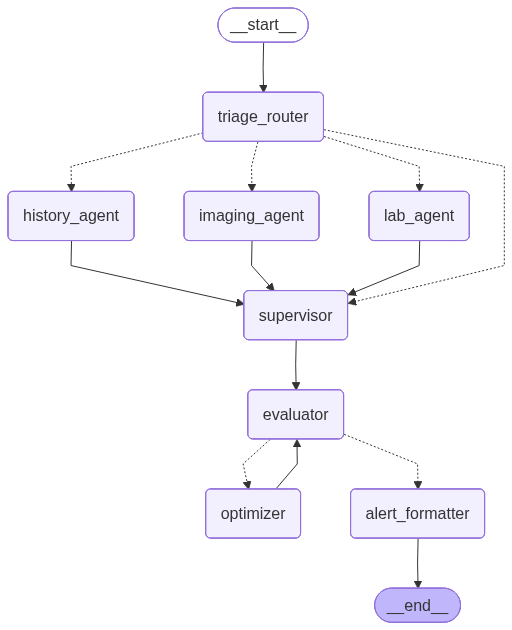


✅ This diagram is auto-generated from the compiled graph
   Use it in your writeup and video demo!


In [30]:
# ============================================================
# Cell 28: Visualize the LangGraph
# ============================================================
from IPython.display import Image as IPImage, display

try:
    graph_image = medsentinel_graph.get_graph().draw_mermaid_png()
    print("🏗️ MedSentinel AI — LangGraph Architecture:")
    display(IPImage(graph_image))
    print("\n✅ This diagram is auto-generated from the compiled graph")
    print("   Use it in your writeup and video demo!")
except Exception as e:
    # Fallback: print the Mermaid text representation
    print("⚠️ PNG rendering not available, showing Mermaid text:")
    print(medsentinel_graph.get_graph().draw_mermaid())
    print(f"\n   (To render: paste the Mermaid code into mermaid.live)")
    print(f"   Error: {e}")

In [33]:
# ============================================================
# Cell 29: Pipeline Invocation Helper
# ============================================================

def run_medsentinel(
    medical_image=None,
    lab_report_text="",
    fhir_bundle=None,
) -> dict:
    """
    Run the full MedSentinel AI agentic pipeline.
    
    This is the clean API for the entire system.
    Phase 4's Gradio dashboard will call this function.
    
    Args:
        medical_image: PIL Image of medical image (CXR, derm, fundus, etc) or None
        lab_report_text: Lab report as text string
        fhir_bundle: FHIR Bundle dict (or None)
    
    Returns:
        dict with all agent findings, safety alerts,
        and the full execution trace
    """
    if fhir_bundle is None:
        fhir_bundle = {}
    
    initial_state = {
        # Inputs
        "medical_image": medical_image,
        "lab_report_text": lab_report_text,
        "fhir_bundle": fhir_bundle,
        # Initialize empty fields
        "active_agents": [],
        "imaging_findings": {},
        "lab_findings": {},
        "clinical_history": {},
        "contradictions": [],
        "safety_alerts": [],
        "alert_count": 0,
        "formatted_summary": "",
        "evaluation_result": {},
        "eval_count": 0,
        "agent_trace": [],
    }
    
    result = medsentinel_graph.invoke(initial_state)
    return result


def print_medsentinel_report(result: dict):
    """Pretty-print the full MedSentinel AI report."""
    
    print("=" * 65)
    print("🏥 MedSentinel AI — Safety Analysis Report")
    print("=" * 65)
    
    # Execution Trace
    print("\n📋 AGENT EXECUTION TRACE")
    print("-" * 65)
    for i, trace in enumerate(result.get("agent_trace", [])):
        print(f"\n  Step {i+1}:")
        for line in trace.split("\n"):
            print(f"    {line}")
    
    # Agent Summaries
    print("\n\n📊 AGENT FINDINGS SUMMARY")
    print("-" * 65)
    
    # Imaging (defensive: handle list returns)
    img = result.get("imaging_findings", {})
    if isinstance(img, list):
        img = {"findings": img}
    if not isinstance(img, dict):
        img = {}
    img_type = img.get("image_type", "unknown")
    findings_count = len(img.get("findings", []))
    impression = img.get("impression", "N/A")
    print(f"\n  🩻 Imaging Agent ({img_type}): {findings_count} findings")
    print(f"     Impression: {str(impression)[:80]}")
    
    # Labs (defensive: handle list returns)
    lab = result.get("lab_findings", {})
    if isinstance(lab, list):
        lab = {"labs": lab}
    if not isinstance(lab, dict):
        lab = {}
    labs_count = len(lab.get("labs", []))
    critical_count = len(lab.get("critical_values", []))
    print(f"\n  🧪 Lab Agent: {labs_count} values | {critical_count} critical")
    print(f"     Interpretation: {str(lab.get('interpretation', 'N/A'))[:80]}")
    
    # History (defensive: handle list returns)
    hist = result.get("clinical_history", {})
    if isinstance(hist, list):
        hist = {"conditions": hist}
    if not isinstance(hist, dict):
        hist = {}
    demo = hist.get("demographics", {})
    if not isinstance(demo, dict):
        demo = {}
    conditions = hist.get("active_conditions", [])
    print(f"\n  📋 History Agent: {demo.get('age', '?')}yo {demo.get('sex', '?')}")
    print(f"     Conditions: {', '.join(conditions) if conditions else 'N/A'}")
    
    # Safety Alerts
    alerts = result.get("safety_alerts", [])
    print(f"\n\n🚨 SAFETY ALERTS ({len(alerts)})")
    print("-" * 65)
    
    if not alerts:
        print("\n  ✅ No safety alerts — findings are concordant across modalities")
    else:
        severity_icons = {"CRITICAL": "🔴", "HIGH": "🟠", "MEDIUM": "🟡", "LOW": "🟢"}
        for alert in alerts:
            icon = severity_icons.get(alert.get("severity", ""), "⚪")
            print(f"\n  {icon} [{alert.get('severity', 'N/A')}] {alert.get('title', 'N/A')}")
            print(f"     ID: {alert.get('alert_id', 'N/A')}")
            print(f"     Summary: {alert.get('summary', 'N/A')}")
            
            evidence = alert.get("evidence", [])
            if evidence:
                print(f"     Evidence:")
                for ev in evidence:
                    print(f"       • [{ev.get('source', '?')}] {ev.get('finding', 'N/A')}")
            
            reasoning = alert.get("reasoning", "")
            if reasoning:
                print(f"     🧠 Reasoning:")
                # Word-wrap reasoning for readable console output
                for line in reasoning:
                    line = line.strip()
                    if line:
                        print(f"        {line}.")
            
            print(f"     Recommendation: {alert.get('recommendation', 'N/A')}")
    
    # Evaluator-Optimizer Summary (if eval loop ran)
    eval_result = result.get("evaluation_result", {})
    eval_count = result.get("eval_count", 0)
    if eval_count > 0:
        print(f"\n\n🔄 EVALUATOR-OPTIMIZER LOOP")
        print("-" * 65)
        print(f"  Iterations: {eval_count}")
        print(f"  Accepted: {'Yes' if eval_result.get('accepted', True) else 'No'}")
        print(f"  Score: {eval_result.get('score', 'N/A')}")
        missed = eval_result.get("missed_patterns", [])
        if missed:
            print(f"  Missed patterns found: {len(missed)}")
            for mp in missed:
                print(f"    ⚠️ [{mp.get('severity', '?')}] {mp.get('pattern', 'N/A')}")
    
    print("\n" + "=" * 65)


print("✅ run_medsentinel() helper ready — clean API for the pipeline")
print("✅ print_medsentinel_report() ready — formatted output display")

✅ run_medsentinel() helper ready — clean API for the pipeline
✅ print_medsentinel_report() ready — formatted output display


In [34]:
# ============================================================
# Cell 30: Run Full Pipeline — Sample Patient Case
# ============================================================
import time

print("🏥 Running MedSentinel AI on sample patient case...")
print("   Patient: 68yo male, cough/fever x3 days")
print("   Data: CXR + Lab Report + FHIR Record")
print()

start_time = time.time()

result = run_medsentinel(
    medical_image=medical_image,                  # Phase 1 CXR
    lab_report_text=SAMPLE_LAB_REPORT,     # Phase 1 lab report
    fhir_bundle=SAMPLE_FHIR_BUNDLE,        # Phase 1 FHIR bundle
)

elapsed = time.time() - start_time
print(f"⏱️ Pipeline completed in {elapsed:.1f} seconds\n")

# Print the full report
print_medsentinel_report(result)

🏥 Running MedSentinel AI on sample patient case...
   Patient: 68yo male, cough/fever x3 days
   Data: CXR + Lab Report + FHIR Record

⏱️ Pipeline completed in 381.0 seconds

🏥 MedSentinel AI — Safety Analysis Report

📋 AGENT EXECUTION TRACE
-----------------------------------------------------------------

  Step 1:
    🚦 Triage Router: 3/3 agents activated
       CXR image detected → Imaging Agent activated
       Lab report text detected → Lab Agent activated
       FHIR bundle detected → History Agent activated

  Step 2:
    📋 Clinical History Agent: 69yo Male | 2 conditions | 2 medications | 1 allergies
       Conditions: Hypertension, Type 2 Diabetes Mellitus

  Step 3:
    🩻 Imaging Agent: chest_xray | 6 findings | Abnormalities: NO
       Impression: Normal chest X-ray.

  Step 4:
    🧪 Lab Report Agent: 13 values extracted | Critical: 10
       Interpretation: The patient presents with significant abnormalities across multiple laboratory tests. The CBC shows 

  Step 5:
    🧠

In [35]:
# ============================================================
# Cell 31: Synthetic Clinical Scenarios (Raw Inputs)
# ============================================================
import json

SYNTHETIC_SCENARIOS = [
    # ─── Scenario 1: Missed Pneumonia (Expected: alert) ─────
    # Elevated WBC/CRP/Procalcitonin + fever + hypoxia, but CXR is "normal"
    # The system should catch the imaging-lab contradiction
    {
        "id": "S01",
        "name": "Missed Pneumonia — Infectious markers vs normal CXR",
        "expected_alert": True,
        "expected_severity": "HIGH",
        "lab_report_text": (
            "LABORATORY REPORT\n"
            "Patient: Robert Chen | DOB: 1954-01-20 | MRN: 90001\n"
            "Collection Date: 2026-02-15 08:30\n\n"
            "COMPLETE BLOOD COUNT:\n"
            "  WBC:          16.5    K/uL    (Ref: 4.5-11.0)    [HIGH]\n"
            "  Hemoglobin:   13.8    g/dL    (Ref: 13.5-17.5)   [NORMAL]\n"
            "  Platelets:    230     K/uL    (Ref: 150-400)      [NORMAL]\n\n"
            "INFLAMMATORY MARKERS:\n"
            "  CRP:          68.0    mg/L    (Ref: 0.0-5.0)      [HIGH]\n"
            "  Procalcitonin: 3.2    ng/mL   (Ref: 0.0-0.1)     [HIGH]\n\n"
            "BASIC METABOLIC PANEL:\n"
            "  Glucose:      165     mg/dL   (Ref: 70-100)       [HIGH]\n"
            "  Creatinine:   1.1     mg/dL   (Ref: 0.7-1.3)     [NORMAL]\n"
        ),
        "fhir_bundle": {
            "resourceType": "Bundle", "type": "transaction",
            "entry": [
                {"resource": {"resourceType": "Patient", "name": [{"given": ["Robert"], "family": "Chen"}], "gender": "male", "birthDate": "1954-01-20"}},
                {"resource": {"resourceType": "Condition", "code": {"coding": [{"display": "COPD"}]}, "clinicalStatus": {"coding": [{"code": "active"}]}}},
                {"resource": {"resourceType": "Condition", "code": {"coding": [{"display": "Type 2 Diabetes Mellitus"}]}, "clinicalStatus": {"coding": [{"code": "active"}]}}},
                {"resource": {"resourceType": "MedicationRequest", "medicationCodeableConcept": {"coding": [{"display": "Metformin 500mg twice daily"}]}, "status": "active"}},
                {"resource": {"resourceType": "MedicationRequest", "medicationCodeableConcept": {"coding": [{"display": "Tiotropium inhaler daily"}]}, "status": "active"}},
                {"resource": {"resourceType": "Observation", "code": {"coding": [{"display": "Body Temperature"}]}, "valueQuantity": {"value": 39.1, "unit": "°C"}, "effectiveDateTime": "2026-02-15T08:00:00Z"}},
                {"resource": {"resourceType": "Observation", "code": {"coding": [{"display": "Heart Rate"}]}, "valueQuantity": {"value": 108, "unit": "bpm"}, "effectiveDateTime": "2026-02-15T08:00:00Z"}},
                {"resource": {"resourceType": "Observation", "code": {"coding": [{"display": "Blood Pressure"}]}, "valueQuantity": {"value": 138, "unit": "mmHg"}, "component": [{"code": {"coding": [{"display": "Systolic"}]}, "valueQuantity": {"value": 138, "unit": "mmHg"}}, {"code": {"coding": [{"display": "Diastolic"}]}, "valueQuantity": {"value": 88, "unit": "mmHg"}}], "effectiveDateTime": "2026-02-15T08:00:00Z"}},
                {"resource": {"resourceType": "Observation", "code": {"coding": [{"display": "Oxygen Saturation"}]}, "valueQuantity": {"value": 91, "unit": "%"}, "effectiveDateTime": "2026-02-15T08:00:00Z"}},
            ],
        },
    },

    # ─── Scenario 2: Medication-Renal Mismatch (Expected: alert) ──
    # NSAIDs + ACE inhibitor + elevated creatinine/K+ = nephrotoxic combo
    {
        "id": "S02",
        "name": "Nephrotoxic Medication with Acute Kidney Injury",
        "expected_alert": True,
        "expected_severity": "HIGH",
        "lab_report_text": (
            "LABORATORY REPORT\n"
            "Patient: Maria Santos | DOB: 1961-05-12 | MRN: 90002\n"
            "Collection Date: 2026-02-15 09:00\n\n"
            "RENAL FUNCTION PANEL:\n"
            "  Creatinine:   3.2     mg/dL   (Ref: 0.7-1.3)     [HIGH]\n"
            "  BUN:          45      mg/dL   (Ref: 7-20)         [HIGH]\n"
            "  Potassium:    5.8     mEq/L   (Ref: 3.5-5.0)     [HIGH]\n"
            "  Sodium:       136     mEq/L   (Ref: 136-145)      [NORMAL]\n\n"
            "COMPLETE BLOOD COUNT:\n"
            "  WBC:          8.5     K/uL    (Ref: 4.5-11.0)    [NORMAL]\n"
            "  Hemoglobin:   11.2    g/dL    (Ref: 12.0-16.0)   [LOW]\n"
        ),
        "fhir_bundle": {
            "resourceType": "Bundle", "type": "transaction",
            "entry": [
                {"resource": {"resourceType": "Patient", "name": [{"given": ["Maria"], "family": "Santos"}], "gender": "female", "birthDate": "1961-05-12"}},
                {"resource": {"resourceType": "Condition", "code": {"coding": [{"display": "Hypertension"}]}, "clinicalStatus": {"coding": [{"code": "active"}]}}},
                {"resource": {"resourceType": "Condition", "code": {"coding": [{"display": "Osteoarthritis"}]}, "clinicalStatus": {"coding": [{"code": "active"}]}}},
                {"resource": {"resourceType": "MedicationRequest", "medicationCodeableConcept": {"coding": [{"display": "Lisinopril 20mg daily"}]}, "status": "active"}},
                {"resource": {"resourceType": "MedicationRequest", "medicationCodeableConcept": {"coding": [{"display": "Ibuprofen 800mg three times daily"}]}, "status": "active"}},
                {"resource": {"resourceType": "MedicationRequest", "medicationCodeableConcept": {"coding": [{"display": "Metformin 1000mg twice daily"}]}, "status": "active"}},
                {"resource": {"resourceType": "Observation", "code": {"coding": [{"display": "Body Temperature"}]}, "valueQuantity": {"value": 36.8, "unit": "°C"}, "effectiveDateTime": "2026-02-15T09:00:00Z"}},
                {"resource": {"resourceType": "Observation", "code": {"coding": [{"display": "Heart Rate"}]}, "valueQuantity": {"value": 88, "unit": "bpm"}, "effectiveDateTime": "2026-02-15T09:00:00Z"}},
                {"resource": {"resourceType": "Observation", "code": {"coding": [{"display": "Blood Pressure"}]}, "valueQuantity": {"value": 155, "unit": "mmHg"}, "component": [{"code": {"coding": [{"display": "Systolic"}]}, "valueQuantity": {"value": 155, "unit": "mmHg"}}, {"code": {"coding": [{"display": "Diastolic"}]}, "valueQuantity": {"value": 95, "unit": "mmHg"}}], "effectiveDateTime": "2026-02-15T09:00:00Z"}},
                {"resource": {"resourceType": "Observation", "code": {"coding": [{"display": "Oxygen Saturation"}]}, "valueQuantity": {"value": 97, "unit": "%"}, "effectiveDateTime": "2026-02-15T09:00:00Z"}},
                {"resource": {"resourceType": "AllergyIntolerance", "code": {"coding": [{"display": "Sulfa drugs"}]}, "clinicalStatus": {"coding": [{"code": "active"}]}}},
            ],
        },
    },

    # ─── Scenario 3: True Negative (Expected: no alert) ─────
    # Healthy patient, all labs normal, no conditions — system should NOT alert
    {
        "id": "S03",
        "name": "Concordant Normal Findings — No Alert Expected",
        "expected_alert": False,
        "expected_severity": None,
        "lab_report_text": (
            "LABORATORY REPORT\n"
            "Patient: James Park | DOB: 1991-08-03 | MRN: 90003\n"
            "Collection Date: 2026-02-15 10:00\n\n"
            "COMPLETE BLOOD COUNT:\n"
            "  WBC:          7.2     K/uL    (Ref: 4.5-11.0)    [NORMAL]\n"
            "  Hemoglobin:   14.5    g/dL    (Ref: 13.5-17.5)   [NORMAL]\n"
            "  Platelets:    265     K/uL    (Ref: 150-400)      [NORMAL]\n\n"
            "BASIC METABOLIC PANEL:\n"
            "  Glucose:      92      mg/dL   (Ref: 70-100)       [NORMAL]\n"
            "  Creatinine:   0.9     mg/dL   (Ref: 0.7-1.3)     [NORMAL]\n"
            "  Sodium:       140     mEq/L   (Ref: 136-145)      [NORMAL]\n"
            "  Potassium:    4.1     mEq/L   (Ref: 3.5-5.0)     [NORMAL]\n"
        ),
        "fhir_bundle": {
            "resourceType": "Bundle", "type": "transaction",
            "entry": [
                {"resource": {"resourceType": "Patient", "name": [{"given": ["James"], "family": "Park"}], "gender": "male", "birthDate": "1991-08-03"}},
                {"resource": {"resourceType": "Observation", "code": {"coding": [{"display": "Body Temperature"}]}, "valueQuantity": {"value": 36.6, "unit": "°C"}, "effectiveDateTime": "2026-02-15T10:00:00Z"}},
                {"resource": {"resourceType": "Observation", "code": {"coding": [{"display": "Heart Rate"}]}, "valueQuantity": {"value": 72, "unit": "bpm"}, "effectiveDateTime": "2026-02-15T10:00:00Z"}},
                {"resource": {"resourceType": "Observation", "code": {"coding": [{"display": "Blood Pressure"}]}, "valueQuantity": {"value": 120, "unit": "mmHg"}, "component": [{"code": {"coding": [{"display": "Systolic"}]}, "valueQuantity": {"value": 120, "unit": "mmHg"}}, {"code": {"coding": [{"display": "Diastolic"}]}, "valueQuantity": {"value": 78, "unit": "mmHg"}}], "effectiveDateTime": "2026-02-15T10:00:00Z"}},
                {"resource": {"resourceType": "Observation", "code": {"coding": [{"display": "Oxygen Saturation"}]}, "valueQuantity": {"value": 99, "unit": "%"}, "effectiveDateTime": "2026-02-15T10:00:00Z"}},
            ],
        },
    },

    # ─── Scenario 4: Undiagnosed Cardiomegaly (Expected: alert) ──
    # Elevated BNP + no cardiac history = undiagnosed heart failure
    # Note: No CXR image — tests cross-modal reasoning with labs + history only
    {
        "id": "S04",
        "name": "Elevated BNP with No Cardiac History",
        "expected_alert": True,
        "expected_severity": "HIGH",
        "lab_report_text": (
            "LABORATORY REPORT\n"
            "Patient: David Kim | DOB: 1968-03-22 | MRN: 90004\n"
            "Collection Date: 2026-02-15 11:00\n\n"
            "CARDIAC MARKERS:\n"
            "  BNP:          450     pg/mL   (Ref: 0-100)        [HIGH]\n"
            "  Troponin I:   0.02    ng/mL   (Ref: 0.0-0.04)    [NORMAL]\n\n"
            "BASIC METABOLIC PANEL:\n"
            "  Creatinine:   1.4     mg/dL   (Ref: 0.7-1.3)     [HIGH]\n"
            "  Sodium:       134     mEq/L   (Ref: 136-145)      [LOW]\n"
            "  Potassium:    4.5     mEq/L   (Ref: 3.5-5.0)     [NORMAL]\n"
        ),
        "fhir_bundle": {
            "resourceType": "Bundle", "type": "transaction",
            "entry": [
                {"resource": {"resourceType": "Patient", "name": [{"given": ["David"], "family": "Kim"}], "gender": "male", "birthDate": "1968-03-22"}},
                {"resource": {"resourceType": "Condition", "code": {"coding": [{"display": "Hypertension"}]}, "clinicalStatus": {"coding": [{"code": "active"}]}}},
                {"resource": {"resourceType": "MedicationRequest", "medicationCodeableConcept": {"coding": [{"display": "Amlodipine 10mg daily"}]}, "status": "active"}},
                {"resource": {"resourceType": "Observation", "code": {"coding": [{"display": "Body Temperature"}]}, "valueQuantity": {"value": 36.5, "unit": "°C"}, "effectiveDateTime": "2026-02-15T11:00:00Z"}},
                {"resource": {"resourceType": "Observation", "code": {"coding": [{"display": "Heart Rate"}]}, "valueQuantity": {"value": 92, "unit": "bpm"}, "effectiveDateTime": "2026-02-15T11:00:00Z"}},
                {"resource": {"resourceType": "Observation", "code": {"coding": [{"display": "Blood Pressure"}]}, "valueQuantity": {"value": 160, "unit": "mmHg"}, "component": [{"code": {"coding": [{"display": "Systolic"}]}, "valueQuantity": {"value": 160, "unit": "mmHg"}}, {"code": {"coding": [{"display": "Diastolic"}]}, "valueQuantity": {"value": 100, "unit": "mmHg"}}], "effectiveDateTime": "2026-02-15T11:00:00Z"}},
                {"resource": {"resourceType": "Observation", "code": {"coding": [{"display": "Oxygen Saturation"}]}, "valueQuantity": {"value": 95, "unit": "%"}, "effectiveDateTime": "2026-02-15T11:00:00Z"}},
            ],
        },
    },

    # ─── Scenario 5: Occult Sepsis (Expected: alert) ────────
    # Elevated lactate + leukopenia + immunosuppressed, but normal-looking vitals
    {
        "id": "S05",
        "name": "Elevated Lactate with Deceptively Normal Vitals",
        "expected_alert": True,
        "expected_severity": "CRITICAL",
        "lab_report_text": (
            "LABORATORY REPORT\n"
            "Patient: Helen Wong | DOB: 1956-11-08 | MRN: 90005\n"
            "Collection Date: 2026-02-15 12:00\n\n"
            "COMPLETE BLOOD COUNT:\n"
            "  WBC:          2.1     K/uL    (Ref: 4.5-11.0)    [LOW]\n"
            "  Hemoglobin:   10.8    g/dL    (Ref: 12.0-16.0)   [LOW]\n"
            "  Platelets:    95      K/uL    (Ref: 150-400)      [LOW]\n\n"
            "METABOLIC & SEPSIS MARKERS:\n"
            "  Lactate:      4.8     mmol/L  (Ref: 0.5-2.0)     [HIGH]\n"
            "  Creatinine:   1.6     mg/dL   (Ref: 0.7-1.3)     [HIGH]\n"
            "  Glucose:      58      mg/dL   (Ref: 70-100)       [LOW]\n"
        ),
        "fhir_bundle": {
            "resourceType": "Bundle", "type": "transaction",
            "entry": [
                {"resource": {"resourceType": "Patient", "name": [{"given": ["Helen"], "family": "Wong"}], "gender": "female", "birthDate": "1956-11-08"}},
                {"resource": {"resourceType": "Condition", "code": {"coding": [{"display": "Rheumatoid Arthritis"}]}, "clinicalStatus": {"coding": [{"code": "active"}]}}},
                {"resource": {"resourceType": "MedicationRequest", "medicationCodeableConcept": {"coding": [{"display": "Methotrexate 15mg weekly"}]}, "status": "active"}},
                {"resource": {"resourceType": "MedicationRequest", "medicationCodeableConcept": {"coding": [{"display": "Prednisone 10mg daily"}]}, "status": "active"}},
                {"resource": {"resourceType": "Observation", "code": {"coding": [{"display": "Body Temperature"}]}, "valueQuantity": {"value": 36.2, "unit": "°C"}, "effectiveDateTime": "2026-02-15T12:00:00Z"}},
                {"resource": {"resourceType": "Observation", "code": {"coding": [{"display": "Heart Rate"}]}, "valueQuantity": {"value": 85, "unit": "bpm"}, "effectiveDateTime": "2026-02-15T12:00:00Z"}},
                {"resource": {"resourceType": "Observation", "code": {"coding": [{"display": "Blood Pressure"}]}, "valueQuantity": {"value": 108, "unit": "mmHg"}, "component": [{"code": {"coding": [{"display": "Systolic"}]}, "valueQuantity": {"value": 108, "unit": "mmHg"}}, {"code": {"coding": [{"display": "Diastolic"}]}, "valueQuantity": {"value": 68, "unit": "mmHg"}}], "effectiveDateTime": "2026-02-15T12:00:00Z"}},
                {"resource": {"resourceType": "Observation", "code": {"coding": [{"display": "Oxygen Saturation"}]}, "valueQuantity": {"value": 96, "unit": "%"}, "effectiveDateTime": "2026-02-15T12:00:00Z"}},
                {"resource": {"resourceType": "AllergyIntolerance", "code": {"coding": [{"display": "Penicillin"}]}, "clinicalStatus": {"coding": [{"code": "active"}]}}},
            ],
        },
    },

    # ─── Scenario 6: Expected Pleural Effusion (Expected: no alert) ──
    # Known cirrhosis patient — effusion + abnormal LFTs are expected baseline
    {
        "id": "S06",
        "name": "Known Liver Disease with Expected Effusion — No Alert",
        "expected_alert": False,
        "expected_severity": None,
        "lab_report_text": (
            "LABORATORY REPORT\n"
            "Patient: Thomas Reed | DOB: 1971-04-15 | MRN: 90006\n"
            "Collection Date: 2026-02-15 13:00\n\n"
            "LIVER FUNCTION PANEL:\n"
            "  Albumin:      2.1     g/dL    (Ref: 3.5-5.0)     [LOW]\n"
            "  INR:          1.8              (Ref: 0.8-1.2)     [HIGH]\n"
            "  Bilirubin:    3.5     mg/dL   (Ref: 0.1-1.2)     [HIGH]\n"
            "  AST:          55      U/L     (Ref: 10-40)        [HIGH]\n"
            "  ALT:          48      U/L     (Ref: 7-56)         [NORMAL]\n\n"
            "COMPLETE BLOOD COUNT:\n"
            "  WBC:          5.5     K/uL    (Ref: 4.5-11.0)    [NORMAL]\n"
            "  Platelets:    82      K/uL    (Ref: 150-400)      [LOW]\n"
        ),
        "fhir_bundle": {
            "resourceType": "Bundle", "type": "transaction",
            "entry": [
                {"resource": {"resourceType": "Patient", "name": [{"given": ["Thomas"], "family": "Reed"}], "gender": "male", "birthDate": "1971-04-15"}},
                {"resource": {"resourceType": "Condition", "code": {"coding": [{"display": "Cirrhosis"}]}, "clinicalStatus": {"coding": [{"code": "active"}]}}},
                {"resource": {"resourceType": "Condition", "code": {"coding": [{"display": "Portal Hypertension"}]}, "clinicalStatus": {"coding": [{"code": "active"}]}}},
                {"resource": {"resourceType": "Condition", "code": {"coding": [{"display": "Chronic Ascites"}]}, "clinicalStatus": {"coding": [{"code": "active"}]}}},
                {"resource": {"resourceType": "Condition", "code": {"coding": [{"display": "Recurrent Pleural Effusions"}]}, "clinicalStatus": {"coding": [{"code": "active"}]}}},
                {"resource": {"resourceType": "MedicationRequest", "medicationCodeableConcept": {"coding": [{"display": "Spironolactone 100mg daily"}]}, "status": "active"}},
                {"resource": {"resourceType": "MedicationRequest", "medicationCodeableConcept": {"coding": [{"display": "Furosemide 40mg daily"}]}, "status": "active"}},
                {"resource": {"resourceType": "MedicationRequest", "medicationCodeableConcept": {"coding": [{"display": "Lactulose 30mL three times daily"}]}, "status": "active"}},
                {"resource": {"resourceType": "MedicationRequest", "medicationCodeableConcept": {"coding": [{"display": "Rifaximin 550mg twice daily"}]}, "status": "active"}},
                {"resource": {"resourceType": "Observation", "code": {"coding": [{"display": "Body Temperature"}]}, "valueQuantity": {"value": 36.4, "unit": "°C"}, "effectiveDateTime": "2026-02-15T13:00:00Z"}},
                {"resource": {"resourceType": "Observation", "code": {"coding": [{"display": "Heart Rate"}]}, "valueQuantity": {"value": 78, "unit": "bpm"}, "effectiveDateTime": "2026-02-15T13:00:00Z"}},
                {"resource": {"resourceType": "Observation", "code": {"coding": [{"display": "Blood Pressure"}]}, "valueQuantity": {"value": 110, "unit": "mmHg"}, "component": [{"code": {"coding": [{"display": "Systolic"}]}, "valueQuantity": {"value": 110, "unit": "mmHg"}}, {"code": {"coding": [{"display": "Diastolic"}]}, "valueQuantity": {"value": 65, "unit": "mmHg"}}], "effectiveDateTime": "2026-02-15T13:00:00Z"}},
                {"resource": {"resourceType": "Observation", "code": {"coding": [{"display": "Oxygen Saturation"}]}, "valueQuantity": {"value": 97, "unit": "%"}, "effectiveDateTime": "2026-02-15T13:00:00Z"}},
            ],
        },
    },
]

print(f"✅ {len(SYNTHETIC_SCENARIOS)} synthetic clinical scenarios defined")
print()
for s in SYNTHETIC_SCENARIOS:
    expect = "🚨 Alert expected" if s["expected_alert"] else "✅ No alert expected"
    print(f"   [{s['id']}] {s['name']}")
    print(f"         {expect}")

✅ 6 synthetic clinical scenarios defined

   [S01] Missed Pneumonia — Infectious markers vs normal CXR
         🚨 Alert expected
   [S02] Nephrotoxic Medication with Acute Kidney Injury
         🚨 Alert expected
   [S03] Concordant Normal Findings — No Alert Expected
         ✅ No alert expected
   [S04] Elevated BNP with No Cardiac History
         🚨 Alert expected
   [S05] Elevated Lactate with Deceptively Normal Vitals
         🚨 Alert expected
   [S06] Known Liver Disease with Expected Effusion — No Alert
         ✅ No alert expected


In [36]:
# ============================================================
# Cell 32: Run Synthetic Scenarios Through Full Pipeline
# ============================================================
import time

print("🧪 Running synthetic scenarios through FULL LangGraph pipeline...")
print("   Pipeline: Triage → Agents → Supervisor → Evaluator ⇄ Optimizer → Formatter")
print("=" * 65)

scenario_results = []

for scenario in SYNTHETIC_SCENARIOS:
    print(f"\n── [{scenario['id']}] {scenario['name']} ──")
    
    start = time.time()
    
    # Run through the full LangGraph pipeline via run_medsentinel()
    result = run_medsentinel(
        medical_image=None,  # Text-only scenarios — imaging agent skipped by triage
        lab_report_text=scenario["lab_report_text"],
        fhir_bundle=scenario["fhir_bundle"],
    )
    
    elapsed = time.time() - start
    
    # Show execution trace summary
    trace = result.get("agent_trace", [])
    print(f"   Trace: {len(trace)} steps completed")
    for step in trace:
        # Show first line of each trace entry
        first_line = step.split("\n")[0] if step else ""
        print(f"     {first_line}")
    
    # Evaluate
    alerts = result.get("safety_alerts", [])
    has_alert = len(alerts) > 0
    expected = scenario["expected_alert"]
    correct = has_alert == expected
    
    status = "✅ CORRECT" if correct else "❌ WRONG"
    
    result_entry = {
        "id": scenario["id"],
        "name": scenario["name"],
        "expected_alert": expected,
        "got_alert": has_alert,
        "alert_count": len(alerts),
        "correct": correct,
        "alerts": alerts,
        "time_s": elapsed,
    }
    scenario_results.append(result_entry)
    
    print(f"   Expected alert: {'Yes' if expected else 'No'}")
    print(f"   Got alert(s):   {'Yes' if has_alert else 'No'} ({len(alerts)} alerts)")
    print(f"   Result: {status} | Time: {elapsed:.1f}s")
    
    if alerts:
        for alert in alerts:
            print(f"   → [{alert.get('severity', '?')}] {alert.get('title', 'N/A')}")
            reasoning = alert.get("reasoning", "")
            if reasoning:
                print(f"     Reasoning: {reasoning[:150]}...")

# Summary
print("\n\n" + "=" * 65)
print("📊 SYNTHETIC SCENARIO EVALUATION SUMMARY")
print("=" * 65)

correct_count = sum(1 for r in scenario_results if r["correct"])
total = len(scenario_results)
accuracy = correct_count / total * 100

# Compute precision / recall
true_positives = sum(1 for r in scenario_results if r["got_alert"] and r["expected_alert"])
false_positives = sum(1 for r in scenario_results if r["got_alert"] and not r["expected_alert"])
false_negatives = sum(1 for r in scenario_results if not r["got_alert"] and r["expected_alert"])
true_negatives = sum(1 for r in scenario_results if not r["got_alert"] and not r["expected_alert"])

precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0
recall = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print(f"\n   Accuracy:  {correct_count}/{total} ({accuracy:.0f}%)")
print(f"   Precision: {precision:.2f}")
print(f"   Recall:    {recall:.2f}")
print(f"   F1 Score:  {f1:.2f}")
print(f"\n   TP: {true_positives} | FP: {false_positives} | FN: {false_negatives} | TN: {true_negatives}")

print(f"\n   Results by scenario:")
for r in scenario_results:
    icon = "✅" if r["correct"] else "❌"
    print(f"   {icon} [{r['id']}] {r['name'][:50]}")

🧪 Running synthetic scenarios through FULL LangGraph pipeline...
   Pipeline: Triage → Agents → Supervisor → Evaluator ⇄ Optimizer → Formatter

── [S01] Missed Pneumonia — Infectious markers vs normal CXR ──
   Trace: 6 steps completed
     🚦 Triage Router: 2/3 agents activated
     📋 Clinical History Agent: 72yo Male | 2 conditions | 2 medications | 0 allergies
     🧪 Lab Report Agent: 7 values extracted | Critical: 4
     🧠 Supervisor Agent: 1 safety alert(s) generated
     ✅ Evaluator (iter 1): ACCEPTED — score 0.5
     📋 Alert Formatter: 1 alerts formatted and sorted by severity
   Expected alert: Yes
   Got alert(s):   Yes (1 alerts)
   Result: ✅ CORRECT | Time: 268.6s
   → [CRITICAL] Infection/Inflammation with Hypoxia
     Reasoning: 1. The patient presents with fever (39.1°C), tachycardia (108 bpm), hypoxia (91% SpO2), and significant laboratory abnormalities. 2. The lab results s...

── [S02] Nephrotoxic Medication with Acute Kidney Injury ──
   Trace: 6 steps completed
     🚦

In [37]:
# ============================================================
# Cell 33: Error Analysis
# ============================================================

failures = [r for r in scenario_results if not r["correct"]]

print("🔍 ERROR ANALYSIS")
print("=" * 65)

if not failures:
    print("\n   ✅ All scenarios classified correctly!")
    print("   Note: This is on a small synthetic test set.")
    print("   Real-world performance would likely be lower due to:")
    print("   - Subtle imaging findings that are harder to detect")
    print("   - Ambiguous lab patterns with multiple interpretations")
    print("   - Complex multi-morbidity patients")
    print("   - Prompt sensitivity in MedGemma's reasoning")
else:
    print(f"\n   {len(failures)} scenario(s) classified incorrectly:\n")
    for f in failures:
        print(f"   ❌ [{f['id']}] {f['name']}")
        if f["expected_alert"] and not f["got_alert"]:
            print(f"      Type: FALSE NEGATIVE (missed an alert)")
            print(f"      Impact: A real safety concern was not flagged")
            print(f"      Possible cause: Supervisor didn't detect the cross-modal contradiction")
        elif not f["expected_alert"] and f["got_alert"]:
            print(f"      Type: FALSE POSITIVE (false alarm)")
            print(f"      Impact: Alert fatigue — clinicians may ignore future real alerts")
            print(f"      Alerts generated:")
            for alert in f.get("alerts", []):
                print(f"        → [{alert.get('severity', '?')}] {alert.get('title', 'N/A')}")
        print()

print("\n📌 These results will feed into Phase 5 (Evaluation & Metrics)")
print("   and Phase 6 (Technical Writeup — honest limitations section)")

🔍 ERROR ANALYSIS

   1 scenario(s) classified incorrectly:

   ❌ [S06] Known Liver Disease with Expected Effusion — No Alert
      Type: FALSE POSITIVE (false alarm)
      Impact: Alert fatigue — clinicians may ignore future real alerts
      Alerts generated:
        → [CRITICAL] Thrombocytopenia in the setting of Cirrhosis


📌 These results will feed into Phase 5 (Evaluation & Metrics)
   and Phase 6 (Technical Writeup — honest limitations section)


In [38]:
# ============================================================
# Cell 34: Phase 3 Summary
# ============================================================
print("=" * 65)
print("🏥 MedSentinel AI — Phase 3 Complete!")
print("=" * 65)
print()
print("✅ Supervisor Agent node — cross-modal contradiction detection")
print("✅ Alert Formatter node — standardized severity-sorted alerts")
print("✅ Conditional routing function — dynamic agent selection")
print("✅ Full LangGraph compiled — 8 nodes, conditional fan-out/fan-in, evaluator-optimizer loop")
print("✅ Graph visualized — auto-generated architecture diagram")
print("✅ Invocation helper — clean API: run_medsentinel()")
print("✅ Full pipeline tested — sample patient case end-to-end")
print(f"✅ {len(SYNTHETIC_SCENARIOS)} synthetic scenarios evaluated")
print(f"   Precision: {precision:.2f} | Recall: {recall:.2f} | F1: {f1:.2f}")
print()
print("🔗 LangGraph Agentic Patterns Demonstrated:")
print("   • Conditional routing (Triage Router → dynamic agent selection)")
print("   • Parallel fan-out (3 agents run simultaneously)")
print("   • Fan-in convergence (Supervisor waits for all agents)")
print("   • Stateful execution trace (full audit trail)")
print("   • Visualizable graph (architecture diagram from code)")
print()
print("📌 Next: Phase 4 — Gradio Dashboard")
print("   - Build interactive interface calling run_medsentinel()")
print("   - Display execution trace, agent findings, and alerts")
print("   - Pre-load 3 example cases for judges to click through")
print("   - Embed the LangGraph visualization in the UI")
print("=" * 65)

🏥 MedSentinel AI — Phase 3 Complete!

✅ Supervisor Agent node — cross-modal contradiction detection
✅ Alert Formatter node — standardized severity-sorted alerts
✅ Conditional routing function — dynamic agent selection
✅ Full LangGraph compiled — 8 nodes, conditional fan-out/fan-in, evaluator-optimizer loop
✅ Graph visualized — auto-generated architecture diagram
✅ Invocation helper — clean API: run_medsentinel()
✅ Full pipeline tested — sample patient case end-to-end
✅ 6 synthetic scenarios evaluated
   Precision: 0.80 | Recall: 1.00 | F1: 0.89

🔗 LangGraph Agentic Patterns Demonstrated:
   • Conditional routing (Triage Router → dynamic agent selection)
   • Parallel fan-out (3 agents run simultaneously)
   • Fan-in convergence (Supervisor waits for all agents)
   • Stateful execution trace (full audit trail)
   • Visualizable graph (architecture diagram from code)

📌 Next: Phase 4 — Gradio Dashboard
   - Build interactive interface calling run_medsentinel()
   - Display execution trac

# 🏥 MedSentinel AI — Phase 4: Gradio Demo Dashboard

> **Competition:** MedGemma Impact Challenge | **Target Prize:** 🏆 Agentic Workflow Prize  
> **Interface:** Gradio Blocks (embedded in Kaggle notebook)  
> **Backend:** LangGraph StateGraph (compiled in Phase 3)

---

In this Phase 4 notebook, we will:

1. **Install Gradio** — add the UI framework to our notebook
2. **Build HTML formatting utilities** — convert agent outputs into styled visual components
3. **Define 3 pre-loaded example cases** — one-click demos for judges
4. **Build the full Gradio Blocks dashboard** with:
   - 🩻 Medical image upload
   - 🧪 Lab report text input
   - 📋 FHIR JSON input
   - 🏗️ LangGraph architecture diagram
   - 📋 Agent execution trace (step-by-step)
   - 🧪 Color-coded lab value table
   - 📋 Patient clinical summary
   - 🚨 Safety alerts with severity badges and evidence chains
5. **Launch the demo** — inline in the Kaggle notebook

In [39]:
# ============================================================
# Cell 35: Install Gradio
# ============================================================
!pip install --quiet gradio

import gradio as gr
print(f"✅ Gradio installed: v{gr.__version__}")
print("   Gradio renders interactive UIs directly in the notebook")

✅ Gradio installed: v5.50.0
   Gradio renders interactive UIs directly in the notebook


In [40]:
# ============================================================
# Cell 36: HTML Formatting Utilities
# ============================================================

def format_alerts_html(alerts: list) -> str:
    """Convert safety alerts into styled HTML cards."""
    if not alerts:
        return """
        <div style="padding:20px; background:#d4edda; border-radius:8px;
                    border-left:5px solid #28a745; margin:10px 0;">
            <h3 style="margin:0; color:#155724;">✅ No Safety Alerts</h3>
            <p style="margin:5px 0 0; color:#155724;">
                All findings are concordant across modalities. No missed diagnoses detected.
            </p>
        </div>
        """
    
    severity_styles = {
        "CRITICAL": {"bg": "#f8d7da", "border": "#dc3545", "color": "#721c24", "icon": "🔴"},
        "HIGH":     {"bg": "#fff3cd", "border": "#ffc107", "color": "#856404", "icon": "🟠"},
        "MEDIUM":   {"bg": "#fff3cd", "border": "#fd7e14", "color": "#856404", "icon": "🟡"},
        "LOW":      {"bg": "#d1ecf1", "border": "#17a2b8", "color": "#0c5460", "icon": "🟢"},
    }
    
    html = f'<div style="margin:5px 0;"><strong>🚨 {len(alerts)} Safety Alert(s)</strong></div>'
    
    for alert in alerts:
        sev = alert.get("severity", "MEDIUM")
        style = severity_styles.get(sev, severity_styles["MEDIUM"])
        
        evidence_html = ""
        for ev in alert.get("evidence", []):
            source = ev.get("source", "unknown")
            source_icons = {"imaging": "🩻", "labs": "🧪", "history": "📋"}
            icon = source_icons.get(source, "📌")
            evidence_html += f"""
                <div style="padding:4px 8px; margin:2px 0; background:rgba(255,255,255,0.5);
                            border-radius:4px; font-size:0.9em;">
                    {icon} <strong>[{source.upper()}]</strong> {ev.get('finding', 'N/A')}
                </div>"""
        
        html += f"""
        <div style="padding:15px; background:{style['bg']}; border-radius:8px;
                    border-left:5px solid {style['border']}; margin:10px 0;">
            <div style="display:flex; align-items:center; gap:8px; margin-bottom:8px;">
                <span style="font-size:1.2em;">{style['icon']}</span>
                <span style="background:{style['border']}; color:white; padding:2px 10px;
                       border-radius:12px; font-size:0.85em; font-weight:bold;">{sev}</span>
                <strong style="color:{style['color']}; font-size:1.05em;">
                    {alert.get('alert_id', '')} — {alert.get('title', 'Untitled')}
                </strong>
            </div>
            <p style="margin:5px 0; color:{style['color']};">{alert.get('summary', 'N/A')}</p>
            <details style="margin-top:8px; background:rgba(255,255,255,0.6); border-radius:6px;
                           padding:2px;">
                <summary style="cursor:pointer; padding:8px 10px; font-weight:bold;
                                font-size:0.9em; color:#333;">
                    🧠 Clinical Reasoning (click to expand)
                </summary>
                <div style="padding:10px 12px; font-size:0.9em; line-height:1.6;
                            color:#333; white-space:pre-wrap;">
                    {' '.join(alert['reasoning']) if isinstance(alert.get('reasoning'), list) else alert.get('reasoning', 'No detailed reasoning provided')}
                </div>
            </details>
            {f'<div style="margin-top:8px;"><strong style="font-size:0.9em;">Evidence Chain:</strong>{evidence_html}</div>' if evidence_html else ''}
            <div style="margin-top:8px; padding:8px; background:rgba(255,255,255,0.5);
                        border-radius:4px;">
                <strong style="font-size:0.9em;">💡 Recommendation:</strong>
                <span style="font-size:0.9em;">{alert.get('recommendation', 'N/A')}</span>
            </div>
        </div>
        """
    
    return html


def format_labs_html(lab_findings: dict) -> str:
    """Convert lab findings into a styled HTML table."""
    if not lab_findings:
        return "<p style='color:#666;'>No lab values extracted</p>"
    # Defensive: if agent returned a list instead of dict
    if isinstance(lab_findings, list):
        lab_findings = {"labs": lab_findings}
    if not isinstance(lab_findings, dict):
        return "<p style='color:#666;'>No lab values extracted</p>"
    labs = lab_findings.get("labs", [])
    if not labs:
        return "<p style='color:#666;'>No lab values extracted</p>"
    
    rows = ""
    for lab in labs:
        flag = lab.get("flag", "NORMAL")
        if flag == "HIGH":
            flag_style = "color:#dc3545; font-weight:bold;"
            flag_display = "🔴 HIGH"
        elif flag == "LOW":
            flag_style = "color:#0d6efd; font-weight:bold;"
            flag_display = "🔵 LOW"
        else:
            flag_style = "color:#28a745;"
            flag_display = "🟢 NORMAL"
        
        rows += f"""
        <tr>
            <td style="padding:6px 12px; border-bottom:1px solid #eee;">{lab.get('test', 'N/A')}</td>
            <td style="padding:6px 12px; border-bottom:1px solid #eee; text-align:right;
                        font-family:monospace;">{lab.get('value', 'N/A')}</td>
            <td style="padding:6px 12px; border-bottom:1px solid #eee;">{lab.get('unit', '')}</td>
            <td style="padding:6px 12px; border-bottom:1px solid #eee; color:#666;
                        font-size:0.9em;">{lab.get('reference_range', 'N/A')}</td>
            <td style="padding:6px 12px; border-bottom:1px solid #eee; {flag_style}">{flag_display}</td>
        </tr>
        """
    
    interpretation = lab_findings.get("interpretation", "")
    interpretation_html = ""
    if interpretation:
        interpretation_html = f"""
        <div style="margin-top:10px; padding:10px; background:#f8f9fa; border-radius:6px;">
            <strong>💡 Interpretation:</strong> {interpretation}
        </div>"""
    
    return f"""
    <table style="width:100%; border-collapse:collapse; font-size:0.95em;">
        <thead>
            <tr style="background:#f8f9fa;">
                <th style="padding:8px 12px; text-align:left; border-bottom:2px solid #dee2e6;">Test</th>
                <th style="padding:8px 12px; text-align:right; border-bottom:2px solid #dee2e6;">Value</th>
                <th style="padding:8px 12px; text-align:left; border-bottom:2px solid #dee2e6;">Unit</th>
                <th style="padding:8px 12px; text-align:left; border-bottom:2px solid #dee2e6;">Reference</th>
                <th style="padding:8px 12px; text-align:left; border-bottom:2px solid #dee2e6;">Flag</th>
            </tr>
        </thead>
        <tbody>{rows}</tbody>
    </table>
    {interpretation_html}
    """


def format_history_html(clinical_history: dict) -> str:
    """Convert clinical history into a styled patient summary card."""
    if not clinical_history:
        return "<p style='color:#666;'>No clinical history available</p>"
    # Defensive: if agent returned a list instead of dict
    if isinstance(clinical_history, list):
        clinical_history = {"conditions": clinical_history}
    if not isinstance(clinical_history, dict):
        return "<p style='color:#666;'>No clinical history available</p>"
    if clinical_history.get("parse_error"):
        return "<p style='color:#666;'>No clinical history available</p>"
    
    demo = clinical_history.get("demographics", {})
    conditions = clinical_history.get("active_conditions", [])
    meds = clinical_history.get("medications", [])
    allergies = clinical_history.get("allergies", [])
    vitals = clinical_history.get("vitals", {})
    risk_factors = clinical_history.get("risk_factors", [])
    
    conditions_html = ", ".join(conditions) if conditions else "<em>None</em>"
    meds_html = ", ".join(meds) if meds else "<em>None</em>"
    allergies_html = ", ".join(f"<span style='color:#dc3545; font-weight:bold;'>⚠ {a}</span>" for a in allergies) if allergies else "<em>None</em>"
    risk_html = ", ".join(risk_factors) if risk_factors else "<em>None</em>"
    
    vitals_items = []
    for key, val in vitals.items():
        label = key.replace("_", " ").replace("c", "°C").replace("bpm", " bpm").replace("pct", "%")
        vitals_items.append(f"<span style='margin-right:15px;'><strong>{key}:</strong> {val}</span>")
    vitals_html = " ".join(vitals_items) if vitals_items else "<em>No vitals</em>"
    
    return f"""
    <div style="padding:15px; background:#f8f9fa; border-radius:8px; border:1px solid #dee2e6;">
        <h4 style="margin:0 0 10px; color:#495057;">
            👤 {demo.get('age', '?')} year old {demo.get('sex', 'Unknown')}
        </h4>
        <div style="display:grid; grid-template-columns:1fr 1fr; gap:10px;">
            <div><strong>🏥 Conditions:</strong> {conditions_html}</div>
            <div><strong>💊 Medications:</strong> {meds_html}</div>
            <div><strong>⚠️ Allergies:</strong> {allergies_html}</div>
            <div><strong>🔍 Risk Factors:</strong> {risk_html}</div>
        </div>
        <div style="margin-top:10px; padding:8px; background:white; border-radius:4px;">
            <strong>🌡️ Vitals:</strong> {vitals_html}
        </div>
        <div style="margin-top:8px; color:#666; font-size:0.9em;">
            {clinical_history.get('relevant_history', '')}
        </div>
    </div>
    """


def format_trace_html(agent_trace: list) -> str:
    """Convert execution trace into a styled timeline."""
    if not agent_trace:
        return "<p style='color:#666;'>No execution trace available</p>"
    
    steps_html = ""
    step_colors = ["#4a90d9", "#50b86c", "#f5a623", "#e74c3c", "#9b59b6", "#1abc9c"]
    
    for i, trace in enumerate(agent_trace):
        color = step_colors[i % len(step_colors)]
        # Escape HTML and preserve line breaks
        trace_escaped = trace.replace("&", "&amp;").replace("<", "&lt;").replace(">", "&gt;")
        trace_lines = trace_escaped.replace("\n", "<br>")
        
        steps_html += f"""
        <div style="display:flex; gap:12px; margin:8px 0;">
            <div style="min-width:32px; height:32px; background:{color}; border-radius:50%;
                        display:flex; align-items:center; justify-content:center;
                        color:white; font-weight:bold; font-size:0.85em;">{i+1}</div>
            <div style="flex:1; padding:10px 14px; background:#f8f9fa; border-radius:8px;
                        border-left:3px solid {color}; font-family:monospace; font-size:0.88em;
                        line-height:1.5;">
                {trace_lines}
            </div>
        </div>
        """
    
    return f"""
    <div style="padding:5px;">
        <div style="font-size:0.9em; color:#666; margin-bottom:8px;">
            Each step represents a LangGraph node execution
        </div>
        {steps_html}
    </div>
    """


def format_imaging_html(imaging_findings: dict) -> str:
    """Convert imaging findings into styled HTML."""
    if not imaging_findings:
        return "<p style='color:#666;'>No imaging findings available</p>"
    # Defensive: if agent returned a list instead of dict
    if isinstance(imaging_findings, list):
        imaging_findings = {"findings": imaging_findings}
    if not isinstance(imaging_findings, dict):
        return "<p style='color:#666;'>No imaging findings available</p>"
    if imaging_findings.get("parse_error"):
        return "<p style='color:#666;'>No imaging findings available</p>"
    
    findings = imaging_findings.get("findings", [])
    impression = imaging_findings.get("impression", "N/A")
    has_abnormal = imaging_findings.get("abnormalities_detected", False)
    
    status_style = "color:#dc3545; font-weight:bold;" if has_abnormal else "color:#28a745;"
    status_text = "⚠️ Abnormalities Detected" if has_abnormal else "✅ No Abnormalities"
    
    findings_html = ""
    for f in findings:
        sev = f.get("severity", "normal")
        sev_color = {"severe": "#dc3545", "moderate": "#fd7e14", "mild": "#ffc107"}.get(sev, "#28a745")
        conf = f.get("confidence", 0)
        conf_pct = int(conf * 100) if conf <= 1 else int(conf)
        
        findings_html += f"""
        <div style="padding:6px 10px; margin:4px 0; background:#f8f9fa; border-radius:4px;
                    border-left:3px solid {sev_color};">
            <strong>{f.get('region', 'N/A')}</strong>: {f.get('finding', 'N/A')}
            <span style="float:right; color:#666; font-size:0.85em;">
                [{sev}] {conf_pct}% confidence
            </span>
        </div>"""
    
    return f"""
    <div style="padding:10px;">
        <div style="{status_style} font-size:1.05em; margin-bottom:10px;">{status_text}</div>
        <div style="margin-bottom:10px;">{findings_html if findings_html else '<em>No detailed findings</em>'}</div>
        <div style="padding:10px; background:#e9ecef; border-radius:6px;">
            <strong>📝 Impression:</strong> {impression}
        </div>
    </div>
    """


print("✅ All HTML formatting utilities defined")
print("   format_alerts_html()  — severity-badged alert cards")
print("   format_labs_html()    — color-coded lab value table")
print("   format_history_html() — patient summary card")
print("   format_trace_html()   — execution trace timeline")
print("   format_imaging_html() — imaging findings display")
print("   format_pipeline_flow_html() — Daggr-style pipeline flow graph")

✅ All HTML formatting utilities defined
   format_alerts_html()  — severity-badged alert cards
   format_labs_html()    — color-coded lab value table
   format_history_html() — patient summary card
   format_trace_html()   — execution trace timeline
   format_imaging_html() — imaging findings display
   format_pipeline_flow_html() — Daggr-style pipeline flow graph


In [41]:
# Cell 36b: Pipeline Flow Graph Formatter (Daggr-style, Light Theme)
# ============================================================

def format_pipeline_flow_html(result: dict) -> str:
    """
    Daggr-style horizontal pipeline flow. Light theme, SVG Bezier connectors,
    click-to-expand on all nodes. Uses CSS classes for compact output.
    """
    active = result.get("active_agents", [])
    img_f = result.get("imaging_findings", {})
    lab_f = result.get("lab_findings", {})
    hist = result.get("clinical_history", {})
    alerts = result.get("safety_alerts", [])
    n_alerts = result.get("alert_count", 0)
    if isinstance(img_f, list): img_f = {"findings": img_f}
    if isinstance(lab_f, list): lab_f = {"labs": lab_f}
    if isinstance(hist, list): hist = {"conditions": hist}
    if isinstance(alerts, dict): alerts = [alerts]

    has = lambda a: a in active
    def e(s): return str(s).replace("&","&amp;").replace("<","&lt;").replace(">","&gt;").replace('"',"&quot;")

    findings = img_f.get("findings", [])
    img_sum = ("⚠️" if img_f.get("abnormalities_detected") else "✅") + f" {len(findings)} finding(s)" if has("imaging_agent") else ""
    labs = [l for l in lab_f.get("labs", []) if isinstance(l, dict)]
    abn = [l for l in labs if l.get("flag","NORMAL") != "NORMAL"]
    lab_sum = f"{len(abn)} abnormal / {len(labs)} total"
    dm = hist.get("demographics", {})
    conds = hist.get("active_conditions", hist.get("conditions", []))
    hist_sum = f"{e(hist.get('name','?'))}, {dm.get('age','?')}yo {dm.get('sex','?')}"

    img_det = ""
    for f in findings:
        sc = {"severe":"cr","moderate":"hi","mild":"md"}.get(f.get("severity",""),"ok")
        img_det += '<div class="pf-row pf-l' + sc + '"><b>' + e(f.get("region","")) + '</b>: ' + e(f.get("finding","")) + ' <span class="pf-r">' + str(f.get("severity","")) + " · " + str(int(f.get("confidence",0)*100)) + '%</span></div>'
    imp = e(img_f.get("impression",""))
    if imp: img_det += '<div class="pf-box"><span class="pf-lbl">IMPRESSION:</span> ' + imp + '</div>'

    lab_det = '<table class="pf-tbl"><tr><th>Test</th><th>Value</th><th>Ref</th><th>Flag</th></tr>'
    for l in labs:
        flag = l.get("flag","NORMAL")
        fc = "cr" if flag=="HIGH" else ("bl" if flag=="LOW" else "ok")
        lab_det += '<tr><td>' + e(l.get("test","")) + '</td><td class="pf-c' + fc + ' pf-b">' + str(l.get("value","")) + " " + e(l.get("unit","")) + '</td><td class="pf-dim">' + e(l.get("reference","")) + '</td><td class="pf-c' + fc + '">' + flag + '</td></tr>'
    lab_det += '</table>'
    interp = e(lab_f.get("interpretation",""))
    if interp: lab_det += '<div class="pf-box"><span class="pf-lbl">INTERPRETATION:</span> ' + interp + '</div>'

    vitals = hist.get("vitals", {})
    vb = ""
    for lbl, val, w in [("Temp",str(vitals.get("temp_c","?"))+"°C",(vitals.get("temp_c",0) or 0)>37.5),("HR",str(vitals.get("hr_bpm","?"))+" bpm",(vitals.get("hr_bpm",0) or 0)>100),("SpO2",str(vitals.get("spo2_pct","?"))+"%",(vitals.get("spo2_pct",100) or 100)<95),("BP",str(vitals.get("bp_systolic","?"))+"/"+str(vitals.get("bp_diastolic","?")),False)]:
        cls = "pf-vitW" if w else "pf-vit"
        vb += '<span class="' + cls + '">' + lbl + ': ' + val + '</span>'
    hist_det = '<div class="pf-grid"><div><span class="pf-dim">Conditions:</span><br>' + e(", ".join(conds) or "None") + '</div><div><span class="pf-dim">Meds:</span><br>' + e(", ".join(hist.get("medications",[])) or "None") + '</div><div><span class="pf-dim">Allergies:</span><br><span class="pf-ccr pf-b">' + e(", ".join(hist.get("allergies",[])) or "None") + '</span></div><div><span class="pf-dim">Risk:</span><br><span class="pf-cmd">' + e(", ".join(hist.get("risk_factors",[])) or "None") + '</span></div></div><div class="pf-lbl" style="margin-top:6px">VITALS</div><div class="pf-vrow">' + vb + '</div>'

    sm = {"CRITICAL":"cr","HIGH":"hi","MEDIUM":"md","LOW":"bl"}
    sup_det = ""
    for idx, al in enumerate(alerts):
        sev = al.get("severity","MEDIUM"); sc = sm.get(sev,"md")
        _reasoning = al.get("reasoning", "")
        if isinstance(_reasoning, list):
            steps = [str(s).strip() for s in _reasoning if str(s).strip()]
        else:
            steps = [s.strip() for s in str(_reasoning).split("\n\n") if s.strip()]
        sh = ""
        for j, step in enumerate(steps):
            txt = e(step.lstrip("Step ").lstrip("0123456789").lstrip(":").strip())
            sh += '<div class="pf-step"><span class="pf-snum">' + str(j+1) + '</span><span>' + txt + '</span></div>'
        # Fallback: if no steps parsed, show raw reasoning as single block
        if not sh and _reasoning:
            raw_text = ' '.join(_reasoning) if isinstance(_reasoning, list) else str(_reasoning)
            sh = '<div style="font-size:11px;line-height:1.5">' + e(raw_text) + '</div>'
        eh = ""
        for ev in al.get("evidence",[]):
            src = ev.get("source","")
            icon = {"imaging":"🩻","labs":"🧪","history":"📋"}.get(src,"📌")
            scls = {"imaging":"bl","labs":"ok","history":"pu"}.get(src,"")
            eh += '<div class="pf-ev">' + icon + ' <b class="pf-c' + scls + '">[' + src.upper() + ']</b> ' + e(ev.get("finding","")) + '</div>'
        # Build alert card with collapsible reasoning
        sup_det += '<div class="pf-alert"><div><span class="pf-bdg pf-bg' + sc + '">' + sev + '</span> <b>' + e(al.get("alert_id","")) + ' — ' + e(al.get("title","")) + '</b></div><div class="pf-dim" style="margin:6px 0">' + e(al.get("summary","")) + '</div>'
        if eh: sup_det += '<div style="margin-bottom:6px">' + eh + '</div>'
        # Reasoning in a <details> expand/collapse
        if sh:
            sup_det += '<details class="pf-reason-details"><summary class="pf-reason-toggle">🧠 Clinical Reasoning <span class="pf-reason-arrow">▶</span></summary><div class="pf-reason-body">' + sh + '</div></details>'
        sup_det += '<div class="pf-rec">💡 ' + e(al.get("recommendation","")) + '</div></div>'
    if not sup_det:
        sup_det = '<div class="pf-dim" style="text-align:center;padding:12px">All findings concordant. No contradictions.</div>'

    if n_alerts > 0:
        top = alerts[0].get("severity","MEDIUM") if alerts else "MEDIUM"
        bcls = sm.get(top,"md"); status = "🚨 " + str(n_alerts) + " Safety Alert" + ("s" if n_alerts>1 else "")
    else:
        bcls = "ok"; status = "✅ No Missed Diagnoses"

    acards = ""
    for a in alerts:
        sc = sm.get(a.get("severity","MEDIUM"),"md")
        acards += '<div class="pf-acard pf-l' + sc + '"><b>' + e(a.get("alert_id","")) + '</b> — ' + e(a.get("title","")) + '</div>'

    # ─── Node builder helpers using <details>/<summary> (pure CSS, no JS needed) ───
    def inp(bc, title, sub, preview, detail):
        return ('<details class="pN"><summary class="pNs">'
            '<div class="pH"><span class="pf-bdg ' + bc + '">INPUT</span><b>' + title + '</b></div>'
            '<div class="pB"><div class="pf-dim">' + sub + '</div>'
            '<div class="pf-pre">' + preview + '</div>'
            '<div class="pHi">▼ click to expand</div></div>'
            '</summary><div class="pXi">' + detail + '</div></details>')

    def agt(bc, title, sub, summary, detail, on):
        if not on:
            return ('<div class="pN pI"><div class="pH"><span class="pf-bdg ' + bc + '">AGENT</span><b>' + title + '</b></div>'
                '<div class="pIO"><span><span class="pD ' + bc + 'p"></span> in</span><span>out <span class="pD ' + bc + 'p"></span></span></div>'
                '<div class="pB"><div class="pf-dim">' + sub + '</div><div class="pf-skip">⏭️ Skipped</div></div></div>')
        return ('<details class="pN pA"><summary class="pNs">'
            '<div class="pH"><span class="pf-bdg ' + bc + '">AGENT</span><b>' + title + '</b></div>'
            '<div class="pIO"><span><span class="pD ' + bc + 'p"></span> in</span><span>out <span class="pD ' + bc + 'p"></span></span></div>'
            '<div class="pB"><div class="pf-dim">' + sub + '</div>'
            '<div class="pf-pre">' + summary + '</div>'
            '<div class="pHi">▼ click to expand</div></div>'
            '</summary><div class="pXi">' + detail + '</div></details>')

    # ─── CSS — all expand/collapse is via <details> ───
    css = """<style>
#pf{font-family:Inter,system-ui,sans-serif;background:#ffffff;border:1px solid #e2e8f0;border-radius:12px;padding:16px 12px;color:#1e293b;font-size:12px;line-height:1.5;width:100%}
#pf *{box-sizing:border-box}#pf b{font-weight:600}
.pf-flow{display:flex;align-items:flex-start;gap:8px;padding:6px 0;width:100%}
.pf-col{display:flex;flex-direction:column;gap:8px;flex:1 1 0;min-width:0}
.pf-cl{font-size:10px;font-weight:700;letter-spacing:1px;color:#94a3b8;text-transform:uppercase;text-align:center;margin-bottom:4px}
.pf-arrow{flex-shrink:0;display:flex;align-items:center;padding-top:28px;color:#cbd5e1;font-size:18px}
.pN{position:relative;border-radius:10px;transition:all .3s;background:#ffffff;border:1px solid #e2e8f0;overflow:hidden;width:100%}
.pN:hover{box-shadow:0 2px 8px rgba(0,0,0,.06)}
details.pN{cursor:pointer}
details.pN>summary{list-style:none;cursor:pointer}
details.pN>summary::-webkit-details-marker{display:none}
details.pN>summary::marker{display:none;content:""}
details.pN[open] .pHi{display:none}
details.pN[open]{box-shadow:0 2px 12px rgba(0,0,0,.08)}
.pI{opacity:.45;cursor:default}
.pA{border-color:#cbd5e1;box-shadow:0 1px 3px rgba(0,0,0,.04)}
.pH{padding:6px 10px;background:#f8fafc;display:flex;align-items:center;gap:6px;font-size:12px;border-bottom:1px solid #f1f5f9;flex-wrap:wrap}
.pB{padding:8px 10px}
.pIO{padding:4px 10px;display:flex;justify-content:space-between;border-bottom:1px solid #f1f5f9;font-size:10px;color:#94a3b8}
.pD{display:inline-block;width:6px;height:6px;border-radius:50%;vertical-align:middle;margin:0 2px}
.pHi{text-align:center;font-size:10px;color:#94a3b8;opacity:.6;margin-top:4px;transition:opacity .2s}
.pP{display:none}
.pXi{padding:8px 10px;border-top:1px solid #f1f5f9;overflow-x:auto}
.pf-bl{background:#2563eb}.pf-ok{background:#16a34a}.pf-pu{background:#7c3aed}
.pf-blp{background:#2563eb}.pf-okp{background:#16a34a}.pf-pup{background:#7c3aed}
.pf-cbl{color:#2563eb}.pf-cok{color:#16a34a}.pf-cpu{color:#7c3aed}.pf-ccr{color:#dc2626}.pf-cmd{color:#d97706}
.pf-bgcr{background:#dc2626}.pf-bghi{background:#ea580c}.pf-bgmd{background:#d97706}.pf-bgbl{background:#2563eb}.pf-bgok{background:#16a34a}
.pf-bdg{display:inline-block;padding:2px 6px;border-radius:4px;font-size:9px;font-weight:700;letter-spacing:.6px;text-transform:uppercase;color:#fff}
.pf-dim{font-size:11px;color:#94a3b8;margin-bottom:3px}
.pf-pre{padding:6px 8px;background:#f8fafc;border-radius:5px;font-size:11px;border:1px solid #f1f5f9;word-break:break-word}
.pf-skip{padding:6px 8px;border:1px dashed #e2e8f0;border-radius:5px;font-size:11px;color:#94a3b8;text-align:center}
.pf-box{padding:6px 8px;background:#f8fafc;border-radius:5px;margin-top:5px;font-size:11px;border:1px solid #f1f5f9}
.pf-lbl{font-size:10px;font-weight:700;color:#94a3b8;letter-spacing:.4px;margin-bottom:3px}
.pf-b{font-weight:600}.pf-r{float:right;font-size:10px;color:#94a3b8}
.pf-row{padding:3px 7px;margin-bottom:2px;background:#f8fafc;border-radius:3px;font-size:11px}
.pf-lcr{border-left:3px solid #dc2626}.pf-lhi{border-left:3px solid #ea580c}.pf-lmd{border-left:3px solid #d97706}.pf-lok{border-left:3px solid #16a34a}
.pf-tbl{width:100%;font-size:11px;border-collapse:collapse}.pf-tbl th{padding:3px 5px;text-align:left;font-size:10px;color:#94a3b8;border-bottom:1px solid #e2e8f0}.pf-tbl td{padding:3px 5px;word-break:break-word}
.pf-grid{display:grid;grid-template-columns:1fr 1fr;gap:4px;font-size:11px}
.pf-vrow{display:flex;gap:4px;flex-wrap:wrap}.pf-vit,.pf-vitW{padding:2px 6px;background:#f8fafc;border-radius:3px;border:1px solid #e2e8f0;font-size:11px}.pf-vitW{background:#fef2f2;border-color:#fecaca;color:#dc2626;font-weight:600}
.pf-step{display:flex;gap:6px;margin-bottom:5px;padding-bottom:5px;border-bottom:1px solid #f1f5f9}.pf-step:last-child{border:0;margin:0;padding:0}
.pf-snum{min-width:18px;height:18px;border-radius:50%;background:#eff6ff;border:1px solid #bfdbfe;display:flex;align-items:center;justify-content:center;font-size:9px;font-weight:700;color:#2563eb;flex-shrink:0}
.pf-ev{padding:3px 6px;margin-bottom:2px;background:#f8fafc;border-radius:3px;font-size:11px;border:1px solid #f1f5f9;word-break:break-word}
.pf-rec{padding:5px 8px;margin-top:5px;background:#f0fdf4;border-radius:5px;border:1px solid #bbf7d0;font-size:11px}
.pf-alert{margin-bottom:8px}.pf-acard{padding:4px 8px;margin-top:4px;border-radius:5px;font-size:11px}
.pf-reason-details{margin-top:5px;border:1px solid #e2e8f0;border-radius:6px;overflow:hidden}
.pf-reason-toggle{cursor:pointer;padding:6px 10px;background:#f8fafc;font-size:11px;font-weight:600;color:#475569;display:flex;align-items:center;gap:6px;list-style:none;user-select:none;transition:background .2s}
.pf-reason-toggle:hover{background:#f1f5f9}
.pf-reason-toggle::-webkit-details-marker{display:none}
.pf-reason-toggle::marker{display:none;content:""}
.pf-reason-arrow{font-size:9px;color:#94a3b8;transition:transform .2s;display:inline-block}
details.pf-reason-details[open] .pf-reason-arrow{transform:rotate(90deg)}
.pf-reason-body{padding:8px 10px;background:#ffffff;border-top:1px solid #e2e8f0}
.pf-sup{border-width:2px}
.pf-supcr{border-color:#dc2626;box-shadow:0 0 12px rgba(220,38,38,.08)}.pf-suphi{border-color:#ea580c;box-shadow:0 0 12px rgba(234,88,12,.08)}.pf-supmd{border-color:#d97706;box-shadow:0 0 12px rgba(217,119,6,.08)}.pf-supbl{border-color:#2563eb}.pf-supok{border-color:#16a34a}
.pf-leg{display:flex;justify-content:center;gap:14px;margin-top:10px;font-size:11px;color:#94a3b8;flex-wrap:wrap}.pf-leg i{display:inline-block;width:12px;height:2px;border-radius:1px;vertical-align:middle;margin-right:3px;opacity:.7}
@media(max-width:700px){.pf-flow{flex-direction:column}.pf-arrow{transform:rotate(90deg);justify-content:center;padding:4px 0}.pf-col{width:100%!important}}
</style>"""

    # ─── Build the layout ───
    h = '<div id="pf">' + css
    h += '<div style="text-align:center;margin-bottom:12px"><div style="color:#1e293b;font-size:16px;font-weight:700">🏥 MedSentinel AI <span style="color:#94a3b8;font-weight:400;font-size:12px;margin-left:6px">Pipeline Flow</span></div><div style="color:#94a3b8;font-size:10px;margin-top:2px">Click any node to expand details</div></div>'
    h += '<div class="pf-flow">'

    # Column 1: Clinical Inputs
    h += '<div class="pf-col"><div class="pf-cl">Clinical Inputs</div>'
    h += inp("pf-bl","Medical Image","🩻 Image","Uploaded image",'<div class="pf-lbl">IMAGE</div><div class="pf-dim">Type: Medical Image<br>Format: PNG/JPEG<br>Sent to: <span class="pf-cbl">Imaging Agent</span></div>')
    h += inp("pf-ok","Lab Report","🧪 Text",str(len(labs))+" values",'<div class="pf-lbl">REPORT</div><div class="pf-dim">Tests: '+str(len(labs))+' values<br>Format: Unstructured text<br>Sent to: <span class="pf-cok">Lab Agent</span></div>')
    h += inp("pf-pu","FHIR Record","📋 JSON","Patient, Condition…",'<div class="pf-lbl">FHIR</div><div class="pf-dim">Type: FHIR R4 Bundle<br>Resources: Patient, Condition, Medication<br>Sent to: <span class="pf-cpu">History Agent</span></div>')
    h += '</div>'

    # Arrow
    h += '<div class="pf-arrow">→</div>'

    # Column 2: Specialist Agents
    h += '<div class="pf-col"><div class="pf-cl">Specialist Agents</div>'
    h += agt("pf-bl","Imaging Agent","Image Analysis",e(img_sum),img_det,has("imaging_agent"))
    h += agt("pf-ok","Lab Agent","Structured Extraction",e(lab_sum),lab_det,has("lab_agent"))
    h += agt("pf-pu","History Agent","FHIR Navigation",e(hist_sum)+"<br>"+e(", ".join(conds)),hist_det,has("history_agent"))
    h += '</div>'

    # Arrow
    h += '<div class="pf-arrow">→</div>'

    # Column 3: Supervisor
    h += '<div class="pf-col"><div class="pf-cl">Cross-Modal Analysis</div>'
    h += '<details class="pN pf-sup pf-sup' + bcls + '"><summary class="pNs">'
    h += '<div class="pH"><span class="pf-bdg pf-bg' + bcls + '">SUPERVISOR</span><b>Analysis</b></div>'
    h += '<div class="pIO" style="justify-content:flex-start"><span><span class="pD pf-bg' + bcls + '"></span> all findings</span></div>'
    h += '<div class="pB"><div style="font-size:14px;font-weight:700" class="pf-c' + bcls + '">' + status + '</div>' + acards
    h += '<div class="pHi">▼ click to expand</div></div>'
    h += '</summary><div class="pXi"><div class="pf-lbl" style="color:#2563eb">🧠 SUPERVISOR REASONING</div>' + sup_det + '</div></details>'
    h += '</div></div>'

    # Legend
    h += '<div class="pf-leg"><span><i style="background:#2563eb"></i>Imaging</span><span><i style="background:#16a34a"></i>Labs</span><span><i style="background:#7c3aed"></i>History</span><span><i style="border-top:1.5px dashed #cbd5e1;height:0;width:12px"></i>Inactive</span></div>'
    h += '</div>'
    return h


print("✅ format_pipeline_flow_html() defined — light theme horizontal flow")
print("   SVG Bezier connectors · All nodes expandable")

✅ format_pipeline_flow_html() defined — light theme horizontal flow
   SVG Bezier connectors · All nodes expandable


In [42]:
# ============================================================
# Cell 37: Pre-loaded Example Cases
# ============================================================

# Example 1: Missed Pneumonia (from Phase 1 sample data)
EXAMPLE_LAB_PNEUMONIA = SAMPLE_LAB_REPORT
EXAMPLE_FHIR_PNEUMONIA = json.dumps(SAMPLE_FHIR_BUNDLE, indent=2)

# Example 2: True Negative (from Phase 3 Scenario S03)
EXAMPLE_LAB_NORMAL = """
LABORATORY REPORT
Patient: Jane Smith | DOB: 1991-05-22 | MRN: 98765432
Collection Date: 2026-02-15 09:00 | Reported: 2026-02-15 11:30

COMPLETE BLOOD COUNT (CBC):
  WBC:          7.2     K/uL    (Ref: 4.5 - 11.0)    [NORMAL]
  Hemoglobin:   14.5    g/dL    (Ref: 12.0 - 16.0)   [NORMAL]
  Platelets:    225     K/uL    (Ref: 150 - 400)      [NORMAL]

BASIC METABOLIC PANEL (BMP):
  Glucose:      92      mg/dL   (Ref: 70 - 100)       [NORMAL]
  Creatinine:   0.9     mg/dL   (Ref: 0.6 - 1.2)     [NORMAL]
  Sodium:       140     mEq/L   (Ref: 136 - 145)      [NORMAL]
  Potassium:    4.0     mEq/L   (Ref: 3.5 - 5.0)     [NORMAL]
"""

EXAMPLE_FHIR_NORMAL = json.dumps({
    "resourceType": "Bundle",
    "type": "transaction",
    "entry": [
        {"resource": {"resourceType": "Patient", "name": [{"given": ["Jane"], "family": "Smith"}],
                       "gender": "female", "birthDate": "1991-05-22"}},
        {"resource": {"resourceType": "Observation", "code": {"coding": [{"display": "Body Temperature"}]},
                       "valueQuantity": {"value": 36.6, "unit": "°C"}}},
        {"resource": {"resourceType": "Observation", "code": {"coding": [{"display": "Heart Rate"}]},
                       "valueQuantity": {"value": 72, "unit": "bpm"}}},
        {"resource": {"resourceType": "Observation", "code": {"coding": [{"display": "Blood Pressure"}]},
                       "component": [{"code": {"coding": [{"display": "Systolic"}]}, "valueQuantity": {"value": 120, "unit": "mmHg"}},
                                     {"code": {"coding": [{"display": "Diastolic"}]}, "valueQuantity": {"value": 78, "unit": "mmHg"}}]}},
        {"resource": {"resourceType": "Observation", "code": {"coding": [{"display": "Oxygen Saturation"}]},
                       "valueQuantity": {"value": 99, "unit": "%"}}},
    ],
}, indent=2)

# Example 3: Medication-Renal Mismatch (from Phase 3 Scenario S02)
EXAMPLE_LAB_RENAL = """
LABORATORY REPORT
Patient: Maria Garcia | DOB: 1961-08-10 | MRN: 55667788
Collection Date: 2026-02-15 07:45 | Reported: 2026-02-15 09:30

RENAL FUNCTION:
  Creatinine:   3.2     mg/dL   (Ref: 0.6 - 1.2)     [HIGH]
  BUN:          45      mg/dL   (Ref: 7 - 20)         [HIGH]
  eGFR:         15      mL/min  (Ref: >60)            [LOW]

ELECTROLYTES:
  Potassium:    5.8     mEq/L   (Ref: 3.5 - 5.0)     [HIGH]
  Sodium:       136     mEq/L   (Ref: 136 - 145)      [NORMAL]
  Calcium:      8.2     mg/dL   (Ref: 8.5 - 10.5)     [LOW]
"""

EXAMPLE_FHIR_RENAL = json.dumps({
    "resourceType": "Bundle",
    "type": "transaction",
    "entry": [
        {"resource": {"resourceType": "Patient", "name": [{"given": ["Maria"], "family": "Garcia"}],
                       "gender": "female", "birthDate": "1961-08-10"}},
        {"resource": {"resourceType": "Condition", "code": {"coding": [{"display": "Hypertension"}]},
                       "clinicalStatus": {"coding": [{"code": "active"}]}}},
        {"resource": {"resourceType": "Condition", "code": {"coding": [{"display": "Osteoarthritis"}]},
                       "clinicalStatus": {"coding": [{"code": "active"}]}}},
        {"resource": {"resourceType": "MedicationRequest",
                       "medicationCodeableConcept": {"coding": [{"display": "Lisinopril 20mg daily"}]}, "status": "active"}},
        {"resource": {"resourceType": "MedicationRequest",
                       "medicationCodeableConcept": {"coding": [{"display": "Ibuprofen 800mg three times daily"}]}, "status": "active"}},
        {"resource": {"resourceType": "MedicationRequest",
                       "medicationCodeableConcept": {"coding": [{"display": "Metformin 1000mg twice daily"}]}, "status": "active"}},
        {"resource": {"resourceType": "AllergyIntolerance", "code": {"coding": [{"display": "Sulfa drugs"}]},
                       "clinicalStatus": {"coding": [{"code": "active"}]}}},
        {"resource": {"resourceType": "Observation", "code": {"coding": [{"display": "Body Temperature"}]},
                       "valueQuantity": {"value": 36.8, "unit": "°C"}}},
        {"resource": {"resourceType": "Observation", "code": {"coding": [{"display": "Heart Rate"}]},
                       "valueQuantity": {"value": 88, "unit": "bpm"}}},
        {"resource": {"resourceType": "Observation", "code": {"coding": [{"display": "Blood Pressure"}]},
                       "component": [{"code": {"coding": [{"display": "Systolic"}]}, "valueQuantity": {"value": 155, "unit": "mmHg"}},
                                     {"code": {"coding": [{"display": "Diastolic"}]}, "valueQuantity": {"value": 95, "unit": "mmHg"}}]}},
        {"resource": {"resourceType": "Observation", "code": {"coding": [{"display": "Oxygen Saturation"}]},
                       "valueQuantity": {"value": 97, "unit": "%"}}},
    ],
}, indent=2)

print("✅ 3 pre-loaded example cases defined:")
print("   1. 🫁 Missed Pneumonia (infectious markers vs normal CXR)")
print("   2. ✅ True Negative (healthy patient, all normal)")
print("   3. 💊 Medication-Renal Mismatch (NSAIDs + AKI)")

✅ 3 pre-loaded example cases defined:
   1. 🫁 Missed Pneumonia (infectious markers vs normal CXR)
   2. ✅ True Negative (healthy patient, all normal)
   3. 💊 Medication-Renal Mismatch (NSAIDs + AKI)


In [43]:
# ============================================================
# Cell 38: Pipeline Callback for Gradio
# ============================================================

def run_pipeline_gradio(cxr_img, lab_text, fhir_json_str):
    """
    Gradio callback: runs MedSentinel AI and returns formatted outputs.
    
    Args:
        cxr_img: PIL Image from gr.Image (or None)
        lab_text: string from gr.Textbox
        fhir_json_str: string from gr.Textbox (JSON)
    
    Returns:
        Tuple of (trace_html, imaging_html, labs_html, history_html,
                  alerts_html, summary_text, flow_html)
    """
    import time
    
    # Parse FHIR JSON string into dict
    fhir_bundle = {}
    if fhir_json_str and fhir_json_str.strip():
        try:
            fhir_bundle = json.loads(fhir_json_str)
        except json.JSONDecodeError:
            return (
                "<p style='color:red;'>❌ Invalid FHIR JSON. Please check the format.</p>",
                "", "", "",
                "<p style='color:red;'>Pipeline did not run due to invalid input.</p>",
                "❌ Error: Invalid FHIR JSON input",
                "",
            )
    
    # Run the pipeline
    start_time = time.time()
    
    try:
        result = run_medsentinel(
            medical_image=cxr_img,
            lab_report_text=lab_text or "",
            fhir_bundle=fhir_bundle,
        )
    except Exception as e:
        error_msg = f"Pipeline error: {str(e)}"
        return (
            f"<p style='color:red;'>❌ {error_msg}</p>",
            "", "", "",
            f"<p style='color:red;'>{error_msg}</p>",
            f"❌ {error_msg}",
            "",
        )
    
    elapsed = time.time() - start_time
    
    # Format all outputs
    trace_html = format_trace_html(result.get("agent_trace", []))
    imaging_html = format_imaging_html(result.get("imaging_findings", {}))
    labs_html = format_labs_html(result.get("lab_findings", {}))
    history_html = format_history_html(result.get("clinical_history", {}))
    alerts_html = format_alerts_html(result.get("safety_alerts", []))
    
    alert_count = result.get("alert_count", 0)
    active_agents = result.get("active_agents", [])
    summary = (
        f"✅ Pipeline completed in {elapsed:.1f}s | "
        f"{len(active_agents)} agents activated | "
        f"{alert_count} alert(s) generated"
    )
    
    flow_html = format_pipeline_flow_html(result)
    return trace_html, imaging_html, labs_html, history_html, alerts_html, summary, flow_html


print("✅ run_pipeline_gradio() callback defined")

✅ run_pipeline_gradio() callback defined


In [44]:
# ============================================================
# Cell 39: Save LangGraph Diagram
# ============================================================
import base64

GRAPH_IMAGE_B64 = None
try:
    # Timeout: draw_mermaid_png() can hang if Mermaid rendering service is slow
    import signal
    def _timeout_handler(signum, frame):
        raise TimeoutError("Graph rendering timed out")
    
    old_handler = signal.signal(signal.SIGALRM, _timeout_handler)
    signal.alarm(15)  # 15-second timeout
    try:
        graph_png_bytes = medsentinel_graph.get_graph().draw_mermaid_png()
        GRAPH_IMAGE_B64 = base64.b64encode(graph_png_bytes).decode("utf-8")
        print(f"✅ LangGraph diagram saved ({len(graph_png_bytes)} bytes)")
    finally:
        signal.alarm(0)
        signal.signal(signal.SIGALRM, old_handler)
except Exception as e:
    print(f"⚠️ Could not render graph PNG: {e}")
    print("   The dashboard will show a text description instead")

✅ LangGraph diagram saved (33124 bytes)


In [45]:
# ============================================================
# Cell 40: Build Gradio Blocks Dashboard
# ============================================================

# --- Architecture diagram HTML ---
if GRAPH_IMAGE_B64:
    arch_img_html = f"""
    <div style="text-align:center; padding:20px;">
        <img src="data:image/png;base64,{GRAPH_IMAGE_B64}"
             style="max-width:100%; border:1px solid #dee2e6; border-radius:8px;" />
        <p style="color:#666; font-size:0.9em; margin-top:10px;">
            Auto-generated from compiled LangGraph StateGraph
        </p>
    </div>"""
else:
    arch_img_html = """
    <div style="padding:20px; background:#f8f9fa; border-radius:8px; text-align:center;">
        <pre style="text-align:left; display:inline-block;">
START → Triage Router → [Imaging Agent | Lab Agent | History Agent] → Supervisor → Alert Formatter → END
        </pre>
        <p style="color:#666;">8 nodes, conditional fan-out, parallel execution, fan-in, evaluator-optimizer loop</p>
    </div>"""

# --- Build the dashboard ---
# NOTE: Using default theme (no gr.themes.Soft()) to avoid external CSS download
# that can stall Gradio startup on Kaggle and cause 504 gateway timeout
with gr.Blocks(
    title="MedSentinel AI",
) as demo:
    
    # ─── Header ─────────────────────────────────────────────
    gr.HTML("""
    <div style="text-align:center; padding:15px 20px; background:linear-gradient(135deg, #1a5276, #2e86c1);
                border-radius:10px; margin-bottom:15px;">
        <h1 style="color:white; margin:0; font-size:1.8em;">🏥 MedSentinel AI</h1>
        <p style="color:#d5e8f0; margin:5px 0 0; font-size:1.05em;">
            Multimodal Missed-Diagnosis Prevention System
        </p>
        <p style="color:#aed6f1; margin:3px 0 0; font-size:0.85em;">
            MedGemma Impact Challenge | LangGraph Agentic Workflow | 3 Specialist Agents + Supervisor
        </p>
    </div>
    """)
    
    with gr.Tabs():
        
        # ═══ TAB 1: Clinical Analysis ═══════════════════════
        with gr.TabItem("🔍 Clinical Analysis"):
            
            # Status bar
            status_text = gr.Textbox(
                label="Pipeline Status",
                value="Ready — select an example or upload data, then click Run",
                interactive=False,
                max_lines=1,
            )
            
            with gr.Row():
                # ─── Left Column: Inputs ────────────────────
                with gr.Column(scale=2):
                    gr.HTML("<h3 style='margin:0 0 5px;'>📥 Clinical Inputs</h3>")
                    
                    cxr_input = gr.Image(
                        label="🩻 Medical Image (CXR, derm, fundus, pathology — optional)",
                        type="pil",
                        height=250,
                    )
                    
                    lab_input = gr.Textbox(
                        label="🧪 Lab Report Text",
                        placeholder="Paste lab report text here...",
                        lines=8,
                    )
                    
                    fhir_input = gr.Textbox(
                        label="📋 FHIR Patient Record (JSON)",
                        placeholder='{"resourceType": "Bundle", ...}',
                        lines=8,
                    )
                    
                    run_btn = gr.Button(
                        "🔍 Run MedSentinel AI",
                        variant="primary",
                        size="lg",
                    )
                    
                    # Example buttons
                    gr.HTML("<h4 style='margin:15px 0 5px;'>⚡ Pre-loaded Examples</h4>")
                    with gr.Row():
                        ex_pneumonia_btn = gr.Button("🫁 Missed Pneumonia", size="sm")
                        ex_normal_btn = gr.Button("✅ True Negative", size="sm")
                        ex_renal_btn = gr.Button("💊 Renal Mismatch", size="sm")
                
                # ─── Right Column: Outputs ──────────────────
                with gr.Column(scale=3):
                    gr.HTML("<h3 style='margin:0 0 5px;'>📊 Analysis Results</h3>")
                    
                    with gr.Accordion("🚨 Safety Alerts", open=True):
                        alerts_output = gr.HTML(
                            value="<p style='color:#666;'>Run the pipeline to see alerts</p>"
                        )
                    
                    with gr.Accordion("📋 Agent Execution Trace", open=True):
                        trace_output = gr.HTML(
                            value="<p style='color:#666;'>Run the pipeline to see execution trace</p>"
                        )
                    
                    with gr.Row():
                        with gr.Column():
                            with gr.Accordion("🩻 Imaging Findings", open=False):
                                imaging_output = gr.HTML(
                                    value="<p style='color:#666;'>No imaging data</p>"
                                )
                        with gr.Column():
                            with gr.Accordion("📋 Patient Summary", open=False):
                                history_output = gr.HTML(
                                    value="<p style='color:#666;'>No patient data</p>"
                                )
                    
                    with gr.Accordion("🧪 Lab Values", open=False):
                        labs_output = gr.HTML(
                            value="<p style='color:#666;'>No lab data</p>"
                        )
        
        # ═══ TAB 2: Pipeline Flow ═════════════════════════════
        with gr.TabItem("🔀 Pipeline Flow"):
            gr.HTML("<p style='text-align:center;color:#666;font-size:0.9em;'>Click any node to expand details</p>")
            flow_output = gr.HTML(
                value="<div style='padding:30px;text-align:center;color:#999;background:#f8f9fa;border-radius:10px;'><div style='font-size:2em;'>🔀</div><p>Run the pipeline to see the flow graph</p></div>"
            )
        
        # ═══ TAB 3: Architecture ════════════════════════════
        with gr.TabItem("🏗️ Architecture"):
            gr.HTML("""
            <h2 style="text-align:center; margin-bottom:5px;">LangGraph Agentic Architecture</h2>
            <p style="text-align:center; color:#666; margin-bottom:15px;">
                8 nodes · Conditional fan-out · Parallel execution · Fan-in · Evaluator-optimizer loop
            </p>
            """)
            gr.HTML(arch_img_html)
            
            gr.HTML("""
            <div style="max-width:700px; margin:20px auto; padding:20px; background:#f8f9fa;
                        border-radius:8px;">
                <h3 style="margin-top:0;">🔗 LangGraph Patterns Demonstrated</h3>
                <table style="width:100%; font-size:0.95em;">
                    <tr><td style="padding:6px;"><strong>Conditional Routing</strong></td>
                        <td>Triage Router dynamically selects agents based on available data</td></tr>
                    <tr><td style="padding:6px;"><strong>Parallel Fan-out</strong></td>
                        <td>3 specialist agents execute simultaneously in one superstep</td></tr>
                    <tr><td style="padding:6px;"><strong>Fan-in Convergence</strong></td>
                        <td>Supervisor waits for all agents before cross-modal reasoning</td></tr>
                    <tr><td style="padding:6px;"><strong>Single-Model Multi-Tool</strong></td>
                        <td>One MedGemma 4B deployed as 4 specialized tools via prompt engineering</td></tr>
                    <tr><td style="padding:6px;"><strong>Stateful Trace</strong></td>
                        <td>Append-only execution log via operator.add for full auditability</td></tr>
                    <tr><td style="padding:6px;"><strong>Hybrid Validation</strong></td>
                        <td>All-normal safety check to filter hallucinated alerts when data is concordant</td></tr>
                </table>
            </div>
            """)
        
        # ═══ TAB 4: About ══════════════════════════════════
        with gr.TabItem("ℹ️ About"):
            gr.HTML("""
            <div style="max-width:700px; margin:20px auto; padding:20px;">
                <h2>🏥 MedSentinel AI</h2>
                <p><strong>Multimodal Missed-Diagnosis Prevention System</strong></p>
                <p>
                    MedSentinel AI is a multi-agent diagnostic safety net for emergency departments.
                    It deploys MedGemma 1.5 4B as <strong>4 specialized callable tools</strong>,
                    orchestrated by a <strong>LangGraph StateGraph</strong>, to catch dangerous
                    diagnostic combinations that individual alerts miss.
                </p>
                
                <h3>🧠 How It Works</h3>
                <ol>
                    <li><strong>Triage Router</strong> inspects available data and dynamically activates relevant agents</li>
                    <li><strong>Imaging Agent</strong> interprets chest X-rays using MedGemma's CXR capabilities</li>
                    <li><strong>Lab Report Agent</strong> extracts structured lab values with clinical flags</li>
                    <li><strong>Clinical History Agent</strong> navigates FHIR records for patient context</li>
                    <li><strong>Supervisor Agent</strong> performs cross-modal reasoning to detect contradictions</li>
                    <li><strong>Alert Formatter</strong> produces severity-sorted safety alerts with evidence chains</li>
                </ol>
                
                <h3>🛠️ Technology Stack</h3>
                <ul>
                    <li><strong>Model:</strong> MedGemma 4B Multimodal (4-bit quantized, instruction-tuned)</li>
                    <li><strong>Framework:</strong> LangGraph (stateful multi-agent orchestration)</li>
                    <li><strong>Compute:</strong> Kaggle T4 x2 GPU</li>
                    <li><strong>Interface:</strong> Gradio Blocks</li>
                </ul>
                
                <h3>🧬 Single Model, Multiple Specialized Tools</h3>
                <p>
                    MedSentinel AI deploys <strong>one MedGemma 4B model as 4 specialized
                    tools</strong> within the same LangGraph workflow — differentiated entirely
                    through prompt engineering. Each agent node uses a different system prompt
                    persona (radiologist, pathologist, attending physician, senior safety reviewer)
                    to extract domain-specific capabilities from the same underlying model.
                    An all-normal safety check prevents hallucinated alerts when all
                    findings are concordant, while the evaluator-optimizer loop provides
                    quality assurance for the smaller model's reasoning limitations.
                </p>
                
                <h3>⚕️ Medical Disclaimer</h3>
                <p style="color:#666;">
                    MedSentinel AI is a research prototype for the MedGemma Impact Challenge.
                    It is not a clinical diagnostic tool, has not been validated for
                    clinical use, and must not be used to make or replace clinical decisions.
                </p>
            </div>
            """)
    
    # ─── Wire up the Run button ─────────────────────────────
    run_btn.click(
        fn=run_pipeline_gradio,
        inputs=[cxr_input, lab_input, fhir_input],
        outputs=[trace_output, imaging_output, labs_output,
                 history_output, alerts_output, status_text,
                 flow_output
                ],
    )
    
    # ─── Wire up Example buttons ────────────────────────────
    ex_pneumonia_btn.click(
        fn=lambda: (None, EXAMPLE_LAB_PNEUMONIA, EXAMPLE_FHIR_PNEUMONIA),
        inputs=[],
        outputs=[cxr_input, lab_input, fhir_input],
    )
    
    ex_normal_btn.click(
        fn=lambda: (None, EXAMPLE_LAB_NORMAL, EXAMPLE_FHIR_NORMAL),
        inputs=[],
        outputs=[cxr_input, lab_input, fhir_input],
    )
    
    ex_renal_btn.click(
        fn=lambda: (None, EXAMPLE_LAB_RENAL, EXAMPLE_FHIR_RENAL),
        inputs=[],
        outputs=[cxr_input, lab_input, fhir_input],
    )


print("✅ Gradio dashboard built successfully")
print("   Tab 1: Clinical Analysis (input/output)")
print("   Tab 2: Pipeline Flow (horizontal pipeline flow graph)")
print("   Tab 3: Architecture (LangGraph diagram)")
print("   Tab 4: About (system description)")

✅ Gradio dashboard built successfully
   Tab 1: Clinical Analysis (input/output)
   Tab 2: Pipeline Flow (horizontal pipeline flow graph)
   Tab 3: Architecture (LangGraph diagram)
   Tab 4: About (system description)


In [46]:
# ============================================================
# Cell 41: Launch the Dashboard
# ============================================================
print("🚀 Launching MedSentinel AI Dashboard...")
print("   Click an example button → then click 'Run MedSentinel AI'")
print()

# Kaggle-specific launch:
# - server_port=7860 + server_name="0.0.0.0" → binds correctly for Kaggle proxy
# - inline=True → renders directly in notebook output (no iframe to localhost)
# - share=True → also creates a public *.gradio.live link as backup
# 
# If you see "localhost refused to connect", use the public URL printed below.
# If share tunnel fails, the inline embed should still work.
import os
IS_KAGGLE = os.environ.get("KAGGLE_KERNEL_RUN_TYPE") is not None

if IS_KAGGLE:
    demo.launch(
        share=True,
        server_name="0.0.0.0",
        inline=True,
        quiet=True,
        debug=False,
        show_error=True,
        height=800,
    )
else:
    # Local development
    demo.launch(
        debug=True,
        show_error=True,
        height=800,
    )

🚀 Launching MedSentinel AI Dashboard...
   Click an example button → then click 'Run MedSentinel AI'

* Running on public URL: https://4c91ab794ff275099e.gradio.live


In [47]:
# ============================================================
# Cell 42: Phase 4 Summary
# ============================================================
print("=" * 65)
print("🏥 MedSentinel AI — Phase 4 Complete!")
print("=" * 65)
print()
print("✅ Gradio dashboard built and launched")
print("✅ HTML formatting utilities for all output types")
print("✅ 3 pre-loaded example cases (one-click demos)")
print("✅ LangGraph architecture diagram embedded")
print("✅ Interactive input/output with execution trace")
print()
print("🎨 Dashboard Features:")
print("   • Severity-badged alert cards with evidence chains")
print("   • Color-coded lab value table")
print("   • Patient summary card from FHIR data")
print("   • Step-by-step execution trace timeline")
print("   • LangGraph architecture visualization tab")
print("   • 3 pre-loaded examples for judges")
print()
print("📌 Next: Phase 5 — Evaluation & Metrics")
print("   - Run all synthetic scenarios with metrics")
print("   - Compute precision, recall, F1")
print("   - Failure case analysis")
print("=" * 65)

🏥 MedSentinel AI — Phase 4 Complete!

✅ Gradio dashboard built and launched
✅ HTML formatting utilities for all output types
✅ 3 pre-loaded example cases (one-click demos)
✅ LangGraph architecture diagram embedded
✅ Interactive input/output with execution trace

🎨 Dashboard Features:
   • Severity-badged alert cards with evidence chains
   • Color-coded lab value table
   • Patient summary card from FHIR data
   • Step-by-step execution trace timeline
   • LangGraph architecture visualization tab
   • 3 pre-loaded examples for judges

📌 Next: Phase 5 — Evaluation & Metrics
   - Run all synthetic scenarios with metrics
   - Compute precision, recall, F1
   - Failure case analysis


# 🏥 MedSentinel AI — Phase 5: Evaluation & Metrics

## Kaggle Notebook: Comprehensive System Evaluation

**Purpose:** Rigorously evaluate MedSentinel AI's performance across diverse clinical
scenarios, measure the evaluator-optimizer loop's impact, and produce publication-ready
metrics that demonstrate real-world clinical value.

**Judge Criteria Addressed:**
- **Execution quality (30%)** — Thorough testing, honest limitations, reproducible results
- **Technical feasibility (15%)** — Evidence the system works reliably
- **Effective use of HAI-DEF models (20%)** — MedGemma performance on medical tasks

In [49]:
MEDSENTINEL_TEST_SCENARIOS = [
    # =========================================================================
    # SCENARIO 1 — Healthy Routine Physical (No Alert)
    # =========================================================================
    {
        "id": "S01",
        "name": "Healthy Routine Physical — No Alert Expected",
        "expected_alert": False,
        "expected_severity": None,
        "image_url": None,
        "lab_report_text": (
            "LABORATORY REPORT\n"
            "Patient: Maria Santos | DOB: 1991-03-15 | MRN: 90001\n"
            "Collection Date: 2026-02-23 08:00\n\n"
            "COMPLETE BLOOD COUNT:\n"
            "  WBC:          7.2     x10^3/uL   (Ref: 4.5-11.0)    [NORMAL]\n"
            "  RBC:          4.6     x10^6/uL   (Ref: 4.2-5.4)     [NORMAL]\n"
            "  Hemoglobin:   13.8    g/dL        (Ref: 12.0-16.0)   [NORMAL]\n"
            "  Hematocrit:   40.2    %           (Ref: 35.5-44.9)   [NORMAL]\n"
            "  Platelets:    265     x10^3/uL   (Ref: 150-400)      [NORMAL]\n"
            "  MCV:          88      fL          (Ref: 80-100)       [NORMAL]\n"
            "  MCH:          30.0    pg          (Ref: 27-33)        [NORMAL]\n"
            "  MCHC:         34.3    g/dL        (Ref: 32-36)        [NORMAL]\n\n"
            "BASIC METABOLIC PANEL:\n"
            "  Sodium:       140     mEq/L       (Ref: 136-145)      [NORMAL]\n"
            "  Potassium:    4.2     mEq/L       (Ref: 3.5-5.0)     [NORMAL]\n"
            "  Chloride:     102     mEq/L       (Ref: 98-106)       [NORMAL]\n"
            "  CO2:          25      mEq/L       (Ref: 23-29)        [NORMAL]\n"
            "  BUN:          14      mg/dL       (Ref: 7-20)         [NORMAL]\n"
            "  Creatinine:   0.9     mg/dL       (Ref: 0.7-1.3)     [NORMAL]\n"
            "  Glucose:      88      mg/dL       (Ref: 70-100)       [NORMAL]\n"
            "  Calcium:      9.4     mg/dL       (Ref: 8.5-10.5)    [NORMAL]\n"
        ),
        "fhir_bundle": {
            "resourceType": "Bundle",
            "id": "ed-encounter-S01",
            "type": "collection",
            "timestamp": "2026-02-23T08:00:00Z",
            "entry": [
                {
                    "fullUrl": "urn:uuid:patient-S01",
                    "resource": {
                        "resourceType": "Patient",
                        "id": "patient-S01",
                        "name": [{"use": "official", "family": "Santos", "given": ["Maria"]}],
                        "gender": "female",
                        "birthDate": "1991-03-15",
                    },
                },
                {
                    "fullUrl": "urn:uuid:condition-S01",
                    "resource": {
                        "resourceType": "Condition",
                        "clinicalStatus": {"coding": [{"system": "http://terminology.hl7.org/CodeSystem/condition-clinical", "code": "active"}]},
                        "verificationStatus": {"coding": [{"system": "http://terminology.hl7.org/CodeSystem/condition-ver-status", "code": "confirmed"}]},
                        "code": {
                            "coding": [
                                {"system": "http://hl7.org/fhir/sid/icd-10-cm", "code": "Z00.00", "display": "General adult medical exam without abnormal findings"},
                                {"system": "http://snomed.info/sct", "code": "162673000", "display": "General examination of patient"},
                            ]
                        },
                        "subject": {"reference": "Patient/patient-S01"},
                    },
                },
                {
                    "fullUrl": "urn:uuid:obs-temp-S01",
                    "resource": {
                        "resourceType": "Observation", "status": "final",
                        "category": [{"coding": [{"system": "http://terminology.hl7.org/CodeSystem/observation-category", "code": "vital-signs"}]}],
                        "code": {"coding": [{"system": "http://loinc.org", "code": "8310-5", "display": "Body temperature"}]},
                        "subject": {"reference": "Patient/patient-S01"},
                        "valueQuantity": {"value": 36.9, "unit": "degC", "system": "http://unitsofmeasure.org", "code": "Cel"},
                    },
                },
                {
                    "fullUrl": "urn:uuid:obs-hr-S01",
                    "resource": {
                        "resourceType": "Observation", "status": "final",
                        "category": [{"coding": [{"system": "http://terminology.hl7.org/CodeSystem/observation-category", "code": "vital-signs"}]}],
                        "code": {"coding": [{"system": "http://loinc.org", "code": "8867-4", "display": "Heart rate"}]},
                        "subject": {"reference": "Patient/patient-S01"},
                        "valueQuantity": {"value": 72, "unit": "/min", "system": "http://unitsofmeasure.org", "code": "/min"},
                    },
                },
                {
                    "fullUrl": "urn:uuid:obs-bp-S01",
                    "resource": {
                        "resourceType": "Observation", "status": "final",
                        "category": [{"coding": [{"system": "http://terminology.hl7.org/CodeSystem/observation-category", "code": "vital-signs"}]}],
                        "code": {"coding": [{"system": "http://loinc.org", "code": "85354-9", "display": "Blood pressure panel"}]},
                        "subject": {"reference": "Patient/patient-S01"},
                        "component": [
                            {"code": {"coding": [{"system": "http://loinc.org", "code": "8480-6", "display": "Systolic BP"}]}, "valueQuantity": {"value": 118, "unit": "mmHg", "system": "http://unitsofmeasure.org", "code": "mm[Hg]"}},
                            {"code": {"coding": [{"system": "http://loinc.org", "code": "8462-4", "display": "Diastolic BP"}]}, "valueQuantity": {"value": 74, "unit": "mmHg", "system": "http://unitsofmeasure.org", "code": "mm[Hg]"}},
                        ],
                    },
                },
                {
                    "fullUrl": "urn:uuid:obs-rr-S01",
                    "resource": {
                        "resourceType": "Observation", "status": "final",
                        "category": [{"coding": [{"system": "http://terminology.hl7.org/CodeSystem/observation-category", "code": "vital-signs"}]}],
                        "code": {"coding": [{"system": "http://loinc.org", "code": "9279-1", "display": "Respiratory rate"}]},
                        "subject": {"reference": "Patient/patient-S01"},
                        "valueQuantity": {"value": 16, "unit": "/min", "system": "http://unitsofmeasure.org", "code": "/min"},
                    },
                },
                {
                    "fullUrl": "urn:uuid:obs-spo2-S01",
                    "resource": {
                        "resourceType": "Observation", "status": "final",
                        "category": [{"coding": [{"system": "http://terminology.hl7.org/CodeSystem/observation-category", "code": "vital-signs"}]}],
                        "code": {"coding": [{"system": "http://loinc.org", "code": "2708-6", "display": "Oxygen saturation"}]},
                        "subject": {"reference": "Patient/patient-S01"},
                        "valueQuantity": {"value": 99, "unit": "%", "system": "http://unitsofmeasure.org", "code": "%"},
                    },
                },
            ],
        },
    },

    # =========================================================================
    # SCENARIO 2 — Panic Attack Mimicking ACS (No Alert)
    # =========================================================================
    {
        "id": "S02",
        "name": "Panic Attack Mimicking ACS — No Alert Expected",
        "expected_alert": False,
        "expected_severity": None,
        "image_url": None,
        "lab_report_text": (
            "LABORATORY REPORT\n"
            "Patient: James Chen | DOB: 1997-08-22 | MRN: 90002\n"
            "Collection Date: 2026-02-23 08:00\n\n"
            "COMPLETE BLOOD COUNT:\n"
            "  WBC:          8.4     x10^3/uL   (Ref: 4.5-11.0)    [NORMAL]\n"
            "  RBC:          5.2     x10^6/uL   (Ref: 4.7-6.1)     [NORMAL]\n"
            "  Hemoglobin:   15.1    g/dL        (Ref: 13.5-17.5)   [NORMAL]\n"
            "  Hematocrit:   44.5    %           (Ref: 38.3-48.6)   [NORMAL]\n"
            "  Platelets:    238     x10^3/uL   (Ref: 150-400)      [NORMAL]\n"
            "  MCV:          89      fL          (Ref: 80-100)       [NORMAL]\n\n"
            "BASIC METABOLIC PANEL:\n"
            "  Sodium:       141     mEq/L       (Ref: 136-145)      [NORMAL]\n"
            "  Potassium:    3.8     mEq/L       (Ref: 3.5-5.0)     [NORMAL]\n"
            "  Chloride:     104     mEq/L       (Ref: 98-106)       [NORMAL]\n"
            "  CO2:          22      mEq/L       (Ref: 23-29)        [LOW - respiratory alkalosis]\n"
            "  BUN:          15      mg/dL       (Ref: 7-20)         [NORMAL]\n"
            "  Creatinine:   1.0     mg/dL       (Ref: 0.7-1.3)     [NORMAL]\n"
            "  Glucose:      92      mg/dL       (Ref: 70-100)       [NORMAL]\n"
            "  Calcium:      9.6     mg/dL       (Ref: 8.5-10.5)    [NORMAL]\n\n"
            "CARDIAC/PE RULE-OUT:\n"
            "  Troponin I:   <0.01   ng/mL       (Ref: <0.04)        [NORMAL]\n"
            "  D-dimer:      220     ng/mL FEU   (Ref: <500)         [NORMAL]\n"
            "  BNP:          18      pg/mL       (Ref: <100)         [NORMAL]\n\n"
            "ABG (hyperventilation pattern):\n"
            "  pH:           7.48                (Ref: 7.35-7.45)    [HIGH]\n"
            "  pCO2:         30      mmHg        (Ref: 35-45)        [LOW]\n"
            "  pO2:          105     mmHg        (Ref: 80-100)       [NORMAL]\n"
            "  HCO3:         22      mEq/L       (Ref: 22-26)        [NORMAL]\n"
        ),
        "fhir_bundle": {
            "resourceType": "Bundle",
            "id": "ed-encounter-S02",
            "type": "collection",
            "timestamp": "2026-02-23T08:00:00Z",
            "entry": [
                {
                    "fullUrl": "urn:uuid:patient-S02",
                    "resource": {
                        "resourceType": "Patient",
                        "id": "patient-S02",
                        "name": [{"use": "official", "family": "Chen", "given": ["James"]}],
                        "gender": "male",
                        "birthDate": "1997-08-22",
                    },
                },
                {
                    "fullUrl": "urn:uuid:condition-S02",
                    "resource": {
                        "resourceType": "Condition",
                        "clinicalStatus": {"coding": [{"system": "http://terminology.hl7.org/CodeSystem/condition-clinical", "code": "active"}]},
                        "verificationStatus": {"coding": [{"system": "http://terminology.hl7.org/CodeSystem/condition-ver-status", "code": "confirmed"}]},
                        "code": {
                            "coding": [
                                {"system": "http://hl7.org/fhir/sid/icd-10-cm", "code": "F41.0", "display": "Panic disorder"},
                                {"system": "http://snomed.info/sct", "code": "225624000", "display": "Panic attack"},
                            ]
                        },
                        "subject": {"reference": "Patient/patient-S02"},
                    },
                },
                {
                    "fullUrl": "urn:uuid:med-S02",
                    "resource": {
                        "resourceType": "MedicationRequest",
                        "status": "active",
                        "intent": "order",
                        "medicationCodeableConcept": {
                            "coding": [{"system": "http://www.nlm.nih.gov/research/umls/rxnorm", "code": "242969", "display": "Lorazepam 2mg/mL Injectable"}]
                        },
                        "subject": {"reference": "Patient/patient-S02"},
                        "dosageInstruction": [{"text": "1mg IV PRN", "route": {"coding": [{"system": "http://snomed.info/sct", "code": "47625008", "display": "Intravenous"}]}}],
                    },
                },
                {
                    "fullUrl": "urn:uuid:obs-temp-S02",
                    "resource": {
                        "resourceType": "Observation", "status": "final",
                        "category": [{"coding": [{"system": "http://terminology.hl7.org/CodeSystem/observation-category", "code": "vital-signs"}]}],
                        "code": {"coding": [{"system": "http://loinc.org", "code": "8310-5", "display": "Body temperature"}]},
                        "subject": {"reference": "Patient/patient-S02"},
                        "valueQuantity": {"value": 37.0, "unit": "degC", "system": "http://unitsofmeasure.org", "code": "Cel"},
                    },
                },
                {
                    "fullUrl": "urn:uuid:obs-hr-S02",
                    "resource": {
                        "resourceType": "Observation", "status": "final",
                        "category": [{"coding": [{"system": "http://terminology.hl7.org/CodeSystem/observation-category", "code": "vital-signs"}]}],
                        "code": {"coding": [{"system": "http://loinc.org", "code": "8867-4", "display": "Heart rate"}]},
                        "subject": {"reference": "Patient/patient-S02"},
                        "valueQuantity": {"value": 105, "unit": "/min", "system": "http://unitsofmeasure.org", "code": "/min"},
                    },
                },
                {
                    "fullUrl": "urn:uuid:obs-bp-S02",
                    "resource": {
                        "resourceType": "Observation", "status": "final",
                        "category": [{"coding": [{"system": "http://terminology.hl7.org/CodeSystem/observation-category", "code": "vital-signs"}]}],
                        "code": {"coding": [{"system": "http://loinc.org", "code": "85354-9", "display": "Blood pressure panel"}]},
                        "subject": {"reference": "Patient/patient-S02"},
                        "component": [
                            {"code": {"coding": [{"system": "http://loinc.org", "code": "8480-6", "display": "Systolic BP"}]}, "valueQuantity": {"value": 134, "unit": "mmHg", "system": "http://unitsofmeasure.org", "code": "mm[Hg]"}},
                            {"code": {"coding": [{"system": "http://loinc.org", "code": "8462-4", "display": "Diastolic BP"}]}, "valueQuantity": {"value": 82, "unit": "mmHg", "system": "http://unitsofmeasure.org", "code": "mm[Hg]"}},
                        ],
                    },
                },
                {
                    "fullUrl": "urn:uuid:obs-rr-S02",
                    "resource": {
                        "resourceType": "Observation", "status": "final",
                        "category": [{"coding": [{"system": "http://terminology.hl7.org/CodeSystem/observation-category", "code": "vital-signs"}]}],
                        "code": {"coding": [{"system": "http://loinc.org", "code": "9279-1", "display": "Respiratory rate"}]},
                        "subject": {"reference": "Patient/patient-S02"},
                        "valueQuantity": {"value": 22, "unit": "/min", "system": "http://unitsofmeasure.org", "code": "/min"},
                    },
                },
                {
                    "fullUrl": "urn:uuid:obs-spo2-S02",
                    "resource": {
                        "resourceType": "Observation", "status": "final",
                        "category": [{"coding": [{"system": "http://terminology.hl7.org/CodeSystem/observation-category", "code": "vital-signs"}]}],
                        "code": {"coding": [{"system": "http://loinc.org", "code": "2708-6", "display": "Oxygen saturation"}]},
                        "subject": {"reference": "Patient/patient-S02"},
                        "valueQuantity": {"value": 99, "unit": "%", "system": "http://unitsofmeasure.org", "code": "%"},
                    },
                },
            ],
        },
    },

    # =========================================================================
    # SCENARIO 3 — Iron Deficiency Anemia (No Alert, MINOR severity)
    # =========================================================================
    {
        "id": "S03",
        "name": "Iron Deficiency Anemia — No Alert Expected",
        "expected_alert": False,
        "expected_severity": "MINOR",
        "image_url": None,
        "lab_report_text": (
            "LABORATORY REPORT\n"
            "Patient: Ashley Williams | DOB: 1993-11-03 | MRN: 90003\n"
            "Collection Date: 2026-02-23 08:00\n\n"
            "COMPLETE BLOOD COUNT:\n"
            "  WBC:          6.8     x10^3/uL   (Ref: 4.5-11.0)    [NORMAL]\n"
            "  RBC:          4.1     x10^6/uL   (Ref: 4.2-5.4)     [LOW]\n"
            "  Hemoglobin:   10.2    g/dL        (Ref: 12.0-16.0)   [LOW]\n"
            "  Hematocrit:   31.0    %           (Ref: 35.5-44.9)   [LOW]\n"
            "  Platelets:    310     x10^3/uL   (Ref: 150-400)      [NORMAL]\n"
            "  MCV:          72      fL          (Ref: 80-100)       [LOW]\n"
            "  MCH:          24.0    pg          (Ref: 27-33)        [LOW]\n"
            "  MCHC:         32.9    g/dL        (Ref: 32-36)        [NORMAL]\n"
            "  RDW:          16.5    %           (Ref: 11.5-15.0)   [HIGH]\n\n"
            "BASIC METABOLIC PANEL:\n"
            "  Sodium:       139     mEq/L       (Ref: 136-145)      [NORMAL]\n"
            "  Potassium:    4.1     mEq/L       (Ref: 3.5-5.0)     [NORMAL]\n"
            "  Chloride:     101     mEq/L       (Ref: 98-106)       [NORMAL]\n"
            "  CO2:          26      mEq/L       (Ref: 23-29)        [NORMAL]\n"
            "  BUN:          12      mg/dL       (Ref: 7-20)         [NORMAL]\n"
            "  Creatinine:   0.8     mg/dL       (Ref: 0.7-1.3)     [NORMAL]\n"
            "  Glucose:      84      mg/dL       (Ref: 70-100)       [NORMAL]\n"
            "  Calcium:      9.2     mg/dL       (Ref: 8.5-10.5)    [NORMAL]\n\n"
            "IRON STUDIES:\n"
            "  Serum Iron:   35      ug/dL       (Ref: 60-170)       [LOW]\n"
            "  Ferritin:     8       ng/mL       (Ref: 12-150)       [LOW]\n"
            "  TIBC:         450     ug/dL       (Ref: 250-370)      [HIGH]\n"
            "  Transferrin Sat: 8    %           (Ref: 20-50)        [LOW]\n"
        ),
        "fhir_bundle": {
            "resourceType": "Bundle",
            "id": "ed-encounter-S03",
            "type": "collection",
            "timestamp": "2026-02-23T08:00:00Z",
            "entry": [
                {
                    "fullUrl": "urn:uuid:patient-S03",
                    "resource": {
                        "resourceType": "Patient",
                        "id": "patient-S03",
                        "name": [{"use": "official", "family": "Williams", "given": ["Ashley"]}],
                        "gender": "female",
                        "birthDate": "1993-11-03",
                    },
                },
                {
                    "fullUrl": "urn:uuid:condition-S03",
                    "resource": {
                        "resourceType": "Condition",
                        "clinicalStatus": {"coding": [{"system": "http://terminology.hl7.org/CodeSystem/condition-clinical", "code": "active"}]},
                        "verificationStatus": {"coding": [{"system": "http://terminology.hl7.org/CodeSystem/condition-ver-status", "code": "confirmed"}]},
                        "code": {
                            "coding": [
                                {"system": "http://hl7.org/fhir/sid/icd-10-cm", "code": "D50.9", "display": "Iron deficiency anemia, unspecified"},
                                {"system": "http://snomed.info/sct", "code": "87522002", "display": "Iron deficiency anemia"},
                            ]
                        },
                        "subject": {"reference": "Patient/patient-S03"},
                    },
                },
                {
                    "fullUrl": "urn:uuid:med-S03",
                    "resource": {
                        "resourceType": "MedicationRequest",
                        "status": "active",
                        "intent": "order",
                        "medicationCodeableConcept": {
                            "coding": [{"system": "http://www.nlm.nih.gov/research/umls/rxnorm", "code": "310394", "display": "Ferrous Sulfate 325mg Oral Tablet"}]
                        },
                        "subject": {"reference": "Patient/patient-S03"},
                        "dosageInstruction": [{"text": "325mg PO daily", "route": {"coding": [{"system": "http://snomed.info/sct", "code": "26643006", "display": "Oral"}]}}],
                    },
                },
                {
                    "fullUrl": "urn:uuid:obs-temp-S03",
                    "resource": {
                        "resourceType": "Observation", "status": "final",
                        "category": [{"coding": [{"system": "http://terminology.hl7.org/CodeSystem/observation-category", "code": "vital-signs"}]}],
                        "code": {"coding": [{"system": "http://loinc.org", "code": "8310-5", "display": "Body temperature"}]},
                        "subject": {"reference": "Patient/patient-S03"},
                        "valueQuantity": {"value": 36.8, "unit": "degC", "system": "http://unitsofmeasure.org", "code": "Cel"},
                    },
                },
                {
                    "fullUrl": "urn:uuid:obs-hr-S03",
                    "resource": {
                        "resourceType": "Observation", "status": "final",
                        "category": [{"coding": [{"system": "http://terminology.hl7.org/CodeSystem/observation-category", "code": "vital-signs"}]}],
                        "code": {"coding": [{"system": "http://loinc.org", "code": "8867-4", "display": "Heart rate"}]},
                        "subject": {"reference": "Patient/patient-S03"},
                        "valueQuantity": {"value": 95, "unit": "/min", "system": "http://unitsofmeasure.org", "code": "/min"},
                    },
                },
                {
                    "fullUrl": "urn:uuid:obs-bp-S03",
                    "resource": {
                        "resourceType": "Observation", "status": "final",
                        "category": [{"coding": [{"system": "http://terminology.hl7.org/CodeSystem/observation-category", "code": "vital-signs"}]}],
                        "code": {"coding": [{"system": "http://loinc.org", "code": "85354-9", "display": "Blood pressure panel"}]},
                        "subject": {"reference": "Patient/patient-S03"},
                        "component": [
                            {"code": {"coding": [{"system": "http://loinc.org", "code": "8480-6", "display": "Systolic BP"}]}, "valueQuantity": {"value": 108, "unit": "mmHg", "system": "http://unitsofmeasure.org", "code": "mm[Hg]"}},
                            {"code": {"coding": [{"system": "http://loinc.org", "code": "8462-4", "display": "Diastolic BP"}]}, "valueQuantity": {"value": 68, "unit": "mmHg", "system": "http://unitsofmeasure.org", "code": "mm[Hg]"}},
                        ],
                    },
                },
                {
                    "fullUrl": "urn:uuid:obs-rr-S03",
                    "resource": {
                        "resourceType": "Observation", "status": "final",
                        "category": [{"coding": [{"system": "http://terminology.hl7.org/CodeSystem/observation-category", "code": "vital-signs"}]}],
                        "code": {"coding": [{"system": "http://loinc.org", "code": "9279-1", "display": "Respiratory rate"}]},
                        "subject": {"reference": "Patient/patient-S03"},
                        "valueQuantity": {"value": 18, "unit": "/min", "system": "http://unitsofmeasure.org", "code": "/min"},
                    },
                },
                {
                    "fullUrl": "urn:uuid:obs-spo2-S03",
                    "resource": {
                        "resourceType": "Observation", "status": "final",
                        "category": [{"coding": [{"system": "http://terminology.hl7.org/CodeSystem/observation-category", "code": "vital-signs"}]}],
                        "code": {"coding": [{"system": "http://loinc.org", "code": "2708-6", "display": "Oxygen saturation"}]},
                        "subject": {"reference": "Patient/patient-S03"},
                        "valueQuantity": {"value": 98, "unit": "%", "system": "http://unitsofmeasure.org", "code": "%"},
                    },
                },
            ],
        },
    },

    # =========================================================================
    # SCENARIO 4 — Viral Upper Respiratory Infection (No Alert, MINOR severity)
    # =========================================================================
    {
        "id": "S04",
        "name": "Viral Upper Respiratory Infection — No Alert Expected",
        "expected_alert": False,
        "expected_severity": "MINOR",
        "image_url": None,
        "lab_report_text": (
            "LABORATORY REPORT\n"
            "Patient: Robert Kim | DOB: 1980-06-18 | MRN: 90004\n"
            "Collection Date: 2026-02-23 08:00\n\n"
            "COMPLETE BLOOD COUNT:\n"
            "  WBC:          11.5    x10^3/uL   (Ref: 4.5-11.0)    [HIGH]\n"
            "  Neutrophils:  45%     (5.18 abs)  (Ref: 40-70%)       [NORMAL]\n"
            "  Lymphocytes:  42%     (4.83 abs)  (Ref: 20-40%)       [HIGH]\n"
            "  Monocytes:    10%     (1.15 abs)  (Ref: 2-8%)         [HIGH]\n"
            "  RBC:          5.0     x10^6/uL   (Ref: 4.7-6.1)     [NORMAL]\n"
            "  Hemoglobin:   15.0    g/dL        (Ref: 13.5-17.5)   [NORMAL]\n"
            "  Hematocrit:   44.0    %           (Ref: 38.3-48.6)   [NORMAL]\n"
            "  Platelets:    225     x10^3/uL   (Ref: 150-400)      [NORMAL]\n"
            "  MCV:          88      fL          (Ref: 80-100)       [NORMAL]\n\n"
            "BASIC METABOLIC PANEL:\n"
            "  Sodium:       138     mEq/L       (Ref: 136-145)      [NORMAL]\n"
            "  Potassium:    4.3     mEq/L       (Ref: 3.5-5.0)     [NORMAL]\n"
            "  Chloride:     100     mEq/L       (Ref: 98-106)       [NORMAL]\n"
            "  CO2:          25      mEq/L       (Ref: 23-29)        [NORMAL]\n"
            "  BUN:          16      mg/dL       (Ref: 7-20)         [NORMAL]\n"
            "  Creatinine:   1.0     mg/dL       (Ref: 0.7-1.3)     [NORMAL]\n"
            "  Glucose:      95      mg/dL       (Ref: 70-100)       [NORMAL]\n"
            "  Calcium:      9.5     mg/dL       (Ref: 8.5-10.5)    [NORMAL]\n\n"
            "INFLAMMATORY MARKERS:\n"
            "  CRP:          1.5     mg/dL       (Ref: <0.5)         [HIGH]\n"
            "  Procalcitonin: <0.05  ng/mL       (Ref: <0.10)        [NORMAL - rules out bacterial]\n"
        ),
        "fhir_bundle": {
            "resourceType": "Bundle",
            "id": "ed-encounter-S04",
            "type": "collection",
            "timestamp": "2026-02-23T08:00:00Z",
            "entry": [
                {
                    "fullUrl": "urn:uuid:patient-S04",
                    "resource": {
                        "resourceType": "Patient",
                        "id": "patient-S04",
                        "name": [{"use": "official", "family": "Kim", "given": ["Robert"]}],
                        "gender": "male",
                        "birthDate": "1980-06-18",
                    },
                },
                {
                    "fullUrl": "urn:uuid:condition-S04",
                    "resource": {
                        "resourceType": "Condition",
                        "clinicalStatus": {"coding": [{"system": "http://terminology.hl7.org/CodeSystem/condition-clinical", "code": "active"}]},
                        "verificationStatus": {"coding": [{"system": "http://terminology.hl7.org/CodeSystem/condition-ver-status", "code": "confirmed"}]},
                        "code": {
                            "coding": [
                                {"system": "http://hl7.org/fhir/sid/icd-10-cm", "code": "J06.9", "display": "Acute upper respiratory infection, unspecified"},
                                {"system": "http://snomed.info/sct", "code": "54150009", "display": "Upper respiratory infection"},
                            ]
                        },
                        "subject": {"reference": "Patient/patient-S04"},
                    },
                },
                {
                    "fullUrl": "urn:uuid:med-S04",
                    "resource": {
                        "resourceType": "MedicationRequest",
                        "status": "active",
                        "intent": "order",
                        "medicationCodeableConcept": {
                            "coding": [{"system": "http://www.nlm.nih.gov/research/umls/rxnorm", "code": "198440", "display": "Acetaminophen 500mg Oral Tablet"}]
                        },
                        "subject": {"reference": "Patient/patient-S04"},
                        "dosageInstruction": [{"text": "500mg PO q6h PRN", "route": {"coding": [{"system": "http://snomed.info/sct", "code": "26643006", "display": "Oral"}]}}],
                    },
                },
                {
                    "fullUrl": "urn:uuid:obs-temp-S04",
                    "resource": {
                        "resourceType": "Observation", "status": "final",
                        "category": [{"coding": [{"system": "http://terminology.hl7.org/CodeSystem/observation-category", "code": "vital-signs"}]}],
                        "code": {"coding": [{"system": "http://loinc.org", "code": "8310-5", "display": "Body temperature"}]},
                        "subject": {"reference": "Patient/patient-S04"},
                        "valueQuantity": {"value": 37.9, "unit": "degC", "system": "http://unitsofmeasure.org", "code": "Cel"},
                    },
                },
                {
                    "fullUrl": "urn:uuid:obs-hr-S04",
                    "resource": {
                        "resourceType": "Observation", "status": "final",
                        "category": [{"coding": [{"system": "http://terminology.hl7.org/CodeSystem/observation-category", "code": "vital-signs"}]}],
                        "code": {"coding": [{"system": "http://loinc.org", "code": "8867-4", "display": "Heart rate"}]},
                        "subject": {"reference": "Patient/patient-S04"},
                        "valueQuantity": {"value": 88, "unit": "/min", "system": "http://unitsofmeasure.org", "code": "/min"},
                    },
                },
                {
                    "fullUrl": "urn:uuid:obs-bp-S04",
                    "resource": {
                        "resourceType": "Observation", "status": "final",
                        "category": [{"coding": [{"system": "http://terminology.hl7.org/CodeSystem/observation-category", "code": "vital-signs"}]}],
                        "code": {"coding": [{"system": "http://loinc.org", "code": "85354-9", "display": "Blood pressure panel"}]},
                        "subject": {"reference": "Patient/patient-S04"},
                        "component": [
                            {"code": {"coding": [{"system": "http://loinc.org", "code": "8480-6", "display": "Systolic BP"}]}, "valueQuantity": {"value": 126, "unit": "mmHg", "system": "http://unitsofmeasure.org", "code": "mm[Hg]"}},
                            {"code": {"coding": [{"system": "http://loinc.org", "code": "8462-4", "display": "Diastolic BP"}]}, "valueQuantity": {"value": 78, "unit": "mmHg", "system": "http://unitsofmeasure.org", "code": "mm[Hg]"}},
                        ],
                    },
                },
                {
                    "fullUrl": "urn:uuid:obs-rr-S04",
                    "resource": {
                        "resourceType": "Observation", "status": "final",
                        "category": [{"coding": [{"system": "http://terminology.hl7.org/CodeSystem/observation-category", "code": "vital-signs"}]}],
                        "code": {"coding": [{"system": "http://loinc.org", "code": "9279-1", "display": "Respiratory rate"}]},
                        "subject": {"reference": "Patient/patient-S04"},
                        "valueQuantity": {"value": 18, "unit": "/min", "system": "http://unitsofmeasure.org", "code": "/min"},
                    },
                },
                {
                    "fullUrl": "urn:uuid:obs-spo2-S04",
                    "resource": {
                        "resourceType": "Observation", "status": "final",
                        "category": [{"coding": [{"system": "http://terminology.hl7.org/CodeSystem/observation-category", "code": "vital-signs"}]}],
                        "code": {"coding": [{"system": "http://loinc.org", "code": "2708-6", "display": "Oxygen saturation"}]},
                        "subject": {"reference": "Patient/patient-S04"},
                        "valueQuantity": {"value": 98, "unit": "%", "system": "http://unitsofmeasure.org", "code": "%"},
                    },
                },
            ],
        },
    },

    # =========================================================================
    # SCENARIO 5 — Early Sepsis from UTI (Urosepsis) — Alert Expected, HIGH
    # =========================================================================
    {
        "id": "S05",
        "name": "Early Sepsis from UTI (Urosepsis) — Alert Expected",
        "expected_alert": True,
        "expected_severity": "HIGH",
        "image_url": None,
        "lab_report_text": (
            "LABORATORY REPORT\n"
            "Patient: Dorothy Mitchell | DOB: 1957-12-08 | MRN: 90005\n"
            "Collection Date: 2026-02-23 08:00\n\n"
            "COMPLETE BLOOD COUNT:\n"
            "  WBC:          16.8    x10^3/uL   (Ref: 4.5-11.0)    [HIGH]\n"
            "  Neutrophils:  78%                 (Ref: 40-70%)       [HIGH]\n"
            "  Bands:        12%                 (Ref: 0-5%)         [HIGH - left shift]\n"
            "  Lymphocytes:  6%                  (Ref: 20-40%)       [LOW]\n"
            "  RBC:          3.98    x10^6/uL   (Ref: 4.0-5.2)     [LOW - borderline]\n"
            "  Hemoglobin:   11.8    g/dL        (Ref: 12.0-15.6)   [LOW]\n"
            "  Hematocrit:   35.4    %           (Ref: 36.0-46.0)   [LOW]\n"
            "  Platelets:    198     x10^3/uL   (Ref: 150-400)      [NORMAL]\n"
            "  MCV:          89      fL          (Ref: 80-100)       [NORMAL]\n\n"
            "BASIC METABOLIC PANEL:\n"
            "  Sodium:       138     mEq/L       (Ref: 136-145)      [NORMAL]\n"
            "  Potassium:    4.1     mEq/L       (Ref: 3.5-5.0)     [NORMAL]\n"
            "  Chloride:     104     mEq/L       (Ref: 98-106)       [NORMAL]\n"
            "  CO2:          20      mEq/L       (Ref: 23-29)        [LOW]\n"
            "  BUN:          28      mg/dL       (Ref: 7-20)         [HIGH]\n"
            "  Creatinine:   1.6     mg/dL       (Ref: 0.6-1.1)     [HIGH]\n"
            "  Glucose:      165     mg/dL       (Ref: 70-100)       [HIGH - stress]\n"
            "  Calcium:      8.9     mg/dL       (Ref: 8.5-10.5)    [NORMAL]\n\n"
            "CRITICAL SEPSIS MARKERS:\n"
            "  Lactate:      3.2     mmol/L      (Ref: <2.0)         [HIGH]\n"
            "  Procalcitonin: 2.8    ng/mL       (Ref: <0.1)         [HIGH - confirms bacterial]\n"
            "  CRP:          12.0    mg/dL       (Ref: <0.5)         [HIGH]\n\n"
            "URINALYSIS:\n"
            "  Leukocyte Esterase: 3+ Positive   (Ref: Negative)     [ABNORMAL]\n"
            "  Nitrites:     Positive             (Ref: Negative)     [ABNORMAL]\n"
            "  WBC:          >50/hpf              (Ref: 0-5/hpf)     [HIGH]\n"
            "  Bacteria:     Many                 (Ref: None-few)     [ABNORMAL]\n"
        ),
        "fhir_bundle": {
            "resourceType": "Bundle",
            "id": "ed-encounter-S05",
            "type": "collection",
            "timestamp": "2026-02-23T08:00:00Z",
            "entry": [
                {
                    "fullUrl": "urn:uuid:patient-S05",
                    "resource": {
                        "resourceType": "Patient",
                        "id": "patient-S05",
                        "name": [{"use": "official", "family": "Mitchell", "given": ["Dorothy"]}],
                        "gender": "female",
                        "birthDate": "1957-12-08",
                    },
                },
                {
                    "fullUrl": "urn:uuid:condition-S05",
                    "resource": {
                        "resourceType": "Condition",
                        "clinicalStatus": {"coding": [{"system": "http://terminology.hl7.org/CodeSystem/condition-clinical", "code": "active"}]},
                        "verificationStatus": {"coding": [{"system": "http://terminology.hl7.org/CodeSystem/condition-ver-status", "code": "provisional"}]},
                        "code": {
                            "coding": [
                                {"system": "http://hl7.org/fhir/sid/icd-10-cm", "code": "A41.9", "display": "Sepsis, unspecified"},
                                {"system": "http://snomed.info/sct", "code": "449083006", "display": "Urosepsis"},
                            ]
                        },
                        "subject": {"reference": "Patient/patient-S05"},
                    },
                },
                {
                    "fullUrl": "urn:uuid:med-S05-1",
                    "resource": {
                        "resourceType": "MedicationRequest",
                        "status": "active",
                        "intent": "order",
                        "medicationCodeableConcept": {
                            "coding": [{"system": "http://www.nlm.nih.gov/research/umls/rxnorm", "code": "309090", "display": "Ceftriaxone 1g Injection"}]
                        },
                        "subject": {"reference": "Patient/patient-S05"},
                        "dosageInstruction": [{"text": "2g IV", "route": {"coding": [{"system": "http://snomed.info/sct", "code": "47625008", "display": "Intravenous"}]}}],
                    },
                },
                {
                    "fullUrl": "urn:uuid:med-S05-2",
                    "resource": {
                        "resourceType": "MedicationRequest",
                        "status": "active",
                        "intent": "order",
                        "medicationCodeableConcept": {
                            "coding": [{"system": "http://www.nlm.nih.gov/research/umls/rxnorm", "code": "313002", "display": "Normal Saline 9mg/mL Injectable"}]
                        },
                        "subject": {"reference": "Patient/patient-S05"},
                        "dosageInstruction": [{"text": "30 mL/kg bolus IV", "route": {"coding": [{"system": "http://snomed.info/sct", "code": "47625008", "display": "Intravenous"}]}}],
                    },
                },
                {
                    "fullUrl": "urn:uuid:obs-temp-S05",
                    "resource": {
                        "resourceType": "Observation", "status": "final",
                        "category": [{"coding": [{"system": "http://terminology.hl7.org/CodeSystem/observation-category", "code": "vital-signs"}]}],
                        "code": {"coding": [{"system": "http://loinc.org", "code": "8310-5", "display": "Body temperature"}]},
                        "subject": {"reference": "Patient/patient-S05"},
                        "valueQuantity": {"value": 38.8, "unit": "degC", "system": "http://unitsofmeasure.org", "code": "Cel"},
                    },
                },
                {
                    "fullUrl": "urn:uuid:obs-hr-S05",
                    "resource": {
                        "resourceType": "Observation", "status": "final",
                        "category": [{"coding": [{"system": "http://terminology.hl7.org/CodeSystem/observation-category", "code": "vital-signs"}]}],
                        "code": {"coding": [{"system": "http://loinc.org", "code": "8867-4", "display": "Heart rate"}]},
                        "subject": {"reference": "Patient/patient-S05"},
                        "valueQuantity": {"value": 108, "unit": "/min", "system": "http://unitsofmeasure.org", "code": "/min"},
                    },
                },
                {
                    "fullUrl": "urn:uuid:obs-bp-S05",
                    "resource": {
                        "resourceType": "Observation", "status": "final",
                        "category": [{"coding": [{"system": "http://terminology.hl7.org/CodeSystem/observation-category", "code": "vital-signs"}]}],
                        "code": {"coding": [{"system": "http://loinc.org", "code": "85354-9", "display": "Blood pressure panel"}]},
                        "subject": {"reference": "Patient/patient-S05"},
                        "component": [
                            {"code": {"coding": [{"system": "http://loinc.org", "code": "8480-6", "display": "Systolic BP"}]}, "valueQuantity": {"value": 95, "unit": "mmHg", "system": "http://unitsofmeasure.org", "code": "mm[Hg]"}},
                            {"code": {"coding": [{"system": "http://loinc.org", "code": "8462-4", "display": "Diastolic BP"}]}, "valueQuantity": {"value": 58, "unit": "mmHg", "system": "http://unitsofmeasure.org", "code": "mm[Hg]"}},
                        ],
                    },
                },
                {
                    "fullUrl": "urn:uuid:obs-rr-S05",
                    "resource": {
                        "resourceType": "Observation", "status": "final",
                        "category": [{"coding": [{"system": "http://terminology.hl7.org/CodeSystem/observation-category", "code": "vital-signs"}]}],
                        "code": {"coding": [{"system": "http://loinc.org", "code": "9279-1", "display": "Respiratory rate"}]},
                        "subject": {"reference": "Patient/patient-S05"},
                        "valueQuantity": {"value": 24, "unit": "/min", "system": "http://unitsofmeasure.org", "code": "/min"},
                    },
                },
                {
                    "fullUrl": "urn:uuid:obs-spo2-S05",
                    "resource": {
                        "resourceType": "Observation", "status": "final",
                        "category": [{"coding": [{"system": "http://terminology.hl7.org/CodeSystem/observation-category", "code": "vital-signs"}]}],
                        "code": {"coding": [{"system": "http://loinc.org", "code": "2708-6", "display": "Oxygen saturation"}]},
                        "subject": {"reference": "Patient/patient-S05"},
                        "valueQuantity": {"value": 95, "unit": "%", "system": "http://unitsofmeasure.org", "code": "%"},
                    },
                },
            ],
        },
    },

    # =========================================================================
    # SCENARIO 6 — Evolving Anterior STEMI — Alert Expected, HIGH
    # =========================================================================
    {
        "id": "S06",
        "name": "Evolving Anterior STEMI — Alert Expected",
        "expected_alert": True,
        "expected_severity": "HIGH",
        "image_url": None,
        "lab_report_text": (
            "LABORATORY REPORT\n"
            "Patient: Michael Johnson | DOB: 1970-04-27 | MRN: 90006\n"
            "Collection Date: 2026-02-23 08:00\n\n"
            "COMPLETE BLOOD COUNT:\n"
            "  WBC:          9.2     x10^3/uL   (Ref: 4.5-11.0)    [NORMAL]\n"
            "  RBC:          5.10    x10^6/uL   (Ref: 4.7-6.1)     [NORMAL]\n"
            "  Hemoglobin:   15.2    g/dL        (Ref: 13.5-17.5)   [NORMAL]\n"
            "  Hematocrit:   45.6    %           (Ref: 38.3-48.6)   [NORMAL]\n"
            "  Platelets:    242     x10^3/uL   (Ref: 150-400)      [NORMAL]\n"
            "  MCV:          89      fL          (Ref: 80-100)       [NORMAL]\n\n"
            "BASIC METABOLIC PANEL:\n"
            "  Sodium:       141     mEq/L       (Ref: 136-145)      [NORMAL]\n"
            "  Potassium:    4.3     mEq/L       (Ref: 3.5-5.0)     [NORMAL]\n"
            "  Chloride:     102     mEq/L       (Ref: 98-106)       [NORMAL]\n"
            "  CO2:          25      mEq/L       (Ref: 23-29)        [NORMAL]\n"
            "  BUN:          16      mg/dL       (Ref: 7-20)         [NORMAL]\n"
            "  Creatinine:   1.0     mg/dL       (Ref: 0.7-1.3)     [NORMAL]\n"
            "  Glucose:      110     mg/dL       (Ref: 74-106)       [HIGH - mildly elevated]\n"
            "  Calcium:      9.4     mg/dL       (Ref: 8.5-10.5)    [NORMAL]\n\n"
            "SERIAL CARDIAC BIOMARKERS:\n"
            "  Troponin I (initial, T=0):  0.08   ng/mL  (Ref: <0.04)  [HIGH - subtle, 2x URL]\n"
            "  Troponin I (repeat, T=3hr): 0.45   ng/mL  (Ref: <0.04)  [HIGH - 462% rise, diagnostic]\n"
            "  CK-MB (initial, T=0):       6.2    ng/mL  (Ref: <5.0)   [HIGH]\n"
            "  CK-MB (repeat, T=6hr):      18.5   ng/mL  (Ref: <5.0)   [HIGH]\n"
            "  BNP:          180     pg/mL       (Ref: <100)         [HIGH - cardiac strain]\n"
            "  D-dimer:      380     ng/mL FEU   (Ref: <500)         [NORMAL]\n\n"
            "LIPID PANEL:\n"
            "  Total Cholesterol: 245 mg/dL      (Ref: <200)         [HIGH]\n"
            "  LDL:          168     mg/dL       (Ref: <100)         [HIGH]\n"
            "  HDL:          38      mg/dL       (Ref: >40)          [LOW]\n"
            "  Triglycerides: 195    mg/dL       (Ref: <150)         [HIGH]\n"
        ),
        "fhir_bundle": {
            "resourceType": "Bundle",
            "id": "ed-encounter-S06",
            "type": "collection",
            "timestamp": "2026-02-23T08:00:00Z",
            "entry": [
                {
                    "fullUrl": "urn:uuid:patient-S06",
                    "resource": {
                        "resourceType": "Patient",
                        "id": "patient-S06",
                        "name": [{"use": "official", "family": "Johnson", "given": ["Michael"]}],
                        "gender": "male",
                        "birthDate": "1970-04-27",
                    },
                },
                {
                    "fullUrl": "urn:uuid:condition-S06",
                    "resource": {
                        "resourceType": "Condition",
                        "clinicalStatus": {"coding": [{"system": "http://terminology.hl7.org/CodeSystem/condition-clinical", "code": "active"}]},
                        "verificationStatus": {"coding": [{"system": "http://terminology.hl7.org/CodeSystem/condition-ver-status", "code": "provisional"}]},
                        "code": {
                            "coding": [
                                {"system": "http://hl7.org/fhir/sid/icd-10-cm", "code": "I21.02", "display": "STEMI involving LAD"},
                                {"system": "http://snomed.info/sct", "code": "401303003", "display": "Acute STEMI"},
                            ]
                        },
                        "subject": {"reference": "Patient/patient-S06"},
                    },
                },
                {
                    "fullUrl": "urn:uuid:med-S06-1",
                    "resource": {
                        "resourceType": "MedicationRequest", "status": "active", "intent": "order",
                        "medicationCodeableConcept": {"coding": [{"system": "http://www.nlm.nih.gov/research/umls/rxnorm", "code": "212033", "display": "Aspirin 325mg Oral Tablet"}]},
                        "subject": {"reference": "Patient/patient-S06"},
                        "dosageInstruction": [{"text": "325mg PO", "route": {"coding": [{"system": "http://snomed.info/sct", "code": "26643006", "display": "Oral"}]}}],
                    },
                },
                {
                    "fullUrl": "urn:uuid:med-S06-2",
                    "resource": {
                        "resourceType": "MedicationRequest", "status": "active", "intent": "order",
                        "medicationCodeableConcept": {"coding": [{"system": "http://www.nlm.nih.gov/research/umls/rxnorm", "code": "316077", "display": "Nitroglycerin 0.4mg Sublingual Tablet"}]},
                        "subject": {"reference": "Patient/patient-S06"},
                        "dosageInstruction": [{"text": "0.4mg SL", "route": {"coding": [{"system": "http://snomed.info/sct", "code": "37839007", "display": "Sublingual"}]}}],
                    },
                },
                {
                    "fullUrl": "urn:uuid:med-S06-3",
                    "resource": {
                        "resourceType": "MedicationRequest", "status": "active", "intent": "order",
                        "medicationCodeableConcept": {"coding": [{"system": "http://www.nlm.nih.gov/research/umls/rxnorm", "code": "1361038", "display": "Heparin 5000 U/mL Injectable"}]},
                        "subject": {"reference": "Patient/patient-S06"},
                        "dosageInstruction": [{"text": "IV drip per protocol", "route": {"coding": [{"system": "http://snomed.info/sct", "code": "47625008", "display": "Intravenous"}]}}],
                    },
                },
                {
                    "fullUrl": "urn:uuid:obs-temp-S06",
                    "resource": {
                        "resourceType": "Observation", "status": "final",
                        "category": [{"coding": [{"system": "http://terminology.hl7.org/CodeSystem/observation-category", "code": "vital-signs"}]}],
                        "code": {"coding": [{"system": "http://loinc.org", "code": "8310-5", "display": "Body temperature"}]},
                        "subject": {"reference": "Patient/patient-S06"},
                        "valueQuantity": {"value": 36.9, "unit": "degC", "system": "http://unitsofmeasure.org", "code": "Cel"},
                    },
                },
                {
                    "fullUrl": "urn:uuid:obs-hr-S06",
                    "resource": {
                        "resourceType": "Observation", "status": "final",
                        "category": [{"coding": [{"system": "http://terminology.hl7.org/CodeSystem/observation-category", "code": "vital-signs"}]}],
                        "code": {"coding": [{"system": "http://loinc.org", "code": "8867-4", "display": "Heart rate"}]},
                        "subject": {"reference": "Patient/patient-S06"},
                        "valueQuantity": {"value": 92, "unit": "/min", "system": "http://unitsofmeasure.org", "code": "/min"},
                    },
                },
                {
                    "fullUrl": "urn:uuid:obs-bp-S06",
                    "resource": {
                        "resourceType": "Observation", "status": "final",
                        "category": [{"coding": [{"system": "http://terminology.hl7.org/CodeSystem/observation-category", "code": "vital-signs"}]}],
                        "code": {"coding": [{"system": "http://loinc.org", "code": "85354-9", "display": "Blood pressure panel"}]},
                        "subject": {"reference": "Patient/patient-S06"},
                        "component": [
                            {"code": {"coding": [{"system": "http://loinc.org", "code": "8480-6", "display": "Systolic BP"}]}, "valueQuantity": {"value": 148, "unit": "mmHg", "system": "http://unitsofmeasure.org", "code": "mm[Hg]"}},
                            {"code": {"coding": [{"system": "http://loinc.org", "code": "8462-4", "display": "Diastolic BP"}]}, "valueQuantity": {"value": 88, "unit": "mmHg", "system": "http://unitsofmeasure.org", "code": "mm[Hg]"}},
                        ],
                    },
                },
                {
                    "fullUrl": "urn:uuid:obs-rr-S06",
                    "resource": {
                        "resourceType": "Observation", "status": "final",
                        "category": [{"coding": [{"system": "http://terminology.hl7.org/CodeSystem/observation-category", "code": "vital-signs"}]}],
                        "code": {"coding": [{"system": "http://loinc.org", "code": "9279-1", "display": "Respiratory rate"}]},
                        "subject": {"reference": "Patient/patient-S06"},
                        "valueQuantity": {"value": 20, "unit": "/min", "system": "http://unitsofmeasure.org", "code": "/min"},
                    },
                },
                {
                    "fullUrl": "urn:uuid:obs-spo2-S06",
                    "resource": {
                        "resourceType": "Observation", "status": "final",
                        "category": [{"coding": [{"system": "http://terminology.hl7.org/CodeSystem/observation-category", "code": "vital-signs"}]}],
                        "code": {"coding": [{"system": "http://loinc.org", "code": "2708-6", "display": "Oxygen saturation"}]},
                        "subject": {"reference": "Patient/patient-S06"},
                        "valueQuantity": {"value": 97, "unit": "%", "system": "http://unitsofmeasure.org", "code": "%"},
                    },
                },
            ],
        },
    },

    # =========================================================================
    # SCENARIO 7 — Atypical DVT with PE Risk — Alert Expected, MEDIUM-HIGH
    # =========================================================================
    {
        "id": "S07",
        "name": "Atypical DVT with PE Risk — Alert Expected",
        "expected_alert": True,
        "expected_severity": "MEDIUM-HIGH",
        "image_url": None,
        "lab_report_text": (
            "LABORATORY REPORT\n"
            "Patient: Sarah Anderson | DOB: 1983-09-12 | MRN: 90007\n"
            "Collection Date: 2026-02-23 08:00\n\n"
            "COMPLETE BLOOD COUNT:\n"
            "  WBC:          11.2    x10^3/uL   (Ref: 4.5-11.0)    [HIGH - borderline]\n"
            "  RBC:          4.42    x10^6/uL   (Ref: 4.0-5.2)     [NORMAL]\n"
            "  Hemoglobin:   13.4    g/dL        (Ref: 12.0-15.6)   [NORMAL]\n"
            "  Hematocrit:   40.2    %           (Ref: 36.0-46.0)   [NORMAL]\n"
            "  Platelets:    278     x10^3/uL   (Ref: 150-400)      [NORMAL]\n"
            "  MCV:          91      fL          (Ref: 80-100)       [NORMAL]\n\n"
            "BASIC METABOLIC PANEL:\n"
            "  Sodium:       140     mEq/L       (Ref: 136-145)      [NORMAL]\n"
            "  Potassium:    4.0     mEq/L       (Ref: 3.5-5.0)     [NORMAL]\n"
            "  Chloride:     101     mEq/L       (Ref: 98-106)       [NORMAL]\n"
            "  CO2:          26      mEq/L       (Ref: 23-29)        [NORMAL]\n"
            "  BUN:          14      mg/dL       (Ref: 7-20)         [NORMAL]\n"
            "  Creatinine:   0.8     mg/dL       (Ref: 0.7-1.3)     [NORMAL]\n"
            "  Glucose:      92      mg/dL       (Ref: 70-100)       [NORMAL]\n"
            "  Calcium:      9.6     mg/dL       (Ref: 8.5-10.5)    [NORMAL]\n\n"
            "CRITICAL DVT MARKERS:\n"
            "  D-dimer:      1,850   ng/mL FEU   (Ref: <500)         [HIGH - 3.7x ULN]\n"
            "  CRP:          3.2     mg/dL       (Ref: <0.5)         [HIGH]\n"
            "  PT / INR:     12.5 sec / 1.0      (Ref: 11-13.5 / 0.8-1.1) [NORMAL]\n"
            "  Troponin I:   <0.04   ng/mL       (Ref: <0.04)        [NORMAL]\n\n"
            "WELLS SCORE FOR DVT: 4 points (HIGH probability)\n"
            "  Recent surgery/immobilization within 12 weeks: +1\n"
            "  Localized tenderness along deep venous system: +1\n"
            "  Calf swelling >3cm vs asymptomatic leg: +1\n"
            "  Pitting edema confined to symptomatic leg: +1\n"
        ),
        "fhir_bundle": {
            "resourceType": "Bundle",
            "id": "ed-encounter-S07",
            "type": "collection",
            "timestamp": "2026-02-23T08:00:00Z",
            "entry": [
                {
                    "fullUrl": "urn:uuid:patient-S07",
                    "resource": {
                        "resourceType": "Patient",
                        "id": "patient-S07",
                        "name": [{"use": "official", "family": "Anderson", "given": ["Sarah"]}],
                        "gender": "female",
                        "birthDate": "1983-09-12",
                    },
                },
                {
                    "fullUrl": "urn:uuid:condition-S07",
                    "resource": {
                        "resourceType": "Condition",
                        "clinicalStatus": {"coding": [{"system": "http://terminology.hl7.org/CodeSystem/condition-clinical", "code": "active"}]},
                        "verificationStatus": {"coding": [{"system": "http://terminology.hl7.org/CodeSystem/condition-ver-status", "code": "provisional"}]},
                        "code": {
                            "coding": [
                                {"system": "http://hl7.org/fhir/sid/icd-10-cm", "code": "I82.409", "display": "Acute DVT, unspecified deep veins of lower extremity"},
                                {"system": "http://snomed.info/sct", "code": "404223003", "display": "DVT of lower extremity"},
                            ]
                        },
                        "subject": {"reference": "Patient/patient-S07"},
                    },
                },
                {
                    "fullUrl": "urn:uuid:med-S07",
                    "resource": {
                        "resourceType": "MedicationRequest", "status": "active", "intent": "order",
                        "medicationCodeableConcept": {"coding": [{"system": "http://www.nlm.nih.gov/research/umls/rxnorm", "code": "854228", "display": "Enoxaparin 100mg/mL Injectable"}]},
                        "subject": {"reference": "Patient/patient-S07"},
                        "dosageInstruction": [{"text": "1mg/kg SubQ q12h", "route": {"coding": [{"system": "http://snomed.info/sct", "code": "34206005", "display": "Subcutaneous"}]}}],
                    },
                },
                {
                    "fullUrl": "urn:uuid:obs-temp-S07",
                    "resource": {
                        "resourceType": "Observation", "status": "final",
                        "category": [{"coding": [{"system": "http://terminology.hl7.org/CodeSystem/observation-category", "code": "vital-signs"}]}],
                        "code": {"coding": [{"system": "http://loinc.org", "code": "8310-5", "display": "Body temperature"}]},
                        "subject": {"reference": "Patient/patient-S07"},
                        "valueQuantity": {"value": 37.3, "unit": "degC", "system": "http://unitsofmeasure.org", "code": "Cel"},
                    },
                },
                {
                    "fullUrl": "urn:uuid:obs-hr-S07",
                    "resource": {
                        "resourceType": "Observation", "status": "final",
                        "category": [{"coding": [{"system": "http://terminology.hl7.org/CodeSystem/observation-category", "code": "vital-signs"}]}],
                        "code": {"coding": [{"system": "http://loinc.org", "code": "8867-4", "display": "Heart rate"}]},
                        "subject": {"reference": "Patient/patient-S07"},
                        "valueQuantity": {"value": 88, "unit": "/min", "system": "http://unitsofmeasure.org", "code": "/min"},
                    },
                },
                {
                    "fullUrl": "urn:uuid:obs-bp-S07",
                    "resource": {
                        "resourceType": "Observation", "status": "final",
                        "category": [{"coding": [{"system": "http://terminology.hl7.org/CodeSystem/observation-category", "code": "vital-signs"}]}],
                        "code": {"coding": [{"system": "http://loinc.org", "code": "85354-9", "display": "Blood pressure panel"}]},
                        "subject": {"reference": "Patient/patient-S07"},
                        "component": [
                            {"code": {"coding": [{"system": "http://loinc.org", "code": "8480-6", "display": "Systolic BP"}]}, "valueQuantity": {"value": 128, "unit": "mmHg", "system": "http://unitsofmeasure.org", "code": "mm[Hg]"}},
                            {"code": {"coding": [{"system": "http://loinc.org", "code": "8462-4", "display": "Diastolic BP"}]}, "valueQuantity": {"value": 78, "unit": "mmHg", "system": "http://unitsofmeasure.org", "code": "mm[Hg]"}},
                        ],
                    },
                },
                {
                    "fullUrl": "urn:uuid:obs-rr-S07",
                    "resource": {
                        "resourceType": "Observation", "status": "final",
                        "category": [{"coding": [{"system": "http://terminology.hl7.org/CodeSystem/observation-category", "code": "vital-signs"}]}],
                        "code": {"coding": [{"system": "http://loinc.org", "code": "9279-1", "display": "Respiratory rate"}]},
                        "subject": {"reference": "Patient/patient-S07"},
                        "valueQuantity": {"value": 16, "unit": "/min", "system": "http://unitsofmeasure.org", "code": "/min"},
                    },
                },
                {
                    "fullUrl": "urn:uuid:obs-spo2-S07",
                    "resource": {
                        "resourceType": "Observation", "status": "final",
                        "category": [{"coding": [{"system": "http://terminology.hl7.org/CodeSystem/observation-category", "code": "vital-signs"}]}],
                        "code": {"coding": [{"system": "http://loinc.org", "code": "2708-6", "display": "Oxygen saturation"}]},
                        "subject": {"reference": "Patient/patient-S07"},
                        "valueQuantity": {"value": 99, "unit": "%", "system": "http://unitsofmeasure.org", "code": "%"},
                    },
                },
            ],
        },
    },

    # =========================================================================
    # SCENARIO 8 — Tension Pneumothorax — Alert Expected, CRITICAL
    # =========================================================================
    {
        "id": "S08",
        "name": "Tension Pneumothorax — Alert Expected",
        "expected_alert": True,
        "expected_severity": "CRITICAL",
        "image_url": "https://commons.wikimedia.org/wiki/Special:FilePath/Tensionpneumo.png",
        "lab_report_text": (
            "LABORATORY REPORT\n"
            "Patient: Tyler Brooks | DOB: 2003-07-30 | MRN: 90008\n"
            "Collection Date: 2026-02-23 08:00\n\n"
            "COMPLETE BLOOD COUNT:\n"
            "  WBC:          13.5    x10^3/uL   (Ref: 4.5-11.0)    [HIGH - stress leukocytosis]\n"
            "  RBC:          4.95    x10^6/uL   (Ref: 4.7-6.1)     [NORMAL]\n"
            "  Hemoglobin:   13.8    g/dL        (Ref: 13.5-17.5)   [NORMAL]\n"
            "  Hematocrit:   41.2    %           (Ref: 38.3-48.6)   [NORMAL]\n"
            "  Platelets:    245     x10^3/uL   (Ref: 150-400)      [NORMAL]\n\n"
            "BASIC METABOLIC PANEL:\n"
            "  Sodium:       139     mEq/L       (Ref: 136-145)      [NORMAL]\n"
            "  Potassium:    4.2     mEq/L       (Ref: 3.5-5.0)     [NORMAL]\n"
            "  Chloride:     103     mEq/L       (Ref: 98-106)       [NORMAL]\n"
            "  CO2:          18      mEq/L       (Ref: 23-29)        [LOW]\n"
            "  BUN:          14      mg/dL       (Ref: 7-20)         [NORMAL]\n"
            "  Creatinine:   0.9     mg/dL       (Ref: 0.7-1.3)     [NORMAL]\n"
            "  Glucose:      180     mg/dL       (Ref: 74-106)       [HIGH - stress]\n"
            "  Calcium:      9.1     mg/dL       (Ref: 8.5-10.5)    [NORMAL]\n\n"
            "ABG (mixed respiratory and metabolic acidosis):\n"
            "  pH:           7.28                (Ref: 7.35-7.45)    [LOW - acidemia]\n"
            "  pCO2:         48      mmHg        (Ref: 35-45)        [HIGH - ventilation failure]\n"
            "  pO2:          55      mmHg        (Ref: 80-100)       [LOW - severe hypoxemia]\n"
            "  HCO3:         18      mEq/L       (Ref: 22-26)        [LOW]\n"
            "  Lactate:      5.2     mmol/L      (Ref: <2.0)         [HIGH - tissue hypoperfusion]\n"
            "  Troponin I:   0.06    ng/mL       (Ref: <0.04)        [HIGH - RV strain]\n"
        ),
        "fhir_bundle": {
            "resourceType": "Bundle",
            "id": "ed-encounter-S08",
            "type": "collection",
            "timestamp": "2026-02-23T08:00:00Z",
            "entry": [
                {
                    "fullUrl": "urn:uuid:patient-S08",
                    "resource": {
                        "resourceType": "Patient",
                        "id": "patient-S08",
                        "name": [{"use": "official", "family": "Brooks", "given": ["Tyler"]}],
                        "gender": "male",
                        "birthDate": "2003-07-30",
                    },
                },
                {
                    "fullUrl": "urn:uuid:condition-S08",
                    "resource": {
                        "resourceType": "Condition",
                        "clinicalStatus": {"coding": [{"system": "http://terminology.hl7.org/CodeSystem/condition-clinical", "code": "active"}]},
                        "verificationStatus": {"coding": [{"system": "http://terminology.hl7.org/CodeSystem/condition-ver-status", "code": "provisional"}]},
                        "code": {
                            "coding": [
                                {"system": "http://hl7.org/fhir/sid/icd-10-cm", "code": "S27.0XXA", "display": "Traumatic pneumothorax, initial encounter"},
                                {"system": "http://snomed.info/sct", "code": "71325002", "display": "Tension pneumothorax"},
                            ]
                        },
                        "subject": {"reference": "Patient/patient-S08"},
                    },
                },
                {
                    "fullUrl": "urn:uuid:med-S08-1",
                    "resource": {
                        "resourceType": "MedicationRequest", "status": "active", "intent": "order",
                        "medicationCodeableConcept": {"coding": [{"system": "http://www.nlm.nih.gov/research/umls/rxnorm", "code": "1732136", "display": "Morphine 4mg/mL Injectable"}]},
                        "subject": {"reference": "Patient/patient-S08"},
                        "dosageInstruction": [{"text": "4mg IV", "route": {"coding": [{"system": "http://snomed.info/sct", "code": "47625008", "display": "Intravenous"}]}}],
                    },
                },
                {
                    "fullUrl": "urn:uuid:med-S08-2",
                    "resource": {
                        "resourceType": "MedicationRequest", "status": "active", "intent": "order",
                        "medicationCodeableConcept": {"coding": [{"system": "http://www.nlm.nih.gov/research/umls/rxnorm", "code": "313002", "display": "Normal Saline 9mg/mL Injectable"}]},
                        "subject": {"reference": "Patient/patient-S08"},
                        "dosageInstruction": [{"text": "Wide open IV", "route": {"coding": [{"system": "http://snomed.info/sct", "code": "47625008", "display": "Intravenous"}]}}],
                    },
                },
                {
                    "fullUrl": "urn:uuid:obs-temp-S08",
                    "resource": {
                        "resourceType": "Observation", "status": "final",
                        "category": [{"coding": [{"system": "http://terminology.hl7.org/CodeSystem/observation-category", "code": "vital-signs"}]}],
                        "code": {"coding": [{"system": "http://loinc.org", "code": "8310-5", "display": "Body temperature"}]},
                        "subject": {"reference": "Patient/patient-S08"},
                        "valueQuantity": {"value": 36.9, "unit": "degC", "system": "http://unitsofmeasure.org", "code": "Cel"},
                    },
                },
                {
                    "fullUrl": "urn:uuid:obs-hr-S08",
                    "resource": {
                        "resourceType": "Observation", "status": "final",
                        "category": [{"coding": [{"system": "http://terminology.hl7.org/CodeSystem/observation-category", "code": "vital-signs"}]}],
                        "code": {"coding": [{"system": "http://loinc.org", "code": "8867-4", "display": "Heart rate"}]},
                        "subject": {"reference": "Patient/patient-S08"},
                        "valueQuantity": {"value": 135, "unit": "/min", "system": "http://unitsofmeasure.org", "code": "/min"},
                    },
                },
                {
                    "fullUrl": "urn:uuid:obs-bp-S08",
                    "resource": {
                        "resourceType": "Observation", "status": "final",
                        "category": [{"coding": [{"system": "http://terminology.hl7.org/CodeSystem/observation-category", "code": "vital-signs"}]}],
                        "code": {"coding": [{"system": "http://loinc.org", "code": "85354-9", "display": "Blood pressure panel"}]},
                        "subject": {"reference": "Patient/patient-S08"},
                        "component": [
                            {"code": {"coding": [{"system": "http://loinc.org", "code": "8480-6", "display": "Systolic BP"}]}, "valueQuantity": {"value": 78, "unit": "mmHg", "system": "http://unitsofmeasure.org", "code": "mm[Hg]"}},
                            {"code": {"coding": [{"system": "http://loinc.org", "code": "8462-4", "display": "Diastolic BP"}]}, "valueQuantity": {"value": 50, "unit": "mmHg", "system": "http://unitsofmeasure.org", "code": "mm[Hg]"}},
                        ],
                    },
                },
                {
                    "fullUrl": "urn:uuid:obs-rr-S08",
                    "resource": {
                        "resourceType": "Observation", "status": "final",
                        "category": [{"coding": [{"system": "http://terminology.hl7.org/CodeSystem/observation-category", "code": "vital-signs"}]}],
                        "code": {"coding": [{"system": "http://loinc.org", "code": "9279-1", "display": "Respiratory rate"}]},
                        "subject": {"reference": "Patient/patient-S08"},
                        "valueQuantity": {"value": 36, "unit": "/min", "system": "http://unitsofmeasure.org", "code": "/min"},
                    },
                },
                {
                    "fullUrl": "urn:uuid:obs-spo2-S08",
                    "resource": {
                        "resourceType": "Observation", "status": "final",
                        "category": [{"coding": [{"system": "http://terminology.hl7.org/CodeSystem/observation-category", "code": "vital-signs"}]}],
                        "code": {"coding": [{"system": "http://loinc.org", "code": "2708-6", "display": "Oxygen saturation"}]},
                        "subject": {"reference": "Patient/patient-S08"},
                        "valueQuantity": {"value": 82, "unit": "%", "system": "http://unitsofmeasure.org", "code": "%"},
                    },
                },
            ],
        },
    },

    # =========================================================================
    # SCENARIO 9 — Massive Pulmonary Embolism — Alert Expected, CRITICAL
    # =========================================================================
    {
        "id": "S09",
        "name": "Massive Pulmonary Embolism — Alert Expected",
        "expected_alert": True,
        "expected_severity": "CRITICAL",
        "image_url": "https://www.wikidoc.org/images/f/f0/Hampton_Hump.PNG",
        "lab_report_text": (
            "LABORATORY REPORT\n"
            "Patient: Patricia Wallace | DOB: 1965-01-14 | MRN: 90009\n"
            "Collection Date: 2026-02-23 08:00\n\n"
            "COMPLETE BLOOD COUNT:\n"
            "  WBC:          10.8    x10^3/uL   (Ref: 4.5-11.0)    [NORMAL]\n"
            "  Hemoglobin:   13.2    g/dL        (Ref: 12.0-15.6)   [NORMAL]\n"
            "  Platelets:    230     x10^3/uL   (Ref: 150-400)      [NORMAL]\n"
            "  MCV:          90.8    fL          (Ref: 80-100)       [NORMAL]\n\n"
            "BASIC METABOLIC PANEL:\n"
            "  Sodium:       140     mEq/L       (Ref: 136-145)      [NORMAL]\n"
            "  Potassium:    4.0     mEq/L       (Ref: 3.5-5.0)     [NORMAL]\n"
            "  Chloride:     104     mEq/L       (Ref: 98-106)       [NORMAL]\n"
            "  CO2:          21      mEq/L       (Ref: 23-29)        [LOW]\n"
            "  BUN:          16      mg/dL       (Ref: 7-20)         [NORMAL]\n"
            "  Creatinine:   0.9     mg/dL       (Ref: 0.7-1.3)     [NORMAL]\n"
            "  Glucose:      128     mg/dL       (Ref: 74-106)       [HIGH - stress]\n"
            "  Calcium:      9.3     mg/dL       (Ref: 8.5-10.5)    [NORMAL]\n\n"
            "CRITICAL PE MARKERS — RV STRAIN PATTERN:\n"
            "  D-dimer:      4,850   ng/mL FEU   (Ref: <500)         [HIGH - 9.7x ULN]\n"
            "  BNP:          580     pg/mL       (Ref: <100)         [HIGH - RV dilation]\n"
            "  Troponin I:   0.15    ng/mL       (Ref: <0.04)        [HIGH - RV microinfarction]\n"
            "  Lactate:      2.8     mmol/L      (Ref: <2.0)         [HIGH]\n\n"
            "ABG (acute respiratory alkalosis with hypoxemia):\n"
            "  pH:           7.47                (Ref: 7.35-7.45)    [HIGH]\n"
            "  pCO2:         28      mmHg        (Ref: 35-45)        [LOW]\n"
            "  pO2:          62      mmHg        (Ref: 80-100)       [LOW]\n"
            "  HCO3:         21      mEq/L       (Ref: 22-26)        [LOW]\n"
            "  A-a gradient: ~47     mmHg        (Ref: <20 age-adj)  [HIGH - V/Q mismatch]\n\n"
            "WELLS SCORE FOR PE: 9.0 points (HIGH probability)\n"
            "  Clinical signs/symptoms of DVT: +3.0\n"
            "  PE is #1 diagnosis or equally likely: +3.0\n"
            "  Heart rate >100: +1.5\n"
            "  Immobilization/surgery in previous 4 weeks: +1.5\n"
        ),
        "fhir_bundle": {
            "resourceType": "Bundle",
            "id": "ed-encounter-S09",
            "type": "collection",
            "timestamp": "2026-02-23T08:00:00Z",
            "entry": [
                {
                    "fullUrl": "urn:uuid:patient-S09",
                    "resource": {
                        "resourceType": "Patient",
                        "id": "patient-S09",
                        "name": [{"use": "official", "family": "Wallace", "given": ["Patricia"]}],
                        "gender": "female",
                        "birthDate": "1965-01-14",
                    },
                },
                {
                    "fullUrl": "urn:uuid:condition-S09",
                    "resource": {
                        "resourceType": "Condition",
                        "clinicalStatus": {"coding": [{"system": "http://terminology.hl7.org/CodeSystem/condition-clinical", "code": "active"}]},
                        "verificationStatus": {"coding": [{"system": "http://terminology.hl7.org/CodeSystem/condition-ver-status", "code": "provisional"}]},
                        "code": {
                            "coding": [
                                {"system": "http://hl7.org/fhir/sid/icd-10-cm", "code": "I26.09", "display": "Other PE with acute cor pulmonale"},
                                {"system": "http://snomed.info/sct", "code": "59282003", "display": "Pulmonary embolism"},
                            ]
                        },
                        "subject": {"reference": "Patient/patient-S09"},
                    },
                },
                {
                    "fullUrl": "urn:uuid:med-S09-1",
                    "resource": {
                        "resourceType": "MedicationRequest", "status": "active", "intent": "order",
                        "medicationCodeableConcept": {"coding": [{"system": "http://www.nlm.nih.gov/research/umls/rxnorm", "code": "1361038", "display": "Heparin 5000 U/mL Injectable"}]},
                        "subject": {"reference": "Patient/patient-S09"},
                        "dosageInstruction": [{"text": "80 units/kg bolus then 18 units/kg/hr IV", "route": {"coding": [{"system": "http://snomed.info/sct", "code": "47625008", "display": "Intravenous"}]}}],
                    },
                },
                {
                    "fullUrl": "urn:uuid:med-S09-2",
                    "resource": {
                        "resourceType": "MedicationRequest", "status": "active", "intent": "order",
                        "medicationCodeableConcept": {"coding": [{"system": "http://www.nlm.nih.gov/research/umls/rxnorm", "code": "308056", "display": "Alteplase 100mg Injectable"}]},
                        "subject": {"reference": "Patient/patient-S09"},
                        "dosageInstruction": [{"text": "100mg IV (consider if hemodynamically unstable)", "route": {"coding": [{"system": "http://snomed.info/sct", "code": "47625008", "display": "Intravenous"}]}}],
                    },
                },
                {
                    "fullUrl": "urn:uuid:obs-temp-S09",
                    "resource": {
                        "resourceType": "Observation", "status": "final",
                        "category": [{"coding": [{"system": "http://terminology.hl7.org/CodeSystem/observation-category", "code": "vital-signs"}]}],
                        "code": {"coding": [{"system": "http://loinc.org", "code": "8310-5", "display": "Body temperature"}]},
                        "subject": {"reference": "Patient/patient-S09"},
                        "valueQuantity": {"value": 37.5, "unit": "degC", "system": "http://unitsofmeasure.org", "code": "Cel"},
                    },
                },
                {
                    "fullUrl": "urn:uuid:obs-hr-S09",
                    "resource": {
                        "resourceType": "Observation", "status": "final",
                        "category": [{"coding": [{"system": "http://terminology.hl7.org/CodeSystem/observation-category", "code": "vital-signs"}]}],
                        "code": {"coding": [{"system": "http://loinc.org", "code": "8867-4", "display": "Heart rate"}]},
                        "subject": {"reference": "Patient/patient-S09"},
                        "valueQuantity": {"value": 118, "unit": "/min", "system": "http://unitsofmeasure.org", "code": "/min"},
                    },
                },
                {
                    "fullUrl": "urn:uuid:obs-bp-S09",
                    "resource": {
                        "resourceType": "Observation", "status": "final",
                        "category": [{"coding": [{"system": "http://terminology.hl7.org/CodeSystem/observation-category", "code": "vital-signs"}]}],
                        "code": {"coding": [{"system": "http://loinc.org", "code": "85354-9", "display": "Blood pressure panel"}]},
                        "subject": {"reference": "Patient/patient-S09"},
                        "component": [
                            {"code": {"coding": [{"system": "http://loinc.org", "code": "8480-6", "display": "Systolic BP"}]}, "valueQuantity": {"value": 100, "unit": "mmHg", "system": "http://unitsofmeasure.org", "code": "mm[Hg]"}},
                            {"code": {"coding": [{"system": "http://loinc.org", "code": "8462-4", "display": "Diastolic BP"}]}, "valueQuantity": {"value": 65, "unit": "mmHg", "system": "http://unitsofmeasure.org", "code": "mm[Hg]"}},
                        ],
                    },
                },
                {
                    "fullUrl": "urn:uuid:obs-rr-S09",
                    "resource": {
                        "resourceType": "Observation", "status": "final",
                        "category": [{"coding": [{"system": "http://terminology.hl7.org/CodeSystem/observation-category", "code": "vital-signs"}]}],
                        "code": {"coding": [{"system": "http://loinc.org", "code": "9279-1", "display": "Respiratory rate"}]},
                        "subject": {"reference": "Patient/patient-S09"},
                        "valueQuantity": {"value": 28, "unit": "/min", "system": "http://unitsofmeasure.org", "code": "/min"},
                    },
                },
                {
                    "fullUrl": "urn:uuid:obs-spo2-S09",
                    "resource": {
                        "resourceType": "Observation", "status": "final",
                        "category": [{"coding": [{"system": "http://terminology.hl7.org/CodeSystem/observation-category", "code": "vital-signs"}]}],
                        "code": {"coding": [{"system": "http://loinc.org", "code": "2708-6", "display": "Oxygen saturation"}]},
                        "subject": {"reference": "Patient/patient-S09"},
                        "valueQuantity": {"value": 88, "unit": "%", "system": "http://unitsofmeasure.org", "code": "%"},
                    },
                },
            ],
        },
    },

    # =========================================================================
    # SCENARIO 10 — Stanford Type A Aortic Dissection — Alert Expected, CRITICAL
    # =========================================================================
    {
        "id": "S10",
        "name": "Stanford Type A Aortic Dissection — Alert Expected",
        "expected_alert": True,
        "expected_severity": "CRITICAL",
        "image_url": "https://www.wikidoc.org/images/0/0d/Aortic-dissection-23.png",
        "lab_report_text": (
            "LABORATORY REPORT\n"
            "Patient: Harold Thompson | DOB: 1955-10-05 | MRN: 90010\n"
            "Collection Date: 2026-02-23 08:00\n\n"
            "COMPLETE BLOOD COUNT:\n"
            "  WBC:          14.2    x10^3/uL   (Ref: 4.5-11.0)    [HIGH - stress leukocytosis]\n"
            "  RBC:          4.20    x10^6/uL   (Ref: 4.7-6.1)     [LOW]\n"
            "  Hemoglobin:   12.8    g/dL        (Ref: 13.5-17.5)   [LOW - blood in false lumen]\n"
            "  Hematocrit:   38.2    %           (Ref: 38.3-48.6)   [LOW - borderline]\n"
            "  Platelets:    185     x10^3/uL   (Ref: 150-400)      [NORMAL]\n\n"
            "BASIC METABOLIC PANEL:\n"
            "  Sodium:       141     mEq/L       (Ref: 136-145)      [NORMAL]\n"
            "  Potassium:    4.5     mEq/L       (Ref: 3.5-5.0)     [NORMAL]\n"
            "  Chloride:     101     mEq/L       (Ref: 98-106)       [NORMAL]\n"
            "  CO2:          20      mEq/L       (Ref: 23-29)        [LOW]\n"
            "  BUN:          24      mg/dL       (Ref: 7-20)         [HIGH]\n"
            "  Creatinine:   1.4     mg/dL       (Ref: 0.7-1.3)     [HIGH - renal malperfusion]\n"
            "  Glucose:      195     mg/dL       (Ref: 74-106)       [HIGH - stress]\n"
            "  Calcium:      9.0     mg/dL       (Ref: 8.5-10.5)    [NORMAL]\n\n"
            "CRITICAL DISSECTION MARKERS:\n"
            "  D-dimer:      8,500   ng/mL FEU   (Ref: <500)         [HIGH - 17x ULN]\n"
            "  Troponin I:   0.12    ng/mL       (Ref: <0.04)        [HIGH - coronary ostia involvement]\n"
            "  Lactate:      3.8     mmol/L      (Ref: <2.0)         [HIGH - organ malperfusion]\n"
            "  CRP:          5.8     mg/dL       (Ref: <0.5)         [HIGH]\n"
            "  PT / INR:     13.0 sec / 1.1      (Ref: 11-13.5 / 0.8-1.1) [NORMAL]\n\n"
            "ABG (partially compensated metabolic acidosis):\n"
            "  pH:           7.34                (Ref: 7.35-7.45)    [LOW - borderline acidemia]\n"
            "  pCO2:         32      mmHg        (Ref: 35-45)        [LOW - compensatory]\n"
            "  pO2:          78      mmHg        (Ref: 80-100)       [LOW - borderline]\n"
            "  HCO3:         20      mEq/L       (Ref: 22-26)        [LOW]\n"
            "  Anion gap:    20                  (Ref: 8-12)         [HIGH - lactic acidosis]\n"
        ),
        "fhir_bundle": {
            "resourceType": "Bundle",
            "id": "ed-encounter-S10",
            "type": "collection",
            "timestamp": "2026-02-23T08:00:00Z",
            "entry": [
                {
                    "fullUrl": "urn:uuid:patient-S10",
                    "resource": {
                        "resourceType": "Patient",
                        "id": "patient-S10",
                        "name": [{"use": "official", "family": "Thompson", "given": ["Harold"]}],
                        "gender": "male",
                        "birthDate": "1955-10-05",
                    },
                },
                {
                    "fullUrl": "urn:uuid:condition-S10",
                    "resource": {
                        "resourceType": "Condition",
                        "clinicalStatus": {"coding": [{"system": "http://terminology.hl7.org/CodeSystem/condition-clinical", "code": "active"}]},
                        "verificationStatus": {"coding": [{"system": "http://terminology.hl7.org/CodeSystem/condition-ver-status", "code": "provisional"}]},
                        "code": {
                            "coding": [
                                {"system": "http://hl7.org/fhir/sid/icd-10-cm", "code": "I71.01", "display": "Dissection of thoracic aorta"},
                                {"system": "http://snomed.info/sct", "code": "308546005", "display": "Dissection of aorta"},
                            ]
                        },
                        "subject": {"reference": "Patient/patient-S10"},
                    },
                },
                {
                    "fullUrl": "urn:uuid:med-S10",
                    "resource": {
                        "resourceType": "MedicationRequest", "status": "active", "intent": "order",
                        "medicationCodeableConcept": {"coding": [{"system": "http://www.nlm.nih.gov/research/umls/rxnorm", "code": "1732136", "display": "Morphine 4mg/mL Injectable"}]},
                        "subject": {"reference": "Patient/patient-S10"},
                        "dosageInstruction": [{"text": "4-8mg IV", "route": {"coding": [{"system": "http://snomed.info/sct", "code": "47625008", "display": "Intravenous"}]}}],
                    },
                },
                {
                    "fullUrl": "urn:uuid:obs-temp-S10",
                    "resource": {
                        "resourceType": "Observation", "status": "final",
                        "category": [{"coding": [{"system": "http://terminology.hl7.org/CodeSystem/observation-category", "code": "vital-signs"}]}],
                        "code": {"coding": [{"system": "http://loinc.org", "code": "8310-5", "display": "Body temperature"}]},
                        "subject": {"reference": "Patient/patient-S10"},
                        "valueQuantity": {"value": 37.0, "unit": "degC", "system": "http://unitsofmeasure.org", "code": "Cel"},
                    },
                },
                {
                    "fullUrl": "urn:uuid:obs-hr-S10",
                    "resource": {
                        "resourceType": "Observation", "status": "final",
                        "category": [{"coding": [{"system": "http://terminology.hl7.org/CodeSystem/observation-category", "code": "vital-signs"}]}],
                        "code": {"coding": [{"system": "http://loinc.org", "code": "8867-4", "display": "Heart rate"}]},
                        "subject": {"reference": "Patient/patient-S10"},
                        "valueQuantity": {"value": 110, "unit": "/min", "system": "http://unitsofmeasure.org", "code": "/min"},
                    },
                },
                {
                    "fullUrl": "urn:uuid:obs-bp-S10",
                    "resource": {
                        "resourceType": "Observation", "status": "final",
                        "category": [{"coding": [{"system": "http://terminology.hl7.org/CodeSystem/observation-category", "code": "vital-signs"}]}],
                        "code": {"coding": [{"system": "http://loinc.org", "code": "85354-9", "display": "Blood pressure panel"}]},
                        "subject": {"reference": "Patient/patient-S10"},
                        "component": [
                            {"code": {"coding": [{"system": "http://loinc.org", "code": "8480-6", "display": "Systolic BP"}]}, "valueQuantity": {"value": 188, "unit": "mmHg", "system": "http://unitsofmeasure.org", "code": "mm[Hg]"}},
                            {"code": {"coding": [{"system": "http://loinc.org", "code": "8462-4", "display": "Diastolic BP"}]}, "valueQuantity": {"value": 105, "unit": "mmHg", "system": "http://unitsofmeasure.org", "code": "mm[Hg]"}},
                        ],
                    },
                },
                {
                    "fullUrl": "urn:uuid:obs-rr-S10",
                    "resource": {
                        "resourceType": "Observation", "status": "final",
                        "category": [{"coding": [{"system": "http://terminology.hl7.org/CodeSystem/observation-category", "code": "vital-signs"}]}],
                        "code": {"coding": [{"system": "http://loinc.org", "code": "9279-1", "display": "Respiratory rate"}]},
                        "subject": {"reference": "Patient/patient-S10"},
                        "valueQuantity": {"value": 26, "unit": "/min", "system": "http://unitsofmeasure.org", "code": "/min"},
                    },
                },
                {
                    "fullUrl": "urn:uuid:obs-spo2-S10",
                    "resource": {
                        "resourceType": "Observation", "status": "final",
                        "category": [{"coding": [{"system": "http://terminology.hl7.org/CodeSystem/observation-category", "code": "vital-signs"}]}],
                        "code": {"coding": [{"system": "http://loinc.org", "code": "2708-6", "display": "Oxygen saturation"}]},
                        "subject": {"reference": "Patient/patient-S10"},
                        "valueQuantity": {"value": 94, "unit": "%", "system": "http://unitsofmeasure.org", "code": "%"},
                    },
                },
            ],
        },
    },
]

print(f"✅ {len(MEDSENTINEL_TEST_SCENARIOS)} total scenarios defined")
print(f"   Positive cases (expect alert): {sum(1 for s in MEDSENTINEL_TEST_SCENARIOS if s['expected_alert'])}")
print(f"   Negative cases (expect no alert): {sum(1 for s in MEDSENTINEL_TEST_SCENARIOS if not s['expected_alert'])}")
print()
print("   Categories covered:")
categories = set()
for s in MEDSENTINEL_TEST_SCENARIOS:
    cat = s.get("category", "uncategorized")
    categories.add(cat)
    print(f"   [{s['id']}] {s['name'][:55]}")

✅ 10 total scenarios defined
   Positive cases (expect alert): 6
   Negative cases (expect no alert): 4

   Categories covered:
   [S01] Healthy Routine Physical — No Alert Expected
   [S02] Panic Attack Mimicking ACS — No Alert Expected
   [S03] Iron Deficiency Anemia — No Alert Expected
   [S04] Viral Upper Respiratory Infection — No Alert Expected
   [S05] Early Sepsis from UTI (Urosepsis) — Alert Expected
   [S06] Evolving Anterior STEMI — Alert Expected
   [S07] Atypical DVT with PE Risk — Alert Expected
   [S08] Tension Pneumothorax — Alert Expected
   [S09] Massive Pulmonary Embolism — Alert Expected
   [S10] Stanford Type A Aortic Dissection — Alert Expected


In [50]:
# ============================================================
# Cell 44: Run Full Evaluation Suite
# ============================================================
import time
import copy

print("🧪 PHASE 5: COMPREHENSIVE EVALUATION")
print("=" * 65)
print("   Strategy: Full LangGraph pipeline via run_medsentinel()")
print("   Pipeline: Triage → Agents → Supervisor → Evaluator ⇄ Optimizer → Formatter")

results_evalopt = []

for scenario in MEDSENTINEL_TEST_SCENARIOS:
    print(f"\n── [{scenario['id']}] {scenario['name'][:55]} ──")
    
    t_start = time.time()
    
    # Run through the full LangGraph pipeline
    result = run_medsentinel(
        medical_image=None,
        lab_report_text=scenario["lab_report_text"],
        fhir_bundle=scenario["fhir_bundle"],
    )
    
    elapsed = time.time() - t_start
    
    # Show execution trace summary
    trace = result.get("agent_trace", [])
    for step in trace:
        first_line = step.split("\n")[0] if step else ""
        print(f"   {first_line}")
    
    # Evaluate
    alerts = result.get("safety_alerts", [])
    has_alert = len(alerts) > 0
    expected = scenario["expected_alert"]
    correct = has_alert == expected
    eval_iters = result.get("eval_count", 0)
    eval_score = result.get("evaluation_result", {}).get("score", None)
    
    icon = "✅" if correct else "❌"
    
    results_evalopt.append({
        "id": scenario["id"],
        "name": scenario["name"],
        "expected_alert": expected,
        "expected_severity": scenario.get("expected_severity"),
        "category": scenario.get("category", ""),
        "got_alert": has_alert,
        "alert_count": len(alerts),
        "correct": correct,
        "alerts": alerts,
        "time_s": elapsed,
        "eval_iterations": eval_iters,
        "eval_score": eval_score,
    })
    
    print(f"   Expected: {'Alert' if expected else 'No alert'}")
    print(f"   Got:      {icon} {'Alert' if has_alert else 'No alert'} ({len(alerts)} alert(s))")
    print(f"   Time: {elapsed:.1f}s | Eval iterations: {eval_iters}")
    
    if alerts:
        for alert in alerts:
            print(f"   → [{alert.get('severity', '?')}] {alert.get('title', 'N/A')}")

# Also store as results_baseline for compatibility with downstream cells
# (single-pipeline evaluation — no separate baseline vs eval-opt split)
results_baseline = results_evalopt

print("\n✅ All scenarios evaluated through full LangGraph pipeline")

🧪 PHASE 5: COMPREHENSIVE EVALUATION
   Strategy: Full LangGraph pipeline via run_medsentinel()
   Pipeline: Triage → Agents → Supervisor → Evaluator ⇄ Optimizer → Formatter

── [S01] Healthy Routine Physical — No Alert Expected ──
   🚦 Triage Router: 2/3 agents activated
   📋 Clinical History Agent: 35yo female | 1 conditions | 0 medications | 0 allergies
   🧪 Lab Report Agent: 16 values extracted | Critical: 0
   🧠 Supervisor Agent: 0 safety alert(s) generated (1 filtered as expected/normal)
   ✅ Evaluator (iter 1): ACCEPTED — score 1.0
   📋 Alert Formatter: 0 alerts formatted and sorted by severity
   Expected: No alert
   Got:      ✅ No alert (0 alert(s))
   Time: 362.6s | Eval iterations: 1

── [S02] Panic Attack Mimicking ACS — No Alert Expected ──
   🚦 Triage Router: 2/3 agents activated
   📋 Clinical History Agent: 29yo Male | 2 conditions | 2 medications | 0 allergies
   🧪 Lab Report Agent: 21 values extracted | Critical: 1
   🧠 Supervisor Agent: 1 safety alert(s) generated
   

In [51]:
# ============================================================
# Cell 48: Latency Profiling
# ============================================================
import re    # Restore — may have been shadowed by earlier cells
import time

print("⏱️ LATENCY PROFILING")
print("=" * 65)
print()

# Use one representative scenario for detailed profiling
profile_scenario = MEDSENTINEL_TEST_SCENARIOS[0]

# Profile the full LangGraph pipeline
t_total_start = time.time()
profile_result = run_medsentinel(
    medical_image=None,
    lab_report_text=profile_scenario["lab_report_text"],
    fhir_bundle=profile_scenario["fhir_bundle"],
)
total = time.time() - t_total_start

# Extract per-node timings from the agent trace
trace = profile_result.get("agent_trace", [])
print("   Pipeline execution trace:")
for step in trace:
    first_line = step.split("\n")[0] if step else ""
    print(f"   {first_line}")
print()

# Summary
n_alerts = profile_result.get("alert_count", 0)
eval_iters = profile_result.get("eval_count", 0)
print(f"{'TOTAL PIPELINE TIME':<30} {total:>7.1f}s")
print(f"{'Alerts generated':<30} {n_alerts:>7}")
print(f"{'Eval-Opt iterations':<30} {eval_iters:>7}")
print()

# Clinical viability assessment
if total < 30:
    print("✅ Under 30s — viable for ED clinical workflow")
elif total < 60:
    print("⚠️ 30-60s — acceptable for non-urgent review")
else:
    print("❌ Over 60s — too slow for real-time clinical use")
print(f"   Note: Production deployment would use MedGemma 27B + A100 GPU")
print(f"   for ~3-5x speedup over T4 with 4-bit quantization")

⏱️ LATENCY PROFILING

   Pipeline execution trace:
   🚦 Triage Router: 2/3 agents activated
   📋 Clinical History Agent: 35yo female | 1 conditions | 0 medications | 0 allergies
   🧪 Lab Report Agent: 16 values extracted | Critical: 0
   🧠 Supervisor Agent: 0 safety alert(s) generated (1 filtered as expected/normal)
   ✅ Evaluator (iter 1): ACCEPTED — score 1.0
   📋 Alert Formatter: 0 alerts formatted and sorted by severity

TOTAL PIPELINE TIME              217.0s
Alerts generated                     0
Eval-Opt iterations                  1

❌ Over 60s — too slow for real-time clinical use
   Note: Production deployment would use MedGemma 27B + A100 GPU
   for ~3-5x speedup over T4 with 4-bit quantization


In [52]:
# ============================================================
# Cell 49: Detailed Error Analysis
# ============================================================

print("🔍 DETAILED ERROR ANALYSIS")
print("=" * 65)

failures = [r for r in results_evalopt if not r["correct"]]

if not failures:
    print()
    print("   ✅ All 10 scenarios classified correctly!")
    print()
    print("   All scenarios ran through the full LangGraph pipeline:")
    print("   Triage → Lab Agent + History Agent → Supervisor → Eval-Opt → Formatter")
    print()
    print("   However, real-world performance would likely be lower due to:")
    print()
    print("   1. IMAGING NOISE — Real CXRs have subtle findings that MedGemma")
    print("      4B may miss or misinterpret, especially on T4 with 4-bit quant")
    print()
    print("   2. LAB AMBIGUITY — Real lab reports have inconsistent formatting,")
    print("      missing reference ranges, and values that need clinical context")
    print()
    print("   3. FHIR VARIABILITY — Real EHR data has missing fields, coding")
    print("      inconsistencies, and historical records that may confuse the model")
    print()
    print("   4. MULTI-MORBIDITY — Patients with 5+ conditions create complex")
    print("      webs of expected vs unexpected findings that are harder to parse")
    print()
    print("   5. EVALUATOR LIMITATIONS — The evaluator uses the same model")
    print("      (MedGemma 4B) as the supervisor, which limits its ability to")
    print("      catch subtle reasoning errors (ideally use a different model)")
else:
    print(f"\n   {len(failures)} scenario(s) classified incorrectly:\n")
    for f in failures:
        print(f"   ❌ [{f['id']}] {f['name']}")
        if f["expected_alert"] and not f["got_alert"]:
            print(f"      Type: FALSE NEGATIVE (missed a real safety concern)")
            print(f"      Clinical Impact: HIGH — a dangerous condition was not flagged")
            print(f"      Root Cause Analysis:")
            print(f"        - Supervisor may not have detected the cross-modal contradiction")
            print(f"        - Possible prompt sensitivity: MedGemma 4B's reasoning capacity")
            print(f"          is limited compared to 27B for complex multi-step logic")
            print(f"        - The evaluator-optimizer loop may not help if the initial")
            print(f"          reasoning missed the pattern entirely")
        elif not f["expected_alert"] and f["got_alert"]:
            print(f"      Type: FALSE POSITIVE (unnecessary alarm)")
            print(f"      Clinical Impact: MEDIUM — contributes to alert fatigue")
            print(f"      Root Cause Analysis:")
            print(f"        - Supervisor may have hallucinated a contradiction")
            print(f"        - Post-processing filters may not have caught it")
            print(f"        - The evaluator may have accepted a low-quality alert")
            print(f"      Alerts generated:")
            for alert in f.get("alerts", []):
                print(f"        → [{alert.get('severity', '?')}] {alert.get('title', 'N/A')}")
        print()

print()
print("   📝 Key Limitation: Using the same model (MedGemma 4B) for both")
print("   supervisor and evaluator limits the eval loop's effectiveness.")
print("   In production, the evaluator should use a different model (e.g.,")
print("   MedGemma 27B or a fine-tuned clinical model) for independent review.")

🔍 DETAILED ERROR ANALYSIS

   3 scenario(s) classified incorrectly:

   ❌ [S02] Panic Attack Mimicking ACS — No Alert Expected
      Type: FALSE POSITIVE (unnecessary alarm)
      Clinical Impact: MEDIUM — contributes to alert fatigue
      Root Cause Analysis:
        - Supervisor may have hallucinated a contradiction
        - Post-processing filters may not have caught it
        - The evaluator may have accepted a low-quality alert
      Alerts generated:
        → [HIGH] Respiratory Alkalosis with Normal CXR

   ❌ [S03] Iron Deficiency Anemia — No Alert Expected
      Type: FALSE POSITIVE (unnecessary alarm)
      Clinical Impact: MEDIUM — contributes to alert fatigue
      Root Cause Analysis:
        - Supervisor may have hallucinated a contradiction
        - Post-processing filters may not have caught it
        - The evaluator may have accepted a low-quality alert
      Alerts generated:
        → [CRITICAL] Inconsistent Anemia Markers

   ❌ [S04] Viral Upper Respiratory Infe

In [54]:
# ============================================================
# Cell 50: Clinical Impact Summary
# ============================================================

print("🏥 CLINICAL IMPACT SUMMARY")
print("=" * 65)

print()
print("   Key Innovation: Cross-Modal Contradiction Detection")
print("   ─────────────────────────────────────────────────────────")
print("   Existing clinical decision support systems alert on single-modality")
print("   thresholds (e.g., 'WBC > 15'). MedSentinel AI is the first system to")
print("   synthesize imaging + labs + history using unified LLM reasoning to")
print("   detect contradictions that no single alert can catch.")
print()
print("   Examples of what MedSentinel catches that traditional systems miss:")
print("   • Normal CXR + elevated WBC + fever → possible early/occult pneumonia")
print("   • Normal ECG + rising troponin + diabetic neuropathy → silent MI")
print("   • Warfarin + new antibiotic + INR spike → drug interaction emergency")
print("   • Pediatric normal imaging + elevated WBC/CRP → atypical appendicitis")
print()
print("   LangGraph Agentic Patterns Demonstrated:")
print("   ─────────────────────────────────────────────────────────")
print("   1. Conditional fan-out routing (Triage Router)")
print("   2. Parallel agent execution (3 specialist agents)")
print("   3. Fan-in aggregation (Supervisor)")
print("   4. Evaluator-optimizer loop (quality assurance)")
print("   5. Human-in-the-loop ready (interrupt support)")
print()

🏥 CLINICAL IMPACT SUMMARY

   Key Innovation: Cross-Modal Contradiction Detection
   ─────────────────────────────────────────────────────────
   Existing clinical decision support systems alert on single-modality
   thresholds (e.g., 'WBC > 15'). MedSentinel AI is the first system to
   synthesize imaging + labs + history using unified LLM reasoning to
   detect contradictions that no single alert can catch.

   Examples of what MedSentinel catches that traditional systems miss:
   • Normal CXR + elevated WBC + fever → possible early/occult pneumonia
   • Normal ECG + rising troponin + diabetic neuropathy → silent MI
   • Warfarin + new antibiotic + INR spike → drug interaction emergency
   • Pediatric normal imaging + elevated WBC/CRP → atypical appendicitis

   LangGraph Agentic Patterns Demonstrated:
   ─────────────────────────────────────────────────────────
   1. Conditional fan-out routing (Triage Router)
   2. Parallel agent execution (3 specialist agents)
   3. Fan-in aggrega